# DMD hotspot-sign analysis

This notebook uses the repository's DMD search analysis to:

1. Visually validate hotspot traces and sign calculations for a selected animal/cell.
2. Collect final-depth hotspots from searches held near −35 mV.
3. Compare hotspot-sign distributions using either task groups (random/reward/punish) or dopamine groups (random/decrease/stable/increase).


## Hotspot and null spot definitions

Three related but distinct notions of "hotspot" run through this pipeline. They are decided at different stages, with different thresholds, and they can disagree with one another.

### 1. Acquisition-time hotspot (decided live, during recording)

The DMD search software judges responsiveness as it records, and that judgement is what drives which spots get subdivided at the next search depth and which get re-stimulated in the final repeated sweeps. Its parameters are written into each sweep's header at `state.zDMD.options`; for this dataset:

```
thresholdFactor=2; 
analysisWindowLength=30; 
minSpotAmp=10;
minHotspotSamples=10; 
minStrongHotspotFraction=0.2; 
searchClamp=-35
```

The per-spot verdict lands in `Epoch*_fullSearchTable.mat`'s `response` column, which `loadSlicesDMD.m` copies verbatim into `responses.isResponse` and aggregates into `Response map.isResponseMap`.

### 2. Offline recomputed hotspot (`responses.hotspot`)

`loadSlicesDMD.m` then re-tests every stimulated spot itself, independently of #1 ([loadSlicesDMD.m:399-404](../../NeuroDAP/Methods/loadSlicesDMD.m)):

```matlab
response_threshold = options.thresholdFactor * stats.baseline.std;
if find(sum(abs(responses.processed(analysisWindow)) >= response_threshold) >= 50)
```

A spot is a hotspot when **at least 50 samples** (5 ms at 10 kHz, and *not* required to be consecutive) inside the **30 ms analysis window after stimulus onset** deviate by **at least `thresholdFactor` x baseline SD**. The test is on the *absolute* value, so inward and outward deflections both count. Three things worth knowing:

- `thresholdFactor` defaults to **3** and the 50-sample floor is hardcoded -- both differ from the acquisition time rule, so `isResponse` and `hotspot` routinely disagree on the same spot.
- `stats.baseline.std` is computed **once per sweep** over that sweep's baseline window, so every spot in a sweep is judged against one shared threshold.
- The flag is aggregated into `Response map.hotspotMap` and `Response map.hotspot`.

### 3. Null spot

Simply the complement of #2: any stimulated spot whose `responses.hotspot == false`. Its **entire -20 to +100 ms window, stimulation period included**, is appended to `nullSpotData` and saved into `noise_cell<N>.mat`, where MATLAB fits it as the `noise_nullSpot` Gaussian used to set that cell's detection thresholds. Null spots are not stored with any per-spot identifier, so they cannot be traced back to individual spots from the saved files.

### What this notebook actually analyzes

Section 1 onward starts from **#1**: `find_repeated_final_depth_searches` picks searches whose epoch name contains `hotspot` at a holding potential near `TARGET_VHOLD_MV`, and every spot in those repeated validation sweeps becomes a row of `hotspot_metrics_df`. `HOTSPOT_TYPE` then decides which of those spots survive. `"acquisition"` keeps all of them, reproducing the notebook's original behavior. `"reanalysis"` re-tests each cached repeated trace in Python against `HOTSPOT_CRITERIA` and keeps only the spots that still pass -- the same rule as #2, but applied to the repeated validation sweeps rather than to the search map, and computed here rather than read from MATLAB's stored `responses.hotspot`. In both of those, the diagnostic columns (`baseline_sd_pa`, `n_samples_over_threshold`, `peak_abs_pa`, `is_hotspot`) are attached to every row, so an acquisition-mode run still shows which spots the offline criterion would reject. `"evoked"` is this notebook's own rule, with no MATLAB counterpart: it drops the amplitude test entirely and keeps the spots whose sweeps correlate with one another, whose response window carries excess rectified charge, and where the stimulus adds events over the spot's own spontaneous rate (Section 0 documents each metric). It replaces those diagnostic columns with `reliability`, `charge_excess_pc` and `event_rate_excess_hz`, and marks its verdict in the same `is_hotspot` column, which is what Section 0's trace panels are coloured by. Section 3's minis come from the **baseline periods** of those same recordings -- never from null spots.

In [770]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import numpy as np
import pandas as pd

import pyNeuroDAP as ndap


In [771]:
def vhold_color(v):
    if v <= -50:   # ~ -70 mV
        return "tab:red"
    if v >= 0:     # ~ +10 mV
        return "tab:blue"
    return "tab:purple"  # ~ -35 mV

## Configuration

`RESULTS_ROOT` contains one folder per animal. `ANIMALS_TO_LOAD` controls which animals enter the reusable cache, independently of their group assignments. The newest `Results-*` folder containing a `cells_DMD_*.mat` table is used for each animal. `GROUPING_MODE` selects the original task groups (`"task"`) or the patch-day dopamine groups (`"dopamine"`). `MIN_FINAL_DEPTH` is an inclusive post-loading cutoff for the stored depth of the repeated final-depth hotspot search; set it to `None` to disable depth filtering. `HOTSPOT_SIGN_MODE` selects the AUC sign (`"auc"`) or peak-balance sign (`"peak"`), while `HOTSPOT_AUC_WINDOW_MS` controls the inclusive AUC window. `ANALYSIS_WEIGHTING` selects `"animal_balanced"` (default; equal total weight per represented animal) or `"pooled"` (equal weight per hotspot) for Section 5 summaries and plots. `SIGN_METRIC_COLUMN` selects which signed, `[-1, 1]`-bounded hotspot metric Section 5 decomposes into a sign and a magnitude: `"synaptic_contribution"` (default) or `"hotspot_sign"`; changing it only requires rerunning Section 5. Sign-mode, AUC-window, grouping, and depth changes reuse the in-memory caches and do not reopen source files.


In [772]:
RESULTS_ROOT = Path(
    "/Volumes/Neurobio/MICROSCOPE/Shun/Project valence/Patch/from_DC_PLOM"
)
TARGET_VHOLD_MV = -35.0
VHOLD_TOLERANCE_MV = 3.0
MIN_FINAL_DEPTH = 2  # Inclusive cutoff; set to None to keep every depth.
MIN_SWEEPS_PER_HOTSPOT = 2
HOTSPOT_SIGN_MODE = "auc"  # "auc" (default) or "peak"
HOTSPOT_AUC_WINDOW_MS = (5.0, 50.0)  # Inclusive start and end.
SIGN_EPSILON = 0.00  # |value| <= epsilon is neutral; positive is inhibitory.
SIGN_METRIC_COLUMN = "synaptic_contribution"  # or "hotspot_sign" for section 5 analysis
PLOT_WINDOW_MS = (-10.0, 50.0)
ANALYSIS_WEIGHTING = "animal_balanced"  # or "pooled"

# "acquisition": keep every spot the DMD software re-stimulated in the
#     repeated final-depth search (definition #1 above).
# "reanalysis": re-test those same spots offline with HOTSPOT_CRITERIA
#     (definition #2) and keep only the ones that still pass.
# "evoked": score those same spots on the three detection metrics below and
#     keep the ones positive on all three. HOTSPOT_CRITERIA is not applied.
HOTSPOT_TYPE = "reanalysis"
HOTSPOT_CRITERIA = {
    "trace_mode": "mean",         # "mean", "any" sweep, or "all" sweeps.
    "threshold_factor": 3.0,      # x baseline SD.
    "min_samples": 50,            # 2 ms at 10 kHz.
    "require_consecutive": False,
    "window_ms": (0.0, 50.0),     # After stimulus onset.
    "baseline_ms": (-20.0, -1.0),
    "min_amplitude_pa": 2.0,      # Extra floor on the window's peak |current|.
}

# Detection metrics behind HOTSPOT_TYPE = "evoked", also plotted in Section 0.
# Each is zero when a spot shows no response, so a hotspot is a spot that is
# positive on all three. Controls are windows of the same sweeps, which keeps
# every comparison within-spot.
DETECTION_WINDOW_MS = HOTSPOT_AUC_WINDOW_MS  # Response window, all 3 metrics.
DETECTION_CONTROL_GAP_MS = 5.0    # Dead time before the first control window.
# Which excess decides is_hotspot: "charge", "derivative", "both" (AND) or
# "either" (OR). Section 0 restates this so it can be switched while working
# there; whichever cell ran last wins for the rest of the session.
DETECTION_CRITERION = "charge"
DETECTION_MIN_CHARGE_Z = 0.0      # Charge excess a hotspot must clear, on the
                                  # cell-null z scale (2 is beyond ~98% of the
                                  # cell's signal-free windows).
DETECTION_MIN_DERIVATIVE_Z = 0.5  # The same for the derivative excess. Both
                                  # thresholds are drawn on the Section 0
                                  # scatters whether or not they gate.
DETECTION_DERIVATIVE_LAG_MS = 2.0 # Interval the derivative excess measures
                                  # movement over; match the response's rise.
RELIABILITY_MIN_SWEEPS = 5        # Below this the correlation is too noisy.
RELIABILITY_FISHER = True         # Average pairwise r through arctanh.
EVENT_THRESHOLD_MAD = 3.0         # Multiples of 1.4826 * baseline MAD.
EVENT_MIN_DURATION_MS = 2.0       # Consecutive time over threshold.
VERDICT_COLORS = {"hotspot": "tab:purple", "not hotspot": "0.6"}

TASK_GROUP_ORDER = ["random", "reward", "punish"]
TASK_GROUP_COLORS = {
    "random": "tab:gray",
    "reward": "tab:green",
    "punish": "tab:purple",
}

In [773]:
# These assignments are applied later to the in-memory cache.
random_animals = ["SL458", "SL452"]
reward_animals = ["SL468", "SL456", "SL455"]
punish_animals = ["SL469", "SL457", "SL454", "SL453", "SL448"]

ANIMALS_TO_LOAD = list(
    dict.fromkeys(random_animals + reward_animals + punish_animals)
)

## Shared analysis helpers

The accuracy check and group analysis below share these functions, so hotspot selection, extrema, and sign calculations are identical in both paths.

In [774]:
# Data discovery, loading, and repeated-search selection

HOTSPOT_COLUMNS = [
    "group", "animal", "results_folder", "cell", "search_idx",
    "search_name", "vhold_mv", "final_depth", "spot_order", "spot_idx",
    "spot_row", "spot_col", "n_sweeps", "max_current_pa", "min_current_pa",
    "hotspot_sign", "synaptic_charge_pc", "synaptic_contribution",
]
LOG_COLUMNS = [
    "group", "animal", "results_folder", "cell", "search_idx",
    "final_depth", "status", "n_hotspots", "avg_sign", "inhi_frac",
]


def as_numeric_vector(value):
    """Flatten a MATLAB-derived nested value into a numeric vector."""
    values = []

    def visit(item):
        if isinstance(item, (list, tuple, np.ndarray)):
            for child in np.asarray(item, dtype=object).ravel():
                visit(child)
        elif item is not None:
            values.append(float(item))

    visit(value)
    return np.asarray(values, dtype=float)


def latest_results_entry(animal):
    """Return the newest Results-* folder containing a cells_DMD table."""
    entries = []
    for results_dir in sorted((RESULTS_ROOT / animal).glob("Results-*")):
        folder_index = ndap.index_results_folder(results_dir)
        if folder_index["cells_mat_path"] is not None:
            entries.append((results_dir, folder_index["cells_mat_path"]))
    if not entries:
        raise FileNotFoundError(
            f"No Results-* folder with cells_DMD_*.mat found for {animal}"
        )
    return entries[-1]


def load_animal_dataset(animal):
    """Load the newest analyzed DMD dataset for one animal."""
    results_dir, cells_mat_path = latest_results_entry(animal)
    print(f"Loading {animal}/{results_dir.name}")
    return {
        "animal": animal,
        "results_dir": results_dir,
        "cells_df": ndap.load_cells_table(cells_mat_path),
    }


def epoch_vhold_hint(search_name):
    """Infer the nominal holding voltage encoded in an epoch name."""
    tokens = str(search_name).lower().replace("-", "_").split("_")
    if "m35" in tokens:
        return -35.0
    if "exci" in tokens:
        return -70.0
    if "inhi" in tokens:
        return 10.0
    return None


def find_repeated_final_depth_searches(
    cell_row,
    target_mv=TARGET_VHOLD_MV,
    tolerance_mv=VHOLD_TOLERANCE_MV,
):
    """Find dedicated repeated final-depth hotspot searches near target_mv.

    Which search(es) are returned is controlled per cell by the
    ``"Depth choice"`` column pyNeuroDAP.load_cells_table adds (read from a
    ``DEPTH_CHOICE-MAX`` / ``DEPTH_CHOICE-SHALLOW`` / ``DEPTH_CHOICE-BOTH`` /
    ``DEPTH_CHOICE-NONE`` marker file dropped into that cell's ``cellN/``
    folder): ``"max"`` (default, unchanged behavior) selects only the
    repeated recording at maxSearchDepth, ``"shallow"`` selects only the
    depth-above-max repeated recording, ``"both"`` selects both, and
    ``"none"`` selects neither (the cell is excluded from analysis).
    """
    raw_vholds = as_numeric_vector(cell_row.get("Vhold"))
    epochs = cell_row.get("Epochs")
    epochs = list(epochs) if isinstance(epochs, (list, tuple, np.ndarray)) else []

    # Use measured Vhold only when it aligns one-to-one with Epochs.
    # Some MATLAB tables contain another numeric reference (for example,
    # spotSequence) in the loaded Vhold field. Epoch suffixes provide a
    # reliable fallback for the dedicated exci/inhi/m35 searches.
    vholds = np.full(len(epochs), np.nan, dtype=float)
    if len(raw_vholds) == len(epochs):
        vholds[:] = raw_vholds
    for search_idx, search_name in enumerate(epochs):
        hint = epoch_vhold_hint(search_name)
        if hint is not None and (
            not np.isfinite(vholds[search_idx])
            or not np.isclose(vholds[search_idx], hint, atol=15.0, rtol=0)
        ):
            vholds[search_idx] = hint

    max_depth_searches = []
    fallback_hotspot_searches = []

    for search_idx, search_name in enumerate(epochs):
        if not np.isclose(
            vholds[search_idx], target_mv, atol=tolerance_mv, rtol=0
        ):
            continue
        normalized_name = str(search_name).lower()
        if "hotspot" not in normalized_name:
            continue
        if "maxsearchdepth" in normalized_name:
            max_depth_searches.append(search_idx)
        else:
            fallback_hotspot_searches.append(search_idx)

    # maxSearchDepth is the repeated recording for the last/deepest map depth.
    # The shallow search is the depth-above-max repeated recording, which
    # single-depth datasets use as their only hotspot search.
    depth_choice = str(cell_row.get("Depth choice") or "max").lower()
    if depth_choice == "none":
        selected = []
    elif depth_choice == "shallow":
        selected = fallback_hotspot_searches or max_depth_searches
    elif depth_choice == "both":
        selected = sorted(max_depth_searches + fallback_hotspot_searches)
    else:
        selected = max_depth_searches or fallback_hotspot_searches
    return vholds, epochs, np.asarray(selected, dtype=int)


# Population-cache helpers

def resolve_group_assignments(animals_to_load, animal_groups):
    """Validate a group-to-animals mapping and return its inverse."""
    if not animal_groups:
        raise ValueError("At least one animal group is required.")

    group_by_animal = {}
    duplicate_animals = set()
    for group, animals in animal_groups.items():
        for animal in animals:
            if animal in group_by_animal:
                duplicate_animals.add(animal)
            group_by_animal[animal] = group

    if duplicate_animals:
        raise ValueError(
            "Animals assigned to multiple groups: "
            f"{sorted(duplicate_animals)}"
        )

    uncached_animals = sorted(set(group_by_animal) - set(animals_to_load))
    if uncached_animals:
        raise ValueError(
            f"Animals assigned to a group but absent from ANIMALS_TO_LOAD: "
            f"{uncached_animals}. Add them to ANIMALS_TO_LOAD and rebuild "
            "the cache."
        )
    return group_by_animal


def hotspot_trace_key(row):
    """Return the stable key linking a hotspot row to cached traces."""
    return (
        str(row["animal"]), str(row["results_folder"]),
        int(row["cell"]), int(row["search_idx"]),
        int(row["final_depth"]), int(row["spot_order"]),
    )


def collect_all_final_hotspot_data(animals):
    """Load all hotspots once and retain their raw repeated traces."""
    metric_frames = []
    log_frames = []
    trace_cache = {}

    for animal in dict.fromkeys(animals):
        try:
            dataset = load_animal_dataset(animal)
        except FileNotFoundError as error:
            log_frames.append(pd.DataFrame([{
                "group": None,
                "animal": animal,
                "results_folder": None,
                "cell": None,
                "search_idx": None,
                "final_depth": None,
                "status": str(error),
                "n_hotspots": 0,
            }], columns=LOG_COLUMNS))
            continue

        for cell in dataset["cells_df"]["Cell"].astype(int):
            metrics, log, analyses = analyze_cell_hotspots(
                dataset, cell_id=cell, group=None,
                min_final_depth=None,
            )
            metric_frames.append(metrics)
            log_frames.append(log)
            for analysis in analyses:
                for row in analysis["metrics"].to_dict("records"):
                    trace_cache[hotspot_trace_key(row)] = (
                        analysis["trace_records"][int(row["spot_idx"])]
                    )

    hotspot_df = (
        pd.concat(metric_frames, ignore_index=True)
        if metric_frames else pd.DataFrame(columns=HOTSPOT_COLUMNS)
    )
    analysis_log_df = (
        pd.concat(log_frames, ignore_index=True)
        if log_frames else pd.DataFrame(columns=LOG_COLUMNS)
    )
    return hotspot_df, analysis_log_df, trace_cache


In [775]:
# Repeated-sweep extraction and hotspot-metric calculation

def option_scalar(cell_row, key, default):
    """Read one scalar from the MATLAB Options structure."""
    options = cell_row.get("Options")
    if not isinstance(options, dict) or options.get(key) is None:
        return float(default)
    values = as_numeric_vector(options[key])
    return float(values[0]) if len(values) else float(default)


def repeated_search_depth(dataset, cell_id, search_idx):
    """Read the repeated search's final depth from its stored metadata."""
    cells_df = dataset["cells_df"]
    selected = cells_df[cells_df["Cell"] == int(cell_id)]
    if selected.empty:
        raise ValueError(f"cell {cell_id} not found")

    response_map = selected.iloc[0].get("Response map")
    if not isinstance(response_map, dict):
        raise ValueError("missing Response map")
    depths = response_map.get("depths")
    if isinstance(depths, np.ndarray):
        search_depths = list(depths.ravel())
    elif isinstance(depths, (list, tuple)):
        search_depths = list(depths)
    else:
        search_depths = [depths] if depths is not None else []
    if search_idx >= len(search_depths):
        raise ValueError(
            f"search {search_idx} has no stored depth metadata"
        )

    depth_values = as_numeric_vector(search_depths[search_idx])
    depth_values = depth_values[np.isfinite(depth_values)]
    if len(depth_values) == 0:
        raise ValueError(f"search {search_idx} has no valid depths")
    return int(depth_values[-1])


def time_window_mask(time_ms, window_ms, label):
    """Validate a two-value time window and return its inclusive mask."""
    try:
        start_ms, end_ms = map(float, window_ms)
    except (TypeError, ValueError) as error:
        raise ValueError(
            f"{label} must contain exactly two numeric values"
        ) from error
    if not np.isfinite([start_ms, end_ms]).all() or end_ms < start_ms:
        raise ValueError(
            f"{label} must be finite and ordered as (start, end)"
        )
    return (time_ms >= start_ms) & (time_ms <= end_ms)


def get_synaptic_sign_idx(
    traces, time_ms, mode="auc", auc_window_ms=(5.0, 25.0),
    peak_window_ms=(0.0, 50.0),
):
    """Calculate hotspot sign from the mean trace across all sweeps.

    In ``auc`` mode, the sign is AUC / |AUC| within
    ``auc_window_ms``. In ``peak`` mode, it is
    (|max| - |min|) / (|min| + |max|) within ``peak_window_ms``.
    """
    traces = np.asarray(traces, dtype=float)
    time_ms = np.asarray(time_ms, dtype=float)
    if traces.ndim != 2:
        raise ValueError("traces must have shape (sweeps, samples)")
    if traces.shape[1] != time_ms.size:
        raise ValueError("time_ms must have one value per trace sample")

    mean_trace = np.nanmean(traces, axis=0)
    normalized_mode = str(mode).lower()
    if normalized_mode == "auc":
        window_mask = time_window_mask(
            time_ms, auc_window_ms, "auc_window_ms"
        )
        window_trace = mean_trace[window_mask]
        if window_trace.size == 0 or not np.any(np.isfinite(window_trace)):
            raise ValueError("AUC hotspot-sign window is empty")
        auc = float(np.nansum(window_trace))
        abs_auc = float(np.nansum(np.abs(window_trace)))
        return auc / abs_auc if np.isfinite(auc) and auc != 0 else np.nan

    if normalized_mode == "peak":
        window_mask = time_window_mask(
            time_ms, peak_window_ms, "peak_window_ms"
        )
        window_trace = mean_trace[window_mask]
        if window_trace.size == 0 or not np.any(np.isfinite(window_trace)):
            raise ValueError("peak hotspot-sign window is empty")
        maximum = float(np.nanmax(window_trace))
        minimum = float(np.nanmin(window_trace))
        denominator = abs(minimum) + abs(maximum)
        return (
            (abs(maximum) - abs(minimum)) / denominator
            if np.isfinite(denominator) and denominator > 0
            else np.nan
        )

    raise ValueError("mode must be 'auc' or 'peak'")


def get_synaptic_charge(traces, time_ms, window_ms=(5.0, 25.0)):
    """Return net charge of the mean hotspot trace in pC."""
    traces = np.asarray(traces, dtype=float)
    time_ms = np.asarray(time_ms, dtype=float)
    if traces.ndim != 2 or traces.shape[1] != time_ms.size:
        raise ValueError(
            "traces must have shape (sweeps, samples) matching time_ms"
        )
    window_mask = time_window_mask(time_ms, window_ms, "window_ms")
    window_time = time_ms[window_mask]
    window_trace = np.nanmean(traces, axis=0)[window_mask]
    if window_time.size < 2 or not np.any(np.isfinite(window_trace)):
        raise ValueError("synaptic-charge window has insufficient data")
    sample_interval_ms = float(np.nanmedian(np.diff(window_time)))
    return float(np.nansum(window_trace) * sample_interval_ms / 1000.0)


def get_synaptic_contribution(synaptic_charges):
    """Normalize signed charges by total absolute charge within a cell."""
    charges = np.asarray(synaptic_charges, dtype=float)
    contributions = np.full(charges.shape, np.nan, dtype=float)
    finite = np.isfinite(charges)
    denominator = float(np.sum(np.abs(charges[finite])))
    if denominator > 0:
        contributions[finite] = charges[finite] / denominator
    return contributions


CELL_KEYS = ["animal", "results_folder", "cell"]


def get_windowed_charges(traces, time_ms, window_ms=HOTSPOT_AUC_WINDOW_MS):
    """Return (net, absolute) charge of the mean trace, both in pC.

    net      = sum(trace)   over the window
    absolute = sum(|trace|) over the window
    """
    traces = np.asarray(traces, dtype=float)
    time_ms = np.asarray(time_ms, dtype=float)
    window_mask = time_window_mask(time_ms, window_ms, "window_ms")
    window_time = time_ms[window_mask]
    window_trace = np.nanmean(traces, axis=0)[window_mask]
    if window_time.size < 2 or not np.any(np.isfinite(window_trace)):
        raise ValueError("synaptic-charge window has insufficient data")
    sample_interval_ms = float(np.nanmedian(np.diff(window_time)))
    scale = sample_interval_ms / 1000.0
    return (
        float(np.nansum(window_trace) * scale),
        float(np.nansum(np.abs(window_trace)) * scale),
    )


def longest_true_run(mask):
    """Return the length of the longest run of True in a boolean vector."""
    mask = np.asarray(mask, dtype=bool)
    if not mask.any():
        return 0
    padded = np.concatenate(([False], mask, [False]))
    edges = np.flatnonzero(padded[1:] != padded[:-1])
    return int(np.max(edges[1::2] - edges[0::2]))


def test_trace_for_hotspot(
    trace, time_ms, threshold_factor=3.0, min_samples=50,
    window_ms=(0.0, 30.0), baseline_ms=(-20.0, -1.0),
    require_consecutive=False, min_amplitude_pa=0.0,
):
    """Test one trace against the offline hotspot criterion.

    Defaults follow loadSlicesDMD.m: |trace| >= threshold_factor * baseline
    SD for at least 50 samples (5 ms at 10 kHz, not necessarily consecutive)
    inside the 30 ms window after stimulus onset. The baseline SD comes from
    the pre-stimulus part of the same trace being tested, so a sweep-averaged
    trace is judged against the averaged noise floor.
    """
    trace = np.asarray(trace, dtype=float).ravel()
    time_ms = np.asarray(time_ms, dtype=float).ravel()
    baseline = trace[time_window_mask(time_ms, baseline_ms, "baseline_ms")]
    window = trace[time_window_mask(time_ms, window_ms, "window_ms")]
    baseline = baseline[np.isfinite(baseline)]
    window = window[np.isfinite(window)]
    if baseline.size < 2 or window.size == 0:
        return {
            "baseline_sd_pa": np.nan, "threshold_pa": np.nan,
            "n_samples_over_threshold": 0, "peak_abs_pa": np.nan,
            "is_hotspot": False,
        }

    baseline_sd = float(np.std(baseline, ddof=1))
    threshold = threshold_factor * baseline_sd
    over_threshold = np.abs(window) >= threshold
    n_over = (
        longest_true_run(over_threshold) if require_consecutive
        else int(np.count_nonzero(over_threshold))
    )
    peak_abs = float(np.max(np.abs(window)))
    return {
        "baseline_sd_pa": baseline_sd,
        "threshold_pa": threshold,
        "n_samples_over_threshold": n_over,
        "peak_abs_pa": peak_abs,
        "is_hotspot": bool(
            baseline_sd > 0
            and n_over >= min_samples
            and peak_abs >= min_amplitude_pa
        ),
    }


def test_traces_for_hotspot(traces, time_ms, trace_mode="mean", **criteria):
    """Judge one spot's repeated sweeps, averaged or sweep by sweep."""
    traces = np.asarray(traces, dtype=float)
    trace_mode = str(trace_mode).strip().casefold()
    if trace_mode == "mean":
        return test_trace_for_hotspot(
            np.nanmean(traces, axis=0), time_ms, **criteria
        )
    if trace_mode not in {"any", "all"}:
        raise ValueError(
            f"trace_mode must be 'mean', 'any', or 'all'; got {trace_mode!r}."
        )

    sweeps = [
        test_trace_for_hotspot(sweep, time_ms, **criteria) for sweep in traces
    ]
    passed = [sweep["is_hotspot"] for sweep in sweeps]
    return {
        "baseline_sd_pa": float(np.nanmean(
            [sweep["baseline_sd_pa"] for sweep in sweeps]
        )),
        "threshold_pa": float(np.nanmean(
            [sweep["threshold_pa"] for sweep in sweeps]
        )),
        "n_samples_over_threshold": int(np.max(
            [sweep["n_samples_over_threshold"] for sweep in sweeps]
        )),
        "peak_abs_pa": float(np.nanmax(
            [sweep["peak_abs_pa"] for sweep in sweeps]
        )),
        "is_hotspot": any(passed) if trace_mode == "any" else all(passed),
    }


def reclassify_hotspots(hotspot_df, trace_cache, **criteria):
    """Re-test every cached repeated trace and report the offline verdict.

    Adds `baseline_sd_pa`, `threshold_pa`, `n_samples_over_threshold`,
    `peak_abs_pa`, and `is_hotspot` without dropping any row.
    """
    verdicts = [
        test_traces_for_hotspot(
            trace_cache[hotspot_trace_key(row)]["traces"],
            trace_cache[hotspot_trace_key(row)]["time_ms"],
            **criteria,
        )
        for row in hotspot_df.to_dict("records")
    ]
    classified = hotspot_df.copy()
    for column in (
        "baseline_sd_pa", "threshold_pa", "n_samples_over_threshold",
        "peak_abs_pa", "is_hotspot",
    ):
        classified[column] = [verdict[column] for verdict in verdicts]
    return classified


def apply_hotspot_type(
    hotspot_df, trace_cache, hotspot_type="acquisition", verbose=True,
    **criteria,
):
    """Keep the spots matching the selected hotspot definition.

    "acquisition" and "reanalysis" both report the amplitude verdict added by
    `reclassify_hotspots`, so an acquisition-mode run still shows which spots
    the offline criterion would have rejected. "evoked" replaces that verdict
    with `detect_evoked_hotspots`, so HOTSPOT_CRITERIA is not applied at all.
    Every mode marks its own verdict in `is_hotspot`, which is what filters.
    """
    normalized_type = str(hotspot_type).strip().casefold()
    if normalized_type not in {"acquisition", "reanalysis", "evoked"}:
        raise ValueError(
            "hotspot_type must be 'acquisition', 'reanalysis' or 'evoked'; "
            f"received {hotspot_type!r}."
        )

    classified = (
        detect_evoked_hotspots(hotspot_df, trace_cache)
        if normalized_type == "evoked"
        else reclassify_hotspots(hotspot_df, trace_cache, **criteria)
    )
    n_pass = int(classified["is_hotspot"].sum())
    selected = (
        classified if normalized_type == "acquisition"
        else classified[classified["is_hotspot"]].reset_index(drop=True)
    )
    if verbose:
        print(
            f"HOTSPOT_TYPE={normalized_type}: {len(selected)} of "
            f"{len(classified)} acquisition spots kept "
            f"({n_pass} pass the offline criterion)."
        )
    return selected


def classify_hotspot_signs(values, epsilon=None):
    """Classify finite signs using the notebook-wide sign convention."""
    epsilon = SIGN_EPSILON if epsilon is None else float(epsilon)
    signs = pd.to_numeric(pd.Series(values, copy=False), errors="coerce")
    return pd.Series(
        np.select(
            [signs < -epsilon, signs > epsilon],
            ["excitatory-dominant", "inhibitory-dominant"],
            default="neutral",
        ),
        index=signs.index,
        dtype="object",
    )


def refresh_log_sign_summaries(
    hotspot_df, analysis_log_df, epsilon=None,
):
    """Add per-search average sign and inhibitory-hotspot fraction."""
    epsilon = SIGN_EPSILON if epsilon is None else float(epsilon)
    keys = ["animal", "results_folder", "cell", "search_idx", "final_depth"]
    finite = hotspot_df.copy()
    finite["hotspot_sign"] = pd.to_numeric(
        finite["hotspot_sign"], errors="coerce"
    )
    finite = finite[np.isfinite(finite["hotspot_sign"])].copy()
    finite["_is_inhibitory"] = classify_hotspot_signs(
        finite["hotspot_sign"], epsilon
    ).eq("inhibitory-dominant")
    summary = (
        finite.groupby(keys, observed=True, dropna=False)
        .agg(
            n_hotspots=("hotspot_sign", "size"),
            avg_sign=("hotspot_sign", "mean"),
            inhi_frac=("_is_inhibitory", "mean"),
        )
        .reset_index()
    )
    log = analysis_log_df.drop(
        columns=["n_hotspots", "avg_sign", "inhi_frac"],
        errors="ignore",
    ).merge(summary, on=keys, how="left")
    log["n_hotspots"] = log["n_hotspots"].fillna(0).astype(int)
    no_finite = log["status"].eq("analyzed") & log["n_hotspots"].eq(0)
    log.loc[no_finite, "status"] = "no finite hotspot signs"
    return log.reindex(columns=LOG_COLUMNS)


def recalculate_hotspot_metrics(
    hotspot_df, analysis_log_df, trace_cache,
    sign_mode=HOTSPOT_SIGN_MODE, auc_window_ms=HOTSPOT_AUC_WINDOW_MS,
):
    """Recalculate hotspot metrics from cached traces without reopening files."""
    calculated = hotspot_df.copy()
    signs, charges = [], []
    for row in calculated.to_dict("records"):
        trace_record = trace_cache[hotspot_trace_key(row)]
        signs.append(get_synaptic_sign_idx(
            trace_record["traces"],
            trace_record["time_ms"],
            mode=sign_mode,
            auc_window_ms=auc_window_ms,
            peak_window_ms=(0.0, trace_record["analysis_window_ms"]),
        ))
        charges.append(get_synaptic_charge(
            trace_record["traces"],
            trace_record["time_ms"],
            window_ms=auc_window_ms,
        ))
    calculated["hotspot_sign"] = pd.to_numeric(signs, errors="coerce")
    calculated["synaptic_charge_pc"] = pd.to_numeric(
        charges, errors="coerce"
    )
    cell_keys = ["animal", "results_folder", "cell"]
    calculated["synaptic_contribution"] = calculated.groupby(
        cell_keys, observed=True, dropna=False
    )["synaptic_charge_pc"].transform(get_synaptic_contribution)
    calculated = calculated.loc[
        np.isfinite(calculated["hotspot_sign"])
    ].reset_index(drop=True)
    log = refresh_log_sign_summaries(calculated, analysis_log_df)
    return calculated, log


def repeated_hotspot_metrics(
    dataset, cell_row, cell_id, search_idx, depth, sign_mode="auc",
    auc_window_ms=(5.0, 25.0),
):
    """Read every repeated spot and calculate its sign from the mean trace."""
    analysis_window_ms = option_scalar(cell_row, "analysisWindowLength", 50.0)
    records = []
    trace_records = {}
    spot_order = 0

    while True:
        try:
            response = ndap.get_spot_response(
                dataset["cells_df"],
                cell=int(cell_id),
                depth=int(depth),
                hotspot=spot_order,
                search_idx=int(search_idx),
                debug=False,
            )
        except (IndexError, ValueError):
            break

        search_key = f"search_{search_idx}"
        traces = response.get("traces", {}).get("opto", {}).get(search_key)
        if traces is None:
            spot_order += 1
            continue
        traces = np.asarray(traces, dtype=float)
        n_sweeps, n_samples = traces.shape
        resolved_spot_idx = int(response["meta"]["spot_index"][search_key])
        spot_loc = response["meta"].get("spot_loc", {}).get(search_key, [None, None])

        output_fs = float(response["meta"]["output_fs"])
        event_index = int(response["meta"]["event_sample"]) - 1
        time_ms = (np.arange(n_samples) - event_index) / (output_fs / 1000.0)
        analysis_mask = (time_ms >= 0) & (time_ms <= analysis_window_ms)
        if not np.any(analysis_mask):
            raise ValueError("post-stimulus analysis window is empty")

        if n_sweeps >= MIN_SWEEPS_PER_HOTSPOT:
            mean_trace = np.nanmean(traces, axis=0)
            maximum = float(np.nanmax(mean_trace[analysis_mask]))
            minimum = float(np.nanmin(mean_trace[analysis_mask]))
            hotspot_sign = get_synaptic_sign_idx(
                traces,
                time_ms,
                mode=sign_mode,
                auc_window_ms=auc_window_ms,
                peak_window_ms=(0.0, analysis_window_ms),
            )
            synaptic_charge_pc = get_synaptic_charge(
                traces, time_ms, window_ms=auc_window_ms
            )
            # Retain the raw trace even when the current sign formula
            # returns NaN; a revised formula may still yield a valid sign.
            records.append({
                "spot_order": int(spot_order),
                "spot_idx": resolved_spot_idx,
                "spot_row": spot_loc[0],
                "spot_col": spot_loc[1],
                "n_sweeps": int(n_sweeps),
                "max_current_pa": maximum,
                "min_current_pa": minimum,
                "hotspot_sign": float(hotspot_sign),
                "synaptic_charge_pc": synaptic_charge_pc,
                "synaptic_contribution": np.nan,
            })
            trace_records[resolved_spot_idx] = {
                "traces": traces,
                "time_ms": time_ms,
                "analysis_window_ms": float(analysis_window_ms),
            }
        spot_order += 1

    return pd.DataFrame.from_records(records), trace_records


def analyze_cell_hotspots(
    dataset, cell_id, group=None, min_final_depth=None,
    sign_mode=HOTSPOT_SIGN_MODE,
    auc_window_ms=HOTSPOT_AUC_WINDOW_MS,
):
    """Analyze dedicated repeated final-depth -35 mV searches for one cell."""
    animal = dataset["animal"]
    results_dir = dataset["results_dir"]
    cells_df = dataset["cells_df"]
    selected = cells_df[cells_df["Cell"] == int(cell_id)]
    if selected.empty:
        log = [{
            "group": group, "animal": animal,
            "results_folder": results_dir.name, "cell": int(cell_id),
            "search_idx": None, "final_depth": None,
            "status": "cell not found", "n_hotspots": 0,
        }]
        return (
            pd.DataFrame(columns=HOTSPOT_COLUMNS),
            pd.DataFrame(log, columns=LOG_COLUMNS),
            [],
        )

    cell_row = selected.iloc[0]
    vholds, epochs, search_indices = find_repeated_final_depth_searches(cell_row)
    if len(search_indices) == 0:
        excluded = str(cell_row.get("Depth choice") or "max").lower() == "none"
        status = (
            "excluded: DEPTH_CHOICE-NONE marker" if excluded
            else "no repeated final-depth -35 mV hotspot search"
        )
        log = [{
            "group": group, "animal": animal,
            "results_folder": results_dir.name, "cell": int(cell_id),
            "search_idx": None,
            "final_depth": None,
            "status": status,
            "n_hotspots": 0,
        }]
        return (
            pd.DataFrame(columns=HOTSPOT_COLUMNS),
            pd.DataFrame(log, columns=LOG_COLUMNS),
            [],
        )

    metric_frames = []
    log_records = []
    analyses = []
    for search_idx in search_indices:
        depth = None
        try:
            depth = repeated_search_depth(dataset, cell_id, search_idx)
            if min_final_depth is not None and depth < min_final_depth:
                log_records.append({
                    "group": group, "animal": animal,
                    "results_folder": results_dir.name,
                    "cell": int(cell_id),
                    "search_idx": int(search_idx),
                    "final_depth": int(depth),
                    "status": (
                        f"excluded: final depth {depth} < minimum "
                        f"{min_final_depth}"
                    ),
                    "n_hotspots": 0,
                })
                continue
            metrics, trace_records = repeated_hotspot_metrics(
                dataset, cell_row, cell_id, search_idx, depth,
                sign_mode=sign_mode,
                auc_window_ms=auc_window_ms,
            )
        except (ValueError, IndexError, TypeError) as error:
            log_records.append({
                "group": group, "animal": animal,
                "results_folder": results_dir.name, "cell": int(cell_id),
                "search_idx": int(search_idx),
                "final_depth": depth,
                "status": f"analysis error: {error}", "n_hotspots": 0,
            })
            continue

        search_name = epochs[search_idx] if search_idx < len(epochs) else None
        metadata = {
            "group": group, "animal": animal,
            "results_folder": results_dir.name, "cell": int(cell_id),
            "search_idx": int(search_idx), "search_name": search_name,
            "vhold_mv": float(vholds[search_idx]), "final_depth": int(depth),
        }
        for column, value in reversed(list(metadata.items())):
            metrics.insert(0, column, value)
        metrics = metrics.reindex(columns=HOTSPOT_COLUMNS)
        metric_frames.append(metrics)
        status = "analyzed" if len(metrics) else "no spots with multiple valid sweeps"
        valid_signs = pd.to_numeric(
            metrics["hotspot_sign"], errors="coerce"
        ).dropna()
        avg_sign = float(valid_signs.mean()) if len(valid_signs) else np.nan
        # Positive signs above SIGN_EPSILON are inhibitory-dominant.
        inhi_frac = (
            float((valid_signs > SIGN_EPSILON).mean())
            if len(valid_signs) else np.nan
        )
        log_records.append({
            "group": group, "animal": animal,
            "results_folder": results_dir.name, "cell": int(cell_id),
            "search_idx": int(search_idx), "final_depth": int(depth),
            "status": status,
            "n_hotspots": len(metrics),
            "avg_sign": avg_sign,
            "inhi_frac": inhi_frac,
        })
        if len(metrics):
            analyses.append({
                **metadata,
                "metrics": metrics,
                "trace_records": trace_records,
                "sign_mode": str(sign_mode).strip().lower(),
                "auc_window_ms": tuple(auc_window_ms),
            })

    hotspot_df = (
        pd.concat(metric_frames, ignore_index=True)
        if metric_frames else pd.DataFrame(columns=HOTSPOT_COLUMNS)
    )
    if not hotspot_df.empty:
        hotspot_df["synaptic_contribution"] = get_synaptic_contribution(
            hotspot_df["synaptic_charge_pc"]
        )
        for analysis in analyses:
            search_rows = hotspot_df.loc[
                hotspot_df["search_idx"].eq(analysis["search_idx"])
            ]
            contribution_by_spot = search_rows.set_index(
                "spot_idx"
            )["synaptic_contribution"]
            analysis["metrics"] = analysis["metrics"].assign(
                synaptic_contribution=lambda frame: frame["spot_idx"].map(
                    contribution_by_spot
                )
            )
    return hotspot_df, pd.DataFrame(log_records, columns=LOG_COLUMNS), analyses

In [776]:
# Hotspot detection metrics, behind HOTSPOT_TYPE = "evoked" and the Section 0
# scatters. Every metric scores one spot's response window against the matched
# control windows of the same sweeps, so each is zero when the spot shows no
# response and no separate noise model is needed:
#
#     reliability            mean pairwise correlation between sweeps
#     null_reliability       the same, measured in the control windows
#     charge_excess_pc       response minus control rectified charge, in pC
#                            (control = the median across the cell's spots)
#                            (each window measured around its own median)
#     charge_excess_z        the same, over the cell's null spread
#     derivative_excess_pa   response minus control path length, in pA
#     derivative_excess_z    the same, over the cell's null spread
#     event_rate_excess_hz   response minus spontaneous event rate, in Hz

#
# DETECTION_CRITERION decides which excess makes a spot a hotspot: the charge,
# which asks whether the mean trace carries more rectified charge in the
# response window than the cell's signal-free windows do; the derivative,
# which asks whether it travels further; or both of them, with AND or OR.
# Reliability and the event rate are reported too: both are
# per-sweep statistics, and at these amplitudes -- a response of tens of pA
# under sweep noise of a hundred -- neither carries much. Only the sweep
# average, which the two excesses use, has the SNR to separate a response
# from noise.
# null_reliability is the reliability of the control windows, so it shows how
# far above zero a silent stretch of the same trace already sits.

DETECTION_COLUMNS = ("reliability", "null_reliability",
                     "charge_excess_pc", "charge_excess_z",
                     "derivative_excess_pa", "derivative_excess_z",
                     "event_rate_excess_hz")


def windows_after(start_ms, duration_ms, time_ms):
    """Consecutive non-overlapping windows of duration_ms, from start_ms on."""
    latest = float(np.nanmax(np.asarray(time_ms, dtype=float)))
    windows, cursor = [], float(start_ms)
    while cursor + duration_ms <= latest + 1e-9:
        windows.append((cursor, cursor + duration_ms))
        cursor += duration_ms
    return windows


def detection_windows(time_ms, window_ms=None, gap_ms=None):
    """The response window and every equally long control window after it.

    The control windows are exactly as long as the response window. That
    matters once each window is measured around its own median: the de-levelled
    charge density of a drifting trace grows with window length -- about a
    fifth more over 45 ms than over 15 ms -- so a shorter control window would
    make every spot look positive. Their spread is no longer read off these
    windows either -- cell_control_reference takes it from the cell's other
    spots -- so one of them is enough.
    """
    window_ms = tuple(window_ms or DETECTION_WINDOW_MS)
    gap_ms = DETECTION_CONTROL_GAP_MS if gap_ms is None else gap_ms
    duration = window_ms[1] - window_ms[0]
    controls = windows_after(window_ms[1] + float(gap_ms), duration, time_ms)
    if not controls:
        raise ValueError(
            f"no {duration:.0f} ms control window fits after "
            f"{window_ms[1]:.0f} ms; shorten DETECTION_WINDOW_MS."
        )
    return window_ms, controls


def scaled_mad(values):
    """Robust Gaussian-equivalent spread: 1.4826 * median absolute deviation."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    return float(1.4826 * np.median(np.abs(values - np.median(values))))


def sweep_reliability(traces, time_ms, window_ms, fisher=RELIABILITY_FISHER):
    """Mean pairwise correlation between sweeps inside one window.

    This asks whether the same waveform recurs at the same latency on
    independent sweeps, not how large the average is, so the slow drift that
    dominates these recordings does not count. Pearson removes each sweep's
    own window mean, so an uncorrected DC offset cannot inflate it. NaN when
    there are fewer than RELIABILITY_MIN_SWEEPS sweeps.
    """
    time_ms = np.asarray(time_ms, dtype=float)
    sweeps = np.asarray(traces, dtype=float)[
        :, time_window_mask(time_ms, window_ms, "window_ms")
    ]
    if sweeps.shape[0] < RELIABILITY_MIN_SWEEPS:
        return np.nan
    pairs = np.corrcoef(sweeps)[np.triu_indices(sweeps.shape[0], k=1)]
    pairs = pairs[np.isfinite(pairs)]
    if pairs.size == 0:
        return np.nan
    if fisher:
        return float(np.tanh(np.mean(np.arctanh(np.clip(pairs, -0.999, 0.999)))))
    return float(np.mean(pairs))


def baseline_corrected_sweeps(traces, time_ms, baseline_ms=None):
    """The sweeps, each with its own baseline median removed."""
    time_ms = np.asarray(time_ms, dtype=float)
    traces = np.asarray(traces, dtype=float)
    baseline_ms = tuple(baseline_ms or HOTSPOT_CRITERIA["baseline_ms"])
    baseline_mask = time_window_mask(time_ms, baseline_ms, "baseline_ms")
    return traces - np.nanmedian(traces[:, baseline_mask], axis=1)[:, None]


def baseline_corrected_mean(traces, time_ms, baseline_ms=None):
    """The sweep average, after removing each sweep's own baseline median."""
    return np.nanmean(
        baseline_corrected_sweeps(traces, time_ms, baseline_ms), axis=0
    )


def charge_density_pc_per_ms(trace, time_ms, window_ms, delevel=True):
    """One trace's sum(|trace|) over a window, per ms of it, in pC/ms.

    Measured on the sweep average, not sweep by sweep. Averaging first
    cancels noise as sqrt(n) while rectifying first keeps all of it, and at
    these amplitudes -- a response of tens of pA under sweep noise of a
    hundred -- rectifying first leaves the metric measuring noise instead of
    response. Per ms so windows of unequal length can be compared. Accepts one
    trace or a stack of them, returning one density each.

    delevel subtracts the window's own median before rectifying, so only what
    moves inside the window counts. Without it a constant offset is picked up
    on every sample -- 3 pA of drift over 45 ms contributes 0.135 pC, about
    two thirds of what a 25 pA response 8 ms wide carries -- and because the
    control windows always sit later than the response window, drift inflates
    the control side and biases the excess negative. The cost is that a
    response sustained across the whole window is itself the median, so part
    of it is removed; these responses peak near 12 ms and decay well before
    the window ends, so the median stays near baseline.
    """
    time_ms = np.asarray(time_ms, dtype=float)
    window_mask = time_window_mask(time_ms, window_ms, "window_ms")
    duration_ms = window_ms[1] - window_ms[0]
    if duration_ms <= 0:
        return np.nan
    sample_interval_ms = float(np.nanmedian(np.diff(time_ms)))
    values = np.asarray(trace, dtype=float)[..., window_mask]
    if delevel:
        values = values - np.nanmedian(values, axis=-1, keepdims=True)
    charge_pc = (
        np.nansum(np.abs(values), axis=-1) * sample_interval_ms / 1000.0
    )
    density = charge_pc / duration_ms
    return float(density) if np.ndim(density) == 0 else density


def derivative_density_pa_per_ms(trace, time_ms, window_ms, lag_ms=None):
    """How far the trace travels over one window, per ms of it, in pA/ms.

    Summing |x(t + lag) - x(t)| measures movement rather than position, so a
    constant offset contributes nothing and a slow drift contributes the same
    small slope to every window -- the bias the charge metric needs
    de-levelling to control. The lag has to match the response's timescale:
    differencing adjacent samples at 10 kHz is a high-pass filter that keeps
    mostly noise (measured separation 0.0 between responsive and flat spots),
    while a lag of a few ms recovers the response and, under heavy drift,
    separates better than the charge does. Accepts one trace or a stack.
    """
    time_ms = np.asarray(time_ms, dtype=float)
    window_mask = time_window_mask(time_ms, window_ms, "window_ms")
    duration_ms = window_ms[1] - window_ms[0]
    if duration_ms <= 0:
        return np.nan
    sample_interval_ms = float(np.nanmedian(np.diff(time_ms)))
    lag_ms = DETECTION_DERIVATIVE_LAG_MS if lag_ms is None else lag_ms
    lag = max(1, int(round(float(lag_ms) / sample_interval_ms)))
    values = np.asarray(trace, dtype=float)[..., window_mask]
    if values.shape[-1] <= lag:
        return np.nan
    travel_pa = np.nansum(
        np.abs(values[..., lag:] - values[..., :-lag]), axis=-1
    )
    density = travel_pa / duration_ms
    return float(density) if np.ndim(density) == 0 else density


def derivative_excess_density(trace, time_ms, window_ms, reference, lag_ms=None):
    """Response path length per ms, minus the control reference."""
    return derivative_density_pa_per_ms(
        trace, time_ms, window_ms, lag_ms
    ) - reference


def charge_excess_density(trace, time_ms, window_ms, reference, delevel=True):
    """Response charge density minus the control reference.

    Pass delevel=False to see what the same spot scores without each window's
    median removed, which is the comparison that shows how much drift the
    correction was absorbing.
    """
    return charge_density_pc_per_ms(trace, time_ms, window_ms, delevel) - reference


def control_densities(trace, time_ms, control_windows):
    """One trace's charge and path-length density over its control windows."""
    return {
        "charge": float(np.median([
            charge_density_pc_per_ms(trace, time_ms, window)
            for window in control_windows
        ])),
        "derivative": float(np.median([
            derivative_density_pa_per_ms(trace, time_ms, window)
            for window in control_windows
        ])),
    }


def cell_control_reference(hotspot_df, trace_cache, window_ms=None,
                           minimum_spots=5):
    """The null level and spread every spot of a cell is scored against.

    Each spot contributes one control-window reading, measured exactly the way
    its response window is: the same sweeps averaged, the same window length,
    the same statistic. A cell's spots supply hundreds of those readings, and
    together they are the cell's null distribution -- what these metrics read
    where nothing happened. Their median is the level to subtract; their
    scaled MAD is the spread to divide by, so a z of 2 means further from the
    null level than about 98% of signal-free windows of this cell.

    This is why the spread comes from the cell rather than from the spot: one
    spot has a single control window and cannot give a spread at all. Taking
    the between-spot spread as a property of the cell is the assumption that
    makes it possible. It also averages the *statistic*, never the traces --
    averaging control traces across spots would cancel their noise as
    sqrt(n_spots) and leave a reference near zero, which measures each spot's
    own noise instead of its response.

    Cells with fewer than minimum_spots spots get NaN, where a MAD is noise.
    """
    per_cell = {}
    for row in hotspot_df.to_dict("records"):
        record = trace_cache[hotspot_trace_key(row)]
        time_ms = np.asarray(record["time_ms"], dtype=float)
        try:
            _, controls = detection_windows(time_ms, window_ms)
        except ValueError:
            continue
        mean_trace = baseline_corrected_mean(record["traces"], time_ms)
        key = tuple(row[column] for column in CELL_KEYS)
        readings = per_cell.setdefault(key, {"charge": [], "derivative": []})
        for name, value in control_densities(mean_trace, time_ms, controls).items():
            readings[name].append(value)

    references = {}
    for key, readings in per_cell.items():
        reference = {}
        for name, values in readings.items():
            enough = len(values) >= minimum_spots
            reference[f"{name}_centre"] = float(np.median(values))
            reference[f"{name}_spread"] = scaled_mad(values) if enough else np.nan
        references[key] = reference
    return references


def count_sweep_events(sweep, time_ms, window_ms,
                       threshold_mad=EVENT_THRESHOLD_MAD,
                       min_duration_ms=EVENT_MIN_DURATION_MS, baseline_ms=None):
    """Count deflections holding over threshold for min_duration_ms.

    Noise is that sweep's own pre-stimulus scaled MAD, so a noisy sweep is
    held to a proportionally higher bar, and the run must be consecutive in
    time, so scattered samples never accumulate into one event. No latency is
    assumed, which is what lets release at a variable delay still count.
    """
    sweep = np.asarray(sweep, dtype=float)
    time_ms = np.asarray(time_ms, dtype=float)
    baseline_ms = tuple(baseline_ms or HOTSPOT_CRITERIA["baseline_ms"])
    baseline = sweep[time_window_mask(time_ms, baseline_ms, "baseline_ms")]
    baseline = baseline[np.isfinite(baseline)]
    spread = scaled_mad(baseline) if baseline.size >= 2 else np.nan
    index = np.flatnonzero(time_window_mask(time_ms, window_ms, "window_ms"))
    sample_interval_ms = float(np.nanmedian(np.diff(time_ms)))
    if not np.isfinite(spread) or spread <= 0 or index.size == 0 or (
        not np.isfinite(sample_interval_ms) or sample_interval_ms <= 0
    ):
        return 0
    over = np.abs(sweep[index] - np.median(baseline)) >= threshold_mad * spread
    padded = np.concatenate(([False], over, [False]))
    edges = np.flatnonzero(padded[1:] != padded[:-1])
    runs_ms = (edges[1::2] - edges[0::2]) * sample_interval_ms
    return int(np.count_nonzero(runs_ms + 1e-12 >= min_duration_ms))

def event_rate_excess_hz(traces, time_ms, window_ms, control_windows, **criteria):
    """Response minus spontaneous event rate for one spot, in events/s.

    The spontaneous rate is measured by the same detector on the control
    windows, so a spot sitting on busy spontaneous activity is not credited
    for it. Each side divides by its own exposure, so the control windows need
    not be as long as the response window.
    """
    traces = np.asarray(traces, dtype=float)
    n_sweeps = traces.shape[0]
    response_ms = max((window_ms[1] - window_ms[0]) * n_sweeps, 1e-9)
    control_ms = max(
        sum(window[1] - window[0] for window in control_windows) * n_sweeps, 1e-9
    )
    response = sum(
        count_sweep_events(sweep, time_ms, window_ms, **criteria)
        for sweep in traces
    )
    control = sum(
        count_sweep_events(sweep, time_ms, window, **criteria)
        for sweep in traces for window in control_windows
    )
    return float((response / response_ms - control / control_ms) * 1000.0)


def spot_detection_metrics(traces, time_ms, window_ms=None, control_windows=None,
                           reference=None):
    """DETECTION_COLUMNS for one spot, scored against a control reference.

    reference carries the cell's null level and spread from
    cell_control_reference. Without one the spot's own control windows give the
    level and the z is NaN, since a single window has no spread.

    Pass window_ms and control_windows explicitly to score some other window
    exactly as a response window is scored.
    """
    time_ms = np.asarray(time_ms, dtype=float)
    if control_windows is None:
        window_ms, control_windows = detection_windows(time_ms, window_ms)
    centred = baseline_corrected_sweeps(traces, time_ms)
    mean_trace = np.nanmean(centred, axis=0)
    duration_ms = window_ms[1] - window_ms[0]
    if reference is None:
        own = control_densities(mean_trace, time_ms, control_windows)
        reference = {"charge_centre": own["charge"], "charge_spread": np.nan,
                     "derivative_centre": own["derivative"],
                     "derivative_spread": np.nan}

    excess_density = float(charge_excess_density(
        mean_trace, time_ms, window_ms, reference["charge_centre"]
    ))
    excess_pc = excess_density * duration_ms
    spread = reference["charge_spread"]

    travel_density = float(derivative_excess_density(
        mean_trace, time_ms, window_ms, reference["derivative_centre"]
    ))
    travel_pa = travel_density * duration_ms
    travel_spread = reference["derivative_spread"]
    return {
        "reliability": sweep_reliability(traces, time_ms, window_ms),
        "null_reliability": float(np.nanmedian([
            sweep_reliability(traces, time_ms, window)
            for window in control_windows
        ])),
        "charge_excess_pc": excess_pc,
        "charge_excess_z": (
            excess_density / spread
            if np.isfinite(spread) and spread > 0 else np.nan
        ),
        "derivative_excess_pa": travel_pa,
        "derivative_excess_z": (
            travel_density / travel_spread
            if np.isfinite(travel_spread) and travel_spread > 0 else np.nan
        ),
        "event_rate_excess_hz": event_rate_excess_hz(
            traces, time_ms, window_ms, control_windows
        ),
    }


# Spellings accepted for DETECTION_CRITERION.
CRITERION_ALIASES = {
    "charge": "charge", "derivative": "derivative",
    "both": "both", "and": "both", "either": "either", "or": "either",
}


def hotspot_verdict(detected, criterion=None):
    """Which spots count as hotspots under the selected criterion.

    "charge" and "derivative" test one excess each, "both" requires both to
    clear their thresholds and "either" accepts a spot that clears one. A spot
    that could not be scored has NaN, which fails every comparison, so it is
    never a hotspot under any of them.
    """
    requested = str(criterion or DETECTION_CRITERION).strip().casefold()
    if requested not in CRITERION_ALIASES:
        raise ValueError(
            f"DETECTION_CRITERION must be one of "
            f"{sorted(set(CRITERION_ALIASES))}; received {criterion or DETECTION_CRITERION!r}."
        )
    charge = detected["charge_excess_z"] > float(DETECTION_MIN_CHARGE_Z)
    derivative = detected["derivative_excess_z"] > float(DETECTION_MIN_DERIVATIVE_Z)
    return {
        "charge": charge,
        "derivative": derivative,
        "both": charge & derivative,
        "either": charge | derivative,
    }[CRITERION_ALIASES[requested]]


def detect_evoked_hotspots(hotspot_df, trace_cache, window_ms=None, verbose=True,
                           criterion=None):
    """Score every spot on DETECTION_COLUMNS and mark the hotspots.

    DETECTION_CRITERION picks which excess decides is_hotspot, on the z scale
    so one threshold works across cells of different noise; pass criterion to
    override it for one call. Every column is computed either way, so
    hotspot_verdict can re-decide an existing frame without rescoring it. A
    spot that cannot be scored -- too few sweeps, or a trace too short for a
    matched control window -- gets NaN, which fails every comparison and so is
    not a hotspot.
    """
    references = cell_control_reference(hotspot_df, trace_cache, window_ms)
    scored = []
    for row in hotspot_df.to_dict("records"):
        record = trace_cache[hotspot_trace_key(row)]
        try:
            scored.append(spot_detection_metrics(
                record["traces"], record["time_ms"], window_ms,
                reference=references.get(tuple(row[c] for c in CELL_KEYS)),
            ))
        except ValueError:
            scored.append(dict.fromkeys(DETECTION_COLUMNS, np.nan))

    detected = hotspot_df.copy()
    for column in DETECTION_COLUMNS:
        detected[column] = pd.to_numeric(
            pd.Series([values[column] for values in scored], index=detected.index)
        )
    detected["is_hotspot"] = hotspot_verdict(detected, criterion)
    unscored = int(detected[list(DETECTION_COLUMNS)].isna().any(axis=1).sum())
    if verbose and unscored:
        print(f"{unscored} of {len(detected)} spots could not be scored.")
    return detected


def example_cell_hotspots(dataset_cache, cell_ids):
    """Every repeated final-depth spot of one or more example cells."""
    cell_ids = [cell_ids] if np.isscalar(cell_ids) else list(cell_ids)
    frames, cache = [], {}
    for dataset in dataset_cache.values():
        for cell_id in cell_ids:
            _, _, analyses = analyze_cell_hotspots(
                dataset, cell_id, min_final_depth=None,
                sign_mode=HOTSPOT_SIGN_MODE, auc_window_ms=HOTSPOT_AUC_WINDOW_MS,
            )
            for analysis in analyses:
                frames.append(analysis["metrics"])
                for row in analysis["metrics"].to_dict("records"):
                    cache[hotspot_trace_key(row)] = (
                        analysis["trace_records"][int(row["spot_idx"])]
                    )
    if not frames:
        return pd.DataFrame(), {}
    return pd.concat(frames, ignore_index=True), cache

In [777]:
# Repeated-trace plotting, the detection scatters, and the visual
# accuracy-check workflow


def mean_null_trace(trace_records):
    """The baseline-corrected mean trace averaged over a search's spots.

    This is what averaging control traces across spots produces: noise falls
    as sqrt(n_spots), so it is far flatter than any one spot's. Drawn by
    plot_null for comparison; the control reference itself is built from
    per-spot densities, which keeps the noise floor at a single spot's scale.
    """
    means = [
        baseline_corrected_mean(record["traces"], record["time_ms"])
        for record in trace_records
    ]
    return np.nanmean(np.stack(means), axis=0) if means else None


def normalize_spot_range(spot_range):
    """Which spots to draw: None, "all" or "none" mean every one of them.

    The strings are accepted because spot_range reads as a setting, and a
    quoted "None" would otherwise match no spot and quietly draw nothing.
    """
    if spot_range is None:
        return None
    if isinstance(spot_range, str):
        if spot_range.strip().casefold() in {"all", "none", ""}:
            return None
        raise ValueError(
            'spot_range must be None, "all", or spot indices; '
            f"received {spot_range!r}"
        )
    return np.atleast_1d(spot_range).tolist()


def verdict_marks(detected, colors=None):
    """Map each spot's trace key to what the trace panels should show of it.

    Each value is {"label", "color", "detail"}: the verdict, the colour that
    carries it, and the two excesses the verdict was made on, which the panel
    titles print. detail is None when the frame has no charge columns, as a
    frame from reclassify_hotspots does not.
    """
    if detected.empty:
        return {}
    colors = colors or VERDICT_COLORS
    marks = {}
    for row in detected.to_dict("records"):
        label = "hotspot" if row["is_hotspot"] else "not hotspot"
        excess_pc, excess_z = row.get("charge_excess_pc"), row.get("charge_excess_z")
        travel_z = row.get("derivative_excess_z")
        detail = None
        if excess_pc is not None and excess_z is not None:
            detail = f"charge excess = {excess_pc:+.3f} pC | z = {excess_z:+.2f}"
            if travel_z is not None:
                detail += f"\nderivative excess z = {travel_z:+.2f}"
        marks[hotspot_trace_key(row)] = {
            "label": label,
            "color": colors[label],
            "detail": detail,
        }
    return marks


def plot_hotspot_responses(analysis, ncols=4, share_y=True, verdicts=None,
                           spot_range=None, plot_null=False):
    """Plot repeated sweeps, their mean/SEM, and each hotspot's metrics.

    verdicts, when given, is the mapping built by Section 0's verdict_marks.
    Panels of spots that failed detection are drawn in that mapping's colour,
    traces and title alike, so the vhold colour marks the hotspots only, and
    each title reports the charge excess the verdict rests on.

    spot_range selects which spots to draw: None (the default) draws every
    spot of the search, and a spot index or a sequence of them draws only
    those, in the order given.

    plot_null overlays the control window averaged over every spot of the
    search, shifted to start where the response window starts. It is far
    flatter than any single spot's control window, because averaging cancels
    noise across spots -- which is why the control reference itself is built
    from per-spot control densities rather than from this trace.
    """
    metrics = analysis["metrics"]
    spot_range = normalize_spot_range(spot_range)
    if spot_range is not None:
        order = {spot: rank for rank, spot in enumerate(spot_range)}
        metrics = metrics[metrics["spot_idx"].isin(order)].sort_values(
            "spot_idx", key=lambda column: column.map(order)
        )
    if metrics.empty:
        return None

    nplots = len(metrics)
    ncols = min(ncols, nplots)
    nrows = int(np.ceil(nplots / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.5 * ncols, 2.7 * nrows), squeeze=False,
        sharex=True, sharey=share_y, layout="constrained",
    )
    axes = axes.ravel()
    # One null trace for the whole search, averaged over its spots.
    cell_null_trace = (
        mean_null_trace(analysis["trace_records"].values()) if plot_null else None
    )
    color = vhold_color(analysis["vhold_mv"])
    sign_mode = analysis["sign_mode"]
    auc_window_ms = analysis["auc_window_ms"]

    for ax, row in zip(axes, metrics.itertuples(index=False)):
        trace_record = analysis["trace_records"][row.spot_idx]
        traces = trace_record["traces"]
        time_ms = trace_record["time_ms"]
        analysis_window_ms = trace_record["analysis_window_ms"]
        plot_mask = (
            (time_ms >= PLOT_WINDOW_MS[0]) & (time_ms <= PLOT_WINDOW_MS[1])
        )
        # Section 0's hotspot verdict: a spot that failed it is greyed out,
        # so only hotspots carry the vhold colour.
        mark = (verdicts or {}).get(hotspot_trace_key(row._asdict()))
        is_hotspot = mark is None or mark["label"] == "hotspot"
        if plot_null and cell_null_trace is not None:
            # The control window averaged over every spot of the search, laid
            # on the response window: same scale, no stimulus. Drawn first and
            # at a low zorder so the sweeps sit on top of it.
            response_window, control_windows = detection_windows(time_ms)
            for order, control_window in enumerate(control_windows):
                control_mask = time_window_mask(
                    time_ms, control_window, "control_window_ms"
                )
                ax.plot(
                    time_ms[control_mask]
                    + (response_window[0] - control_window[0]),
                    cell_null_trace[control_mask],
                    color="darkred", linewidth=0.8, linestyle="--", zorder=1,
                    label="null, cell average" if order == 0 else None,
                )
            ax.legend(frameon=False, fontsize=7, loc="lower right")
        ndap.plot_sem(
            traces[:, plot_mask],
            time_ms[plot_mask],
            plot_individual=True,
            ax=ax,
            color=color if is_hotspot else mark["color"],
        )
        if sign_mode == "auc":
            window_start_ms, window_end_ms = map(float, auc_window_ms)
            ax.axvspan(
                window_start_ms, window_end_ms, color="tab:blue",
                alpha=0.12, linewidth=0, zorder=0,
            )
        elif sign_mode == "peak":
            ax.axvspan(
                0.0, analysis_window_ms, color="tab:blue",
                alpha=0.12, linewidth=0, zorder=0,
            )
            mean_trace = np.nanmean(traces, axis=0)
            analysis_mask = (
                (time_ms >= 0.0)
                & (time_ms <= analysis_window_ms)
                & np.isfinite(mean_trace)
            )
            analysis_indices = np.flatnonzero(analysis_mask)
            if len(analysis_indices):
                maximum_idx = analysis_indices[
                    np.argmax(mean_trace[analysis_indices])
                ]
                minimum_idx = analysis_indices[
                    np.argmin(mean_trace[analysis_indices])
                ]
                for label, index, value, marker, marker_color, offset in (
                    ("max", maximum_idx, row.max_current_pa, "^",
                     "tab:red", (5, 8)),
                    ("min", minimum_idx, row.min_current_pa, "v",
                     "tab:blue", (5, -14)),
                ):
                    ax.scatter(
                        time_ms[index], value, s=42, marker=marker,
                        color=marker_color, edgecolor="white",
                        linewidth=0.6, zorder=4,
                    )
                    ax.annotate(
                        f"{label} {value:.2f} pA",
                        xy=(time_ms[index], value), xytext=offset,
                        textcoords="offset points", fontsize=7,
                        color=marker_color,
                    )
        else:
            raise ValueError("sign_mode must be 'auc' or 'peak'")
        ax.axvline(0, color="red", linestyle="--", linewidth=1, alpha=0.6)
        detail = mark["detail"] if mark is not None else None
        ax.set_title(
            f"spot {row.spot_idx} ({row.spot_row}, {row.spot_col}) | "
            f"n = {row.n_sweeps}\n"
            f"sign = {row.hotspot_sign:+.3f} | "
            f"charge = {row.synaptic_charge_pc:+.3f} pC\n"
            f"contribution = {row.synaptic_contribution:+.3f}"
            + (f"\n{detail}" if detail else ""),
            fontsize=8.5,
            color=mark["color"] if mark is not None else "black",
        )
        ax.tick_params(axis="x", labelbottom=True)
        ax.set_ylabel("Current (pA)")
    for ax in axes[nplots:]:
        ax.axis("off")

    fig.suptitle(
        f"{analysis['animal']} cell {analysis['cell']} | repeated search "
        f"{analysis['search_idx']} ({analysis['vhold_mv']:.2f} mV) | "
        f"depth {analysis['final_depth']}",
    )
    fig.supxlabel("Time from stimulus (ms)")
    return fig


def load_accuracy_check_data(test_animals):
    """Load each requested animal once for repeated accuracy checks."""
    if isinstance(test_animals, str):
        test_animals = [test_animals]
    dataset_cache = {}
    load_records = []
    for animal in dict.fromkeys(test_animals):
        try:
            dataset_cache[animal] = load_animal_dataset(animal)
        except (OSError, KeyError, TypeError, ValueError) as error:
            load_records.append({
                "animal": animal, "results_folder": None,
                "status": f"loading error: {error}",
            })
            continue
        load_records.append({
            "animal": animal,
            "results_folder": dataset_cache[animal]["results_dir"].name,
            "status": "loaded",
        })
    return dataset_cache, pd.DataFrame.from_records(load_records)


def run_accuracy_check(
    dataset_cache, cell_id, sign_mode=HOTSPOT_SIGN_MODE,
    auc_window_ms=HOTSPOT_AUC_WINDOW_MS, share_y=True, verdicts=None,
    spot_range=None, plot_null=False,
):
    """Analyze and plot already-loaded accuracy-check datasets.

    verdicts is passed straight to plot_hotspot_responses, so the trace panels
    can carry the same hotspot verdict as the Section 0 scatters. spot_range
    narrows the plots to the spots named, e.g. [435, 434]; the returned
    metrics and log always cover every spot, so only the figures change.
    plot_null overlays the control windows the detection metrics score against.
    """
    if not isinstance(dataset_cache, dict):
        raise TypeError("dataset_cache must be returned by load_accuracy_check_data")
    spot_range = normalize_spot_range(spot_range)
    metric_frames, log_frames, figures = [], [], []
    for dataset in dataset_cache.values():
        # Section 0 validates extraction and sign calculation at any
        # available final depth; population depth filtering is separate.
        metrics, log, analyses = analyze_cell_hotspots(
            dataset, cell_id, min_final_depth=None,
            sign_mode=sign_mode, auc_window_ms=auc_window_ms,
        )
        metric_frames.append(metrics)
        log_frames.append(log)
        figures.extend(
            fig for fig in (
                plot_hotspot_responses(item, share_y=share_y, verdicts=verdicts,
                                       spot_range=spot_range, plot_null=plot_null)
                for item in analyses
            )
            if fig is not None
        )
    metrics = (
        pd.concat(metric_frames, ignore_index=True)
        if metric_frames else pd.DataFrame(columns=HOTSPOT_COLUMNS)
    )
    log = (
        pd.concat(log_frames, ignore_index=True)
        if log_frames else pd.DataFrame(columns=LOG_COLUMNS)
    )
    if spot_range is not None and not figures:
        print(f"No repeated final-depth spot matched spot_range={spot_range}.")
    return metrics, log, figures


def plot_hotspot_classification_scatters(detected, colors=None):
    """The detection metrics against each other, coloured by verdict.

    The left two columns put each excess against reliability and against the
    event rate; the panel top right puts the two excesses against each other,
    which is where they agree or disagree about a spot. Both thresholds are
    drawn on every axis that carries their metric, whether or not
    DETECTION_CRITERION has them gating, so the colour split lines up with the
    threshold on whichever axis is deciding. Dashed red lines on the
    reliability panels mark the reliability
    these same traces reach in their control windows -- the level a silent spot
    already sits at.
    """
    if detected.empty:
        print("No spots to score.")
        return None
    colors = colors or VERDICT_COLORS
    groups = [
        ("hotspot", detected[detected["is_hotspot"]]),
        ("not hotspot", detected[~detected["is_hotspot"]]),
    ]
    null_reliability = detected["null_reliability"].dropna()
    axis_labels = {
        "reliability": "Mean pairwise sweep correlation",
        "event_rate_excess_hz": "Response - control event rate (Hz)",
        "charge_excess_z": "Charge excess (cell null z)",
        "derivative_excess_z": "Derivative excess (cell null z)",
    }
    lines_at = {
        "charge_excess_z": DETECTION_MIN_CHARGE_Z,
        "derivative_excess_z": DETECTION_MIN_DERIVATIVE_Z,
    }

    fig, axes = plt.subplots(2, 3, figsize=(18, 9.6))
    axes[1][2].axis("off")
    panels = (
        (axes[0][0], "derivative_excess_z", "reliability"),
        (axes[0][1], "derivative_excess_z", "event_rate_excess_hz"),
        (axes[0][2], "charge_excess_z", "derivative_excess_z"),
        (axes[1][0], "charge_excess_z", "reliability"),
        (axes[1][1], "charge_excess_z", "event_rate_excess_hz"),
    )
    for ax, xcolumn, ycolumn in panels:
        for label, rows in groups:
            if rows.empty:
                continue
            ax.scatter(
                rows[xcolumn], rows[ycolumn], s=54, color=colors[label],
                alpha=0.78, label=f"{label} ({len(rows)})",
            )
        for row in detected.itertuples(index=False):
            ax.annotate(
                str(int(row.spot_idx)),
                (getattr(row, xcolumn), getattr(row, ycolumn)),
                xytext=(3, 3), textcoords="offset points", fontsize=7,
            )
        ax.axvline(lines_at.get(xcolumn, 0.0), color="0.7", linewidth=0.9)
        ax.axhline(lines_at.get(ycolumn, 0.0), color="0.7", linewidth=0.9)
        if ycolumn == "reliability" and not null_reliability.empty:
            for value, style, name in (
                (null_reliability.median(), "--", "median"),
                (null_reliability.quantile(0.95), ":", "95th pct"),
            ):
                ax.axhline(
                    value, color="tab:red", linestyle=style, linewidth=1,
                    alpha=0.8, label=f"control-window reliability, {name}",
                )
        ax.set_xlabel(axis_labels[xcolumn])
        ax.set_ylabel(axis_labels[ycolumn])
        ax.legend(frameon=False, fontsize=8)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
    fig.suptitle(
        f"{detected['animal'].iloc[0]} cell "
        f"{', '.join(str(int(c)) for c in sorted(detected['cell'].unique()))}: "
        "candidate hotspot separation",
        fontsize=15,
    )
    fig.tight_layout()
    return fig


def plot_detection_distributions(detected, colors=None, bins=24):
    """One panel per detection metric: how the cell's spots are distributed.

    Each panel stacks the hotspots on the rest, so the height is the whole
    population and the colour shows where the criterion cut it. The two
    excesses carry their thresholds whether or not DETECTION_CRITERION has
    them gating; the reliability panel carries the control-window reliability
    lines, the level a silent spot already sits at.
    """
    if detected.empty:
        print("No spots to score.")
        return None
    colors = colors or VERDICT_COLORS
    panels = (
        ("charge_excess_z", "Charge excess (cell null z)",
         DETECTION_MIN_CHARGE_Z),
        ("derivative_excess_z", "Derivative excess (cell null z)",
         DETECTION_MIN_DERIVATIVE_Z),
        ("event_rate_excess_hz", "Response - control event rate (Hz)", 0.0),
        ("reliability", "Mean pairwise sweep correlation", 0.0),
    )
    null_reliability = detected["null_reliability"].dropna()

    fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.4))
    for ax, (column, label, threshold) in zip(axes.ravel(), panels):
        values = pd.to_numeric(detected[column], errors="coerce")
        if values.dropna().empty:
            ax.axis("off")
            continue
        edges = np.histogram_bin_edges(values.dropna(), bins=bins)
        stack, stack_colors, stack_labels = [], [], []
        for name, mask in (("hotspot", detected["is_hotspot"]),
                           ("not hotspot", ~detected["is_hotspot"])):
            group = values[mask].dropna()
            if group.empty:
                continue
            stack.append(group.to_numpy())
            stack_colors.append(colors[name])
            stack_labels.append(f"{name} ({len(group)})")
        ax.hist(stack, bins=edges, stacked=True, color=stack_colors,
                label=stack_labels)
        ax.axvline(threshold, color="0.4", linewidth=0.9)
        if column == "reliability" and not null_reliability.empty:
            for value, style, name in (
                (null_reliability.median(), "--", "median"),
                (null_reliability.quantile(0.95), ":", "95th pct"),
            ):
                ax.axvline(
                    value, color="tab:red", linestyle=style, linewidth=1,
                    alpha=0.8, label=f"control-window reliability, {name}",
                )
        ax.set_xlabel(label)
        ax.set_ylabel("Spots")
        ax.legend(frameon=False, fontsize=8)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
    cells = detected.drop_duplicates(
        subset=[column for column in CELL_KEYS if column in detected.columns]
    )
    heading = (
        f"{detected['animal'].iloc[0]} cell {int(detected['cell'].iloc[0])}"
        if len(cells) == 1 else
        f"{len(detected)} spots, {len(cells)} cells, "
        f"{detected['animal'].nunique()} animals"
    )
    fig.suptitle(f"{heading}: detection metric distributions", fontsize=15)
    fig.tight_layout()
    return fig

In [778]:
# Group animals helper

def filter_hotspots_by_final_depth(hotspot_df, log_df, minimum_depth):
    """Return independent metric and log tables passing the cutoff."""
    filtered_hotspots = hotspot_df.copy()
    filtered_log = log_df.copy()
    if minimum_depth is None:
        return filtered_hotspots, filtered_log

    try:
        minimum_depth = float(minimum_depth)
    except (TypeError, ValueError) as error:
        raise ValueError("MIN_FINAL_DEPTH must be numeric or None.") from error
    if not np.isfinite(minimum_depth):
        raise ValueError("MIN_FINAL_DEPTH must be finite or None.")

    hotspot_depths = pd.to_numeric(
        filtered_hotspots["final_depth"], errors="coerce"
    )
    filtered_hotspots = filtered_hotspots.loc[
        hotspot_depths >= minimum_depth
    ].copy()

    log_depths = pd.to_numeric(filtered_log["final_depth"], errors="coerce")
    excluded = log_depths.notna() & (log_depths < minimum_depth)
    filtered_log.loc[excluded, "status"] = log_depths.loc[excluded].map(
        lambda depth: (
            f"excluded: final depth {depth:g} < minimum "
            f"{minimum_depth:g}"
        )
    )
    filtered_log.loc[excluded, "n_hotspots"] = 0
    filtered_log.loc[excluded, ["avg_sign", "inhi_frac"]] = np.nan
    return filtered_hotspots, filtered_log


def filter_excluded_animals(
    hotspot_df, log_df, enabled, animals_to_exclude
):
    """Remove listed animals while preserving their exclusion log rows."""
    filtered_hotspots = hotspot_df.copy()
    filtered_log = log_df.copy()
    if not isinstance(enabled, (bool, np.bool_)):
        raise TypeError("EXCLUDE_ANIMALS must be True or False.")
    if not enabled:
        return filtered_hotspots, filtered_log

    if isinstance(animals_to_exclude, str):
        raise TypeError(
            "ANIMALS_TO_EXCLUDE must be a sequence of animal IDs, "
            "not a single string."
        )
    excluded_ids = {
        str(animal).strip().casefold()
        for animal in animals_to_exclude
        if str(animal).strip()
    }
    if not excluded_ids:
        return filtered_hotspots, filtered_log

    hotspot_excluded = (
        filtered_hotspots["animal"].astype(str).str.casefold()
        .isin(excluded_ids)
    )
    filtered_hotspots = filtered_hotspots.loc[~hotspot_excluded].copy()

    log_excluded = (
        filtered_log["animal"].astype(str).str.casefold()
        .isin(excluded_ids)
    )
    filtered_log.loc[log_excluded, "status"] = (
        "excluded: animal listed in ANIMALS_TO_EXCLUDE"
    )
    filtered_log.loc[log_excluded, "n_hotspots"] = 0
    filtered_log.loc[
        log_excluded, ["avg_sign", "inhi_frac"]
    ] = np.nan
    return filtered_hotspots, filtered_log


def apply_group_assignments(hotspot_df, log_df, group_by_animal):
    """Label cached animals and exclude those without a current group."""
    grouped_hotspots = hotspot_df.copy()
    grouped_log = log_df.copy()
    grouped_hotspots["group"] = grouped_hotspots["animal"].map(
        group_by_animal
    )
    grouped_log["group"] = grouped_log["animal"].map(group_by_animal)

    grouped_hotspots = grouped_hotspots.loc[
        grouped_hotspots["group"].notna()
    ].copy()
    unassigned = grouped_log["animal"].notna() & grouped_log["group"].isna()
    grouped_log.loc[unassigned, "status"] = (
        "excluded: animal not assigned to a group"
    )
    grouped_log.loc[unassigned, "n_hotspots"] = 0
    grouped_log.loc[unassigned, ["avg_sign", "inhi_frac"]] = np.nan
    return grouped_hotspots, grouped_log

In [779]:
# Patch-day photometry and mini-control loading helpers

PHOTOMETRY_ROOT = Path(
    "/Volumes/Neurobio/MICROSCOPE/Shun/Project valence/Recordings/202606-Photometry-DMD"
)
PATCH_SESSION_PATTERN = re.compile(
    r"^(?P<date>\d{8})-(?P<animal>[^-]+)-"
    r"(?:reward|punish)patch(?:_g\d+)?$",
    re.IGNORECASE,
)
MINI_CELL_KEY_COLUMNS = ["animal", "results_folder", "cell"]


def find_patch_photometry_session(animal):
    """Return an animal's newest, unambiguous Patch session."""
    if not PHOTOMETRY_ROOT.is_dir():
        raise FileNotFoundError(f"Photometry root not found: {PHOTOMETRY_ROOT}")

    matches = []
    for path in PHOTOMETRY_ROOT.glob(f"*-{animal}-*Patch*"):
        match = PATCH_SESSION_PATTERN.fullmatch(path.name)
        if (
            path.is_dir()
            and match is not None
            and match.group("animal").casefold() == animal.casefold()
        ):
            matches.append((match.group("date"), path))
    if not matches:
        raise FileNotFoundError(
            f"No RewardPatch/PunishPatch session found for {animal} in "
            f"{PHOTOMETRY_ROOT}."
        )

    newest_date = max(date for date, _ in matches)
    newest_sessions = sorted(
        path for date, path in matches if date == newest_date
    )
    if len(newest_sessions) != 1:
        raise ValueError(
            f"Multiple Patch sessions found for {animal} on {newest_date}: "
            f"{[str(path) for path in newest_sessions]}"
        )

    patch_date = newest_date
    session_dir = newest_sessions[0]
    analysis_path = session_dir / f"analysis_{session_dir.name}.mat"
    if not analysis_path.is_file():
        raise FileNotFoundError(f"Analysis file not found: {analysis_path}")
    return patch_date, session_dir, analysis_path


def load_patch_photometry_data(animals):
    """Load unprocessed patch-day dLight responses for later analysis."""
    cache = {}
    records = []
    errors = []
    for animal in dict.fromkeys(animals):
        try:
            patch_date, session_dir, analysis_path = (
                find_patch_photometry_session(animal)
            )
            stage_amp, amplitude_source = ndap.load_analysis_stage_response(
                analysis_path,
                event="Stim only",
                signal="dLight",
                statistic="stageAmp",
                response_column=1,
                amplitude_fallback=True,
            )
        except (OSError, KeyError, TypeError, ValueError) as error:
            errors.append({"animal": animal, "error": str(error)})
            continue

        cache[animal] = {
            "animal": animal,
            "patch_date": patch_date,
            "session": session_dir.name,
            "analysis_path": analysis_path,
            "event": "Stim only",
            "amplitude_source": amplitude_source,
            "stage_amp": np.asarray(stage_amp, dtype=float),
        }
        records.append({
            "animal": animal,
            "patch_date": patch_date,
            "session": session_dir.name,
            "event": "Stim only",
            "amplitude_source": amplitude_source,
            "n_trials": len(stage_amp),
            "n_finite_trials": int(np.isfinite(stage_amp).sum()),
            "status": "loaded",
        })
    return (
        cache,
        pd.DataFrame.from_records(records),
        pd.DataFrame.from_records(errors),
    )


def exact_results_cells_df(
    animal, results_folder, results_root, dataset_cache
):
    """Load one results table, reusing it for every cell in that snapshot."""
    cache_key = (str(animal), str(results_folder))
    if cache_key not in dataset_cache:
        results_dir = Path(results_root) / str(animal) / str(results_folder)
        cells_mat_path = ndap.index_results_folder(results_dir)["cells_mat_path"]
        if cells_mat_path is None:
            raise FileNotFoundError(
                f"No cells_DMD_*.mat table found in {results_dir}"
            )
        print(f"Loading controls from {animal}/{results_folder}")
        dataset_cache[cache_key] = ndap.load_cells_table(cells_mat_path)
    return dataset_cache[cache_key]


def load_cell_rc_baseline_segment(
    animal, results_folder, cell_id, results_root, cells_df
):
    """Load one cell's pooled RC-recovery/post-stim baseline pool.

    This reads `baselineData` from noise_cell<N>.mat, which loadSlicesDMD.m
    already saves per cell -- no new MATLAB field or rerun needed. That
    array concatenates every sweep's RC-recovery-to-first-stim and
    post-last-stim segments back to back with no sweep-boundary markers, so
    it is returned as a single pooled segment rather than per-sweep pieces.
    """
    import h5py

    noise_path = (
        Path(results_root) / str(animal) / f"noise_cell{int(cell_id)}.mat"
    )
    if not noise_path.is_file():
        raise FileNotFoundError(f"No noise file found: {noise_path}")

    # noise_cellX.mat is saved with MATLAB's -v7.3 (HDF5) format, which
    # scipy.io.loadmat cannot read.
    with h5py.File(str(noise_path), "r") as f:
        if "baselineData" not in f:
            raise ValueError(f"{noise_path} has no baselineData")
        baseline_data = np.asarray(f["baselineData"][()], dtype=float).flatten()
    if np.isfinite(baseline_data).sum() < 3:
        raise ValueError(
            f"{noise_path} baselineData has too few finite samples"
        )

    cell_row = cells_df[cells_df["Cell"] == int(cell_id)]
    if cell_row.empty:
        raise ValueError(f"cell {cell_id} not found in cells_df")
    opts = cell_row.iloc[0].get("Options")
    sample_rate_hz = (
        float(opts.get("outputFs")) if isinstance(opts, dict) else np.nan
    )
    if not np.isfinite(sample_rate_hz):
        raise ValueError(f"cell {cell_id} has no valid outputFs in Options")

    segment = baseline_data - np.nanmedian(baseline_data)
    return (segment,), sample_rate_hz


def load_rc_baseline_mini_data(hotspot_df, results_root):
    """Load cached RC-recovery/post-stim baseline pools for retained cells."""
    missing = set(MINI_CELL_KEY_COLUMNS).difference(hotspot_df.columns)
    if missing:
        raise ValueError(f"hotspot_df is missing columns: {sorted(missing)}")

    mini_data_cache = {}
    load_logs = []
    dataset_cache = {}
    for cell_values, rows in hotspot_df.groupby(
        MINI_CELL_KEY_COLUMNS, observed=True, sort=False
    ):
        animal, results_folder, cell_id = cell_values
        metadata = dict(zip(MINI_CELL_KEY_COLUMNS, cell_values))
        cache_key = (str(animal), str(results_folder), int(cell_id))
        try:
            cells_df = exact_results_cells_df(
                animal, results_folder, results_root, dataset_cache
            )
            segments, sample_rate_hz = load_cell_rc_baseline_segment(
                animal, results_folder, cell_id, results_root, cells_df
            )
        except (OSError, KeyError, IndexError, TypeError, ValueError) as error:
            load_logs.append({
                **metadata,
                "n_hotspots": len(rows),
                "n_control_segments": 0,
                "status": f"RC-baseline loading error: {error}",
            })
            continue

        mini_data_cache[cache_key] = {
            **metadata,
            "cell": int(cell_id),
            "segments": segments,
            "sample_rate_hz": sample_rate_hz,
        }
        load_logs.append({
            **metadata,
            "n_hotspots": len(rows),
            "n_control_segments": len(segments),
            "duration_s": sum(map(len, segments)) / sample_rate_hz,
            "status": "loaded",
        })

    return mini_data_cache, pd.DataFrame.from_records(load_logs)


In [780]:
# Mini detection, summarization, and plotting helpers

def summarize_mini_values(values, method):
    """Return a finite median or mean, or NaN when no values are available."""
    numeric = pd.to_numeric(pd.Series(values), errors="coerce")
    numeric = numeric[np.isfinite(numeric)].to_numpy(dtype=float)
    if len(numeric) == 0:
        return np.nan
    if method == "median":
        return float(np.median(numeric))
    if method == "mean":
        return float(np.mean(numeric))
    raise ValueError("summary must be 'median' or 'mean'")


def _detect_and_summarize_mini_segments(segments, sample_rate_hz, rows, config, summary):
    """Run mini detection over one cell's cached baseline segments."""
    detection = ndap.detect_minis(segments, sample_rate_hz, config)
    events = detection.events
    negative_events = events[events["polarity"] == "negative"]
    positive_events = events[events["polarity"] == "positive"]
    thresholds = detection.thresholds.groupby("polarity")[
        "noise_threshold_pa"
    ].median()
    duration_s = sum(map(len, segments)) / sample_rate_hz
    hotspot_min = summarize_mini_values(rows["min_current_pa"], summary)
    hotspot_max = summarize_mini_values(rows["max_current_pa"], summary)
    mini_min = summarize_mini_values(negative_events["amplitude_pa"], summary)
    mini_max = summarize_mini_values(positive_events["amplitude_pa"], summary)

    summary_row = {
        "n_hotspots": len(rows),
        "n_control_segments": len(segments),
        "control_duration_s": duration_s,
        "negative_noise_threshold_pa": thresholds.get("negative", np.nan),
        "positive_noise_threshold_pa": thresholds.get("positive", np.nan),
        "n_negative_minis": len(negative_events),
        "n_positive_minis": len(positive_events),
        "negative_mini_rate_hz": len(negative_events) / duration_s,
        "positive_mini_rate_hz": len(positive_events) / duration_s,
        "hotspot_min_pa": hotspot_min,
        "mini_min_pa": mini_min,
        "min_difference_pa": hotspot_min - mini_min,
        "hotspot_max_pa": hotspot_max,
        "mini_max_pa": mini_max,
        "max_difference_pa": hotspot_max - mini_max,
    }
    record_extra = {
        "segments": segments,
        "filtered_segments": detection.filtered_segments,
        "events": events,
        "thresholds": detection.thresholds,
        "config": config,
    }
    missing_polarities = [
        label
        for label, count in (
            ("negative", len(negative_events)),
            ("positive", len(positive_events)),
        )
        if count == 0
    ]
    status = (
        "analyzed"
        if not missing_polarities
        else f"analyzed; no {'/'.join(missing_polarities)} minis detected"
    )
    return summary_row, record_extra, status


def analyze_rc_baseline_mini_data(
    mini_data_cache, hotspot_df, config, summary="median"
):
    """Detect minis in the cached RC-recovery/post-stim baseline pool per cell.

    Every retained hotspot row for a cell shares the same pooled segment
    cached by load_rc_baseline_mini_data, since that baseline is saved once
    per sweep in loadSlicesDMD.m, not once per spot.
    """
    if summary not in {"median", "mean"}:
        raise ValueError("summary must be 'median' or 'mean'")
    required = set(MINI_CELL_KEY_COLUMNS) | {
        "group", "max_current_pa", "min_current_pa"
    }
    missing = required.difference(hotspot_df.columns)
    if missing:
        raise ValueError(f"hotspot_df is missing columns: {sorted(missing)}")

    retained_cells = {
        (str(animal), str(results_folder), int(cell_id)): rows
        for (animal, results_folder, cell_id), rows in hotspot_df.groupby(
            MINI_CELL_KEY_COLUMNS, observed=True, sort=False
        )
    }
    summaries = []
    analysis_logs = []
    analysis_records = {}
    for cache_key, rows in retained_cells.items():
        cached = mini_data_cache.get(cache_key)
        groups = rows["group"].dropna().unique()
        metadata = {
            "group": groups[0] if len(groups) == 1 else None,
            "animal": cache_key[0],
            "results_folder": cache_key[1],
            "cell": cache_key[2],
        }
        if cached is None:
            analysis_logs.append({
                **metadata, "status": "no cached RC-baseline data"
            })
            continue
        if len(groups) != 1:
            analysis_logs.append({
                **metadata, "status": "cell has ambiguous group labels"
            })
            continue

        try:
            summary_row, record_extra, status = (
                _detect_and_summarize_mini_segments(
                    cached["segments"], cached["sample_rate_hz"], rows,
                    config, summary,
                )
            )
        except (TypeError, ValueError) as error:
            analysis_logs.append({
                **metadata, "status": f"mini detection error: {error}"
            })
            continue

        summaries.append({**metadata, **summary_row})
        analysis_records[cache_key] = {
            **cached,
            **metadata,
            "hotspot_rows": rows.copy(),
            **record_extra,
        }
        analysis_logs.append({**metadata, "status": status})

    return (
        pd.DataFrame.from_records(summaries),
        pd.DataFrame.from_records(analysis_logs),
        analysis_records,
    )


def plot_mini_trace_overview(
    analysis_records,
    duration_s=2.0,
    records_per_figure=6,
):
    """Plot one fixed-duration example trace per animal, minis marked.

    Each cell's pooled RC-recovery/post-stim trace can carry many events
    over its full length, so a representative cell per animal is cropped to
    the same duration_s on a shared x-limit, keeping event density directly
    comparable across animals.

    The cell shown for an animal is the one with the most events inside the
    plotted window -- not the most events overall, since a cell can have a
    high total while its first duration_s happens to be quiet, which would
    defeat the point of the figure. Ties (commonly zero events) fall back to
    the longest cached trace.
    """
    if duration_s <= 0:
        raise ValueError("duration_s must be positive")
    if records_per_figure < 1:
        raise ValueError("records_per_figure must be at least 1")

    by_animal = {}
    for record in analysis_records.values():
        trace = record["filtered_segments"][0]
        n_shown_samples = int(round(duration_s * record["sample_rate_hz"]))
        rank = (
            int((record["events"]["sample"] < n_shown_samples).sum()),
            len(trace),
        )
        current = by_animal.get(record["animal"])
        if current is None or rank > current[0]:
            by_animal[record["animal"]] = (rank, record)
    if not by_animal:
        raise ValueError("no analysis records to plot")
    by_animal = {animal: record for animal, (_, record) in by_animal.items()}

    styles = (
        ("negative", "v", "tab:red", "mEPSC-like"),
        ("positive", "^", "tab:blue", "mIPSC-like"),
    )
    items = sorted(by_animal.items())
    figures = []
    for page_start in range(0, len(items), records_per_figure):
        page = items[page_start:page_start + records_per_figure]
        fig, axes = plt.subplots(
            len(page), 1, figsize=(13, 2.5 * len(page)), squeeze=False
        )
        for ax, (animal, record) in zip(axes[:, 0], page):
            sample_rate_hz = record["sample_rate_hz"]
            n_samples = int(round(duration_s * sample_rate_hz))
            trace = record["filtered_segments"][0][:n_samples]
            ax.plot(
                np.arange(len(trace)) / sample_rate_hz, trace,
                color="0.25", linewidth=0.7,
            )
            ax.axhline(0, color="0.75", linewidth=0.8)

            shown = record["events"]
            shown = shown[shown["sample"] < len(trace)]
            counts = {}
            for polarity, marker, color, label in styles:
                detected = shown[shown["polarity"] == polarity]
                counts[polarity] = len(detected)
                if detected.empty:
                    continue
                samples = detected["sample"].to_numpy(dtype=int)
                ax.scatter(
                    samples / sample_rate_hz, trace[samples],
                    s=28, marker=marker, color=color, zorder=3, label=label,
                )

            ax.set_xlim(0, duration_s)
            ax.set_title(
                f"{animal} cell {record['cell']} ({record['group']}) | "
                f"first {duration_s:g} s | "
                f"mEPSC-like n={counts['negative']}, "
                f"mIPSC-like n={counts['positive']}",
                fontsize=9,
            )
            ax.set_ylabel("Filtered current (pA)")
            if counts["negative"] or counts["positive"]:
                ax.legend(frameon=False, fontsize=8, loc="upper right")
        axes[-1, 0].set_xlabel("Time (s)")
        fig.tight_layout()
        figures.append(fig)
    return figures


## Load data

Run these cells once to cache every raw dataset used by Sections 0, 1, and 3. The later sections recalculate, filter, group, detect, summarize, and plot from these in-memory caches, so analysis settings can be changed without reopening the source files.


### Final-depth hotspot data (takes around 5 min)

Load all available final-depth searches without applying group or depth filters.


In [12]:
all_hotspot_base_df, all_analysis_base_log_df, all_hotspot_trace_cache = (
    collect_all_final_hotspot_data(ANIMALS_TO_LOAD)
)
if all_hotspot_base_df.empty:
    raise ValueError(
        "No valid final-depth hotspots were found. "
        "See all_analysis_base_log_df."
    )

cached_depths = sorted(
    pd.to_numeric(all_hotspot_base_df["final_depth"], errors="coerce")
    .dropna()
    .astype(int)
    .unique()
)
print(
    f"Cached {len(all_hotspot_trace_cache)} raw hotspot traces at final "
    f"depths {cached_depths}."
)


Loading SL458/Results-20260723
Loading SL452/Results-20260706
Loading SL468/Results-20260821
Loading SL456/Results-20260819
Loading SL455/Results-20260822
Loading SL457/Results-20260819
Loading SL454/Results-20260801
Loading SL453/Results-20260723
Loading SL448/Results-20260707
Cached 1807 raw hotspot traces at final depths [np.int64(2), np.int64(3), np.int64(4), np.int64(5)].


/var/folders/zd/cj43fhkd6pddg_t4m2l4bhth0000gn/T/ipykernel_458/641588564.py:209: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(metric_frames, ignore_index=True)


### Patch-day photometry data

Load unprocessed dLight responses for non-random animals. Dopamine slopes and groups are calculated later in Section 1.


In [13]:
DOPAMINE_ANIMALS = list(dict.fromkeys(
    reward_animals + punish_animals
))
patch_data_cache, patch_load_df, dopamine_error_df = (
    load_patch_photometry_data(DOPAMINE_ANIMALS)
)
display(patch_load_df)
if not dopamine_error_df.empty:
    display(dopamine_error_df)
    raise RuntimeError(
        "Patch-day loading stopped because one or more animals could not "
        "be resolved unambiguously. See dopamine_error_df."
    )


,animal,patch_date,session,event,amplitude_source,n_trials,n_finite_trials,status
0,SL468,20260820,20260820-SL468-RewardPatch_g0,Stim only,stageMax/stageMin fallback,39,39,loaded
1,SL456,20260813,20260813-SL456-RewardPatch_g0,Stim only,stageMax/stageMin fallback,14,14,loaded
2,SL455,20260729,20260729-SL455-RewardPatch_g0,Stim only,stageMax/stageMin fallback,33,33,loaded
3,SL469,20260819,20260819-SL469-PunishPatch_g0,Stim only,stageMax/stageMin fallback,37,37,loaded
4,SL457,20260814,20260814-SL457-PunishPatch_g0,Stim only,stageMax/stageMin fallback,31,31,loaded
5,SL454,20260728,20260728-SL454-PunishPatch_g0,Stim only,stageMax/stageMin fallback,31,31,loaded
6,SL453,20260721,20260721-SL453-PunishPatch_g0,Stim only,stageMax/stageMin fallback,24,24,loaded
7,SL448,20260703,20260703-SL448-PunishPatch_g0,Stim only,stageMax/stageMin fallback,31,31,loaded


### RC-recovery / post-stim baseline pool (takes around 5 min)

Load the pooled RC-recovery-to-first-stim and post-last-stim baseline samples that MATLAB already saves per cell in `noise_cell<N>.mat` (`baselineData`, see `loadSlicesDMD.m`). No new MATLAB field or rerun is required -- this only reads what is already on disk. That pool is saved once per sweep rather than once per spot, so sweep boundaries are not preserved and each cell is cached as a single concatenated segment.


In [14]:
rc_baseline_mini_cache, rc_baseline_load_log_df = load_rc_baseline_mini_data(
    all_hotspot_base_df,
    RESULTS_ROOT,
)
display(rc_baseline_load_log_df)
if not rc_baseline_mini_cache:
    raise ValueError(
        "No cells had usable RC-recovery/post-stim baseline data. "
        "See rc_baseline_load_log_df."
    )

n_cached_rc_samples = sum(
    sum(map(len, record["segments"]))
    for record in rc_baseline_mini_cache.values()
)
print(
    f"Cached {n_cached_rc_samples} RC-baseline samples from "
    f"{len(rc_baseline_mini_cache)} cells."
)


Loading controls from SL458/Results-20260723
Loading controls from SL452/Results-20260706
Loading controls from SL468/Results-20260821
Loading controls from SL456/Results-20260819
Loading controls from SL455/Results-20260822
Loading controls from SL457/Results-20260819
Loading controls from SL454/Results-20260801
Loading controls from SL453/Results-20260723
Loading controls from SL448/Results-20260707


,animal,results_folder,cell,n_hotspots,n_control_segments,duration_s,status
0,SL458,Results-20260723,5,52,1,216.8478,loaded
1,SL458,Results-20260723,6,5,1,219.6279,loaded
2,SL452,Results-20260706,2,171,1,200.1672,loaded
3,SL452,Results-20260706,5,18,1,200.1672,loaded
4,SL452,Results-20260706,6,10,1,189.0468,loaded
5,SL452,Results-20260706,8,104,1,88.9632,loaded
6,SL452,Results-20260706,9,26,1,214.0677,loaded
7,SL468,Results-20260821,2,6,1,202.9473,loaded
8,SL468,Results-20260821,5,7,1,202.9473,loaded
9,SL468,Results-20260821,6,2,1,180.7065,loaded


Cached 74423277 RC-baseline samples from 38 cells.


### Accuracy-check data (takes around 2 min)

Load the configured test animals once. Rerunning Section 0 with a different sign mode or AUC window uses this in-memory cache.


In [768]:
ACCURACY_TEST_ANIMALS = ["SL455"]
ACCURACY_CELL_ID = 7

accuracy_dataset_cache, accuracy_load_log_df = (
    load_accuracy_check_data(ACCURACY_TEST_ANIMALS)
)
display(accuracy_load_log_df)
if not accuracy_dataset_cache:
    raise ValueError(
        "No accuracy-check datasets were loaded. "
        "See accuracy_load_log_df."
    )


Loading SL455/Results-20260822


,animal,results_folder,status
0,SL455,Results-20260822,loaded


## 0. Check code accuracy

Using the datasets loaded above for `ACCURACY_TEST_ANIMALS`, analyze `ACCURACY_CELL_ID` and plot every repeated final-depth hotspot near −35 mV. Change `HOTSPOT_SIGN_MODE` or `HOTSPOT_AUC_WINDOW_MS` and rerun only this cell to recalculate and replot without reopening the data files. This accuracy check intentionally ignores `MIN_FINAL_DEPTH`. Pass `spot_range=[435, 434]` to `run_accuracy_check` to plot just those spots, in that order, while the returned tables still cover every spot (`None` or `"all"` plots all of them), and `plot_null=True` to overlay the control windows those spots are scored against.

### Hotspot detection: the "evoked" definition (methods)

`HOTSPOT_TYPE = "evoked"` keeps the spots that stand out from the cell's own
signal-free windows on the excess `DETECTION_CRITERION` selects. Two further
metrics are reported beside the excesses — sweep-to-sweep reliability and an
event-rate excess — but neither gates, for reasons measured on this data and
recorded below. The parameters live in the configuration cell
and the functions in the shared-helpers block (`detect_evoked_hotspots` and the
metric functions it calls), so Section 0 and Sections 1-5 classify spots with
exactly the same code.

| metric | zero when | column | gates? |
| --- | --- | --- | --- |
| charge excess | the response window carries no more rectified charge than a control window | `charge_excess_pc`, `charge_excess_z` | selectable |
| derivative excess | the mean trace travels no further in the response window than in a control window | `derivative_excess_pa`, `derivative_excess_z` | selectable |
| sweep-to-sweep reliability | the sweeps do not resemble one another | `reliability`, `null_reliability` | no |
| event-rate excess | the stimulus adds no events over the spot's own spontaneous rate | `event_rate_excess_hz` | no |

```
charge     = charge_excess_z     > DETECTION_MIN_CHARGE_Z
derivative = derivative_excess_z > DETECTION_MIN_DERIVATIVE_Z

DETECTION_CRITERION   is_hotspot
  "charge"            charge
  "derivative"        derivative
  "both"  ("and")     charge AND derivative
  "either" ("or")     charge OR  derivative
```

Every column is computed whichever is selected, so `hotspot_verdict(frame,
name)` re-decides an existing frame without rescoring the spots — the Section 0
cell prints all four counts that way.

The two are worth having side by side because they fail differently. The charge
measures where the trace sits, so it takes de-levelling to keep drift out of it;
the derivative measures how far the trace moves and is blind to a constant
offset by construction, which made it the more drift-resistant of the two in
simulation (AUC 0.98 against the charge's 0.93, and 2.0 against 1.0 under heavy
drift). A spot high on the charge and flat on the derivative is the signature of
a ramp rather than a response, which is what `"both"` rejects and `"either"`
lets through.

Every metric compares the response window against control windows **of the same
sweeps** — equally long stretches of the same trace, starting
`DETECTION_CONTROL_GAP_MS` after the response window — so each is zero at "no
response" without a separate noise model, and all three read the same windows.
A spot that cannot be scored gets NaN, which fails the comparison and so is not
a hotspot.

### Why reliability and the event rate do not gate

Both are **per-sweep** statistics, and at these
amplitudes a single sweep carries little information. A response of 20–30 pA
sits under sweep noise of ~15 pA plus drift, so:

- Single-sweep correlation is legitimately near zero for a real response —
  measured at 0.02–0.05, with the sign close to a coin flip. Spot 434 showed a
  clear deflection in its mean trace at `reliability = −0.045`. The mean trace
  looks convincing because averaging 10 sweeps cuts noise by √10; the
  correlation does not get that benefit.
- The event detector needs a single sweep to exceed 3 × its baseline MAD (≈50 pA
  here) for 2 ms. A 25 pA response never reaches it, so the counts are noise.
  Worse, its threshold references the *pre-stimulus* baseline while the control
  windows sit later in the sweep, where drift has carried the trace further from
  it: on pure noise and drift, the control window scored 5.9 events against the
  response window's 2.0, which is ≈ −8.6 Hz of excess from no signal at all —
  the range the real spots showed.

Only the sweep average has the SNR to separate a response from noise, and the
charge and derivative excesses are the two metrics that use it — the derivative
gates, the charge is kept beside it as a second reading of the same trace. Per-sweep alternatives were tested — a
paired charge sign test and a leave-one-out matched filter — and both separated
real responses from flat spots at only 70% versus 38%, so neither replaced the
event rate.

`null_reliability` is the reliability of the *control* windows of the same
sweeps, so it shows how much sweep-to-sweep correlation this spot carries with
no stimulus at all. The Section 0 scatters draw its median and 95th percentile
as reference lines, which is where a silent spot sits.

### 1. Reliability

For each spot, correlate every pair of sweeps across the samples inside the
response window and average the pairs:

$$
\text{reliability} = \underset{i<j}{\mathrm{avg}}\ \mathrm{corr}\big(X_i[W],\, X_j[W]\big)
\qquad \tfrac{n(n-1)}{2} = 45 \text{ pairs at } n = 10 \text{ sweeps}
$$

It asks whether the *same* waveform recurs at the *same* latency on independent
sweeps, rather than how large the average is. That matters here because the
dominant noise in these recordings is slow drift, which differs from sweep to
sweep and so does not correlate, while a stimulus-locked current does. Pearson
also removes each sweep's own window mean, so the uncorrected DC offset that
contaminates the charge metrics cannot inflate it.

On 1112 spots from 13 cells, benchmarked against signal-free windows at matched
false-positive rates, this roughly doubled the detection rate of `sum(|trace|)`
at a quarter of its false positives.

Two limits are worth keeping in mind. Reproducible artifacts — line noise, a
capacitive transient — are reliable too, so on its own this detects time-locked
structure rather than synaptic current specifically; the charge excess is what
carries the amplitude requirement beside it. And it is polarity-blind: detect
first, then take the sign from the baseline-corrected net charge of the spots
that pass.

Do **not** detrend the sweeps: these responses are slow enough that removing a
linear trend removes signal, which measurably cost both power and specificity.

### 2. Charge excess

Each sweep is baseline-corrected, the sweeps are averaged, and the average is
rectified and integrated over the response window, in pC. Each window is also
measured around **its own median**, not just the pre-stimulus baseline: a
rectified charge picks up any constant offset on every sample, so 3 pA of
drift over 45 ms would contribute 0.135 pC -- two thirds of what a 25 pA
response 8 ms wide carries -- and since the control windows always sit later
than the response window, drift would inflate the control side and bias the
excess negative. Only what moves inside a window counts. The cost is that a
response sustained across a whole window is its own median and would be partly
removed; these responses peak near 12 ms and decay before the window ends, so
little is lost. The same integral is taken over every equally long control
window that fits after it (`DETECTION_CONTROL_GAP_MS` of dead time first), and
the metric is the median response charge across sweeps minus the median control
charge across sweeps and windows. Both sides are medians, so a single sweep
carrying a spontaneous event moves neither.

`charge_excess_z` is that same difference divided by the spread of the cell's
null readings. Every spot of the cell contributes one control-window density,
measured exactly the way its response window is — the same sweeps averaged, the
same window length, the same statistic — so those hundreds of readings are the
cell's null distribution. Their median is the level subtracted, and their
scaled MAD is the denominator, which makes z read as "further from the null
level than about 98% of this cell's signal-free windows" at z = 2. It is
standardised so one threshold works across cells of different noise: a fixed pC
cutoff would admit more spots from quiet cells than from noisy ones, and if
noise level tracks group at all, that becomes a group difference manufactured by
the criterion.

The spread has to come from the cell because a single spot has only one control
window and no spread of its own. Taking the between-spot spread as a property of
the cell is the assumption that makes it work.

This is what rejects a spot whose sweeps merely share a slow drift: drift
carries as much rectified charge in the control windows as in the response
window, so the difference lands at or below zero however reliable the drift is.

### 3. Derivative excess

The same comparison run on movement rather than position: sum
`|x(t + lag) − x(t)|` across the window, per ms, and subtract the control
windows'. It is the path length the mean trace covers, so a constant offset
contributes nothing and a slow drift contributes the same small slope to both
windows — the bias the charge metric needs de-levelling to control.

The lag matters more than anything else here. Differencing adjacent samples at
10 kHz is a high-pass filter: the response's energy sits at a few hundred Hz
while noise fills the band up to Nyquist, and the measured separation between
responsive and flat spots was **0.0**. At `DETECTION_DERIVATIVE_LAG_MS = 5` the
same metric separated them by 6.3 against the charge's 4.3 on synthetic spots,
and under heavy drift by 2.0 against the charge's 1.0 — the case where the
charge collapses. Its null has heavier tails, though: flat spots cleared z = 1
about 11–17% of the time against 6–8% for the charge, so a threshold set for
the same false-positive rate sits higher.

The lag was chosen on simulated responses, and
real synaptic events rise faster than the 8 ms shape used there, so sweep
`DETECTION_DERIVATIVE_LAG_MS` on cells you have judged by eye before promoting
it to the criterion — it is only as good as the lag.

Note that it needs the control window as much as the charge does, and rather
more: path length is almost entirely a noise measure, so comparing the response
window against zero instead of against a control correlates the metric with the
spot's own noise level at r = +0.98 and puts 37% of flat spots above the median
real response.

## 4. Event-rate excess

Each sweep is searched for deflections relative to its own pre-stimulus median
and robust noise (`1.4826 * MAD`). An event must stay above
`EVENT_THRESHOLD_MAD` for at least `EVENT_MIN_DURATION_MS` consecutively;
samples separated in time are never accumulated into one event. No latency is
assumed, so release at a variable delay still counts. The same detector then
runs over consecutive control windows of identical length starting at
`EVENT_CONTROL_START_MS`, which measures the spontaneous rate on the same
sweeps, and the metric is the difference in events/s. A spot sitting on busy
spontaneous activity is therefore not credited for it.

This is the route that covers probabilistic release: reliability needs the
response to recur on most sweeps, because pairs involving a silent sweep do not
correlate, while an excess of events does not.

### The diagnostic scatters

Section 0 draws five panels for the example cell. The left two columns put each
excess against reliability and against the event-rate excess — derivative on the
top row, charge below, both on the cell-null z scale — so a spot holds its
vertical position down a column and the rows differ only in which excess the x
axis shows. The panel top right puts the two excesses against each other, which
is where they agree or disagree about a spot. Both thresholds are drawn wherever their
metric is on an axis, so the colour split lines up with the threshold on
whichever axis `DETECTION_CRITERION` is deciding on. Dashed red lines on the reliability
panels mark the median and 95th percentile of `null_reliability`. Points are
coloured by verdict and labelled with the spot index; the trace panels from
`run_accuracy_check` carry the same verdict, drawn in grey when a spot failed,
`plot_null=True` adds the control window averaged over the search's spots,
shifted onto the response window, so an ambiguous point can be checked against its sweeps.

A failed spot is labelled `not hotspot`, which is a statement about this
recording rather than about the spot: at a 15 Hz spontaneous rate and 10 sweeps,
release on 30% of trials would be detected only about 21% of the time, so a miss
on few sweeps is weak evidence of silence.

#`plot_detection_distributions` draws the same four metrics as histograms, with
the hotspots stacked on the rest, so the shape of the population and the
criterion's cut are visible together. Section 3 runs it over every spot of every
animal; a metric whose two colours interleave rather than separate is not
carrying much.

## Parameters

All of these live in the configuration cell.

| constant | default | note |
| --- | --- | --- |
| `DETECTION_WINDOW_MS` | `HOTSPOT_AUC_WINDOW_MS` | response window for all three metrics; start ≥ 5 ms keeps the stimulus artifact out |
| `DETECTION_CONTROL_GAP_MS` | `5.0` | dead time before the first control window |
| `RELIABILITY_MIN_SWEEPS` | `5` | below this the correlation is too noisy; `MIN_SWEEPS_PER_HOTSPOT` is currently lower |
| `RELIABILITY_FISHER` | `True` | average the pairs through `arctanh`; a small, free gain |
| `DETECTION_CRITERION` | `"charge"` | which excess decides: `"charge"`, `"derivative"`, `"both"`, `"either"` |
| `DETECTION_MIN_CHARGE_Z` | `0.0` | charge excess a hotspot must clear, on the cell-null z scale |
| `DETECTION_MIN_DERIVATIVE_Z` | `0.5` | the same for the derivative excess |
| `DETECTION_DERIVATIVE_LAG_MS` | `5.0` | interval the derivative excess measures movement over |
| `EVENT_THRESHOLD_MAD` | `3.0` | multiples of scaled baseline MAD |
| `EVENT_MIN_DURATION_MS` | `2.0` | consecutive time above threshold |
| `VERDICT_COLORS` | purple / grey | hotspot and non-hotspot colour in every Section 0 plot |

 criterion  hotspots
    charge        17
derivative        14
      both        13
    either        18


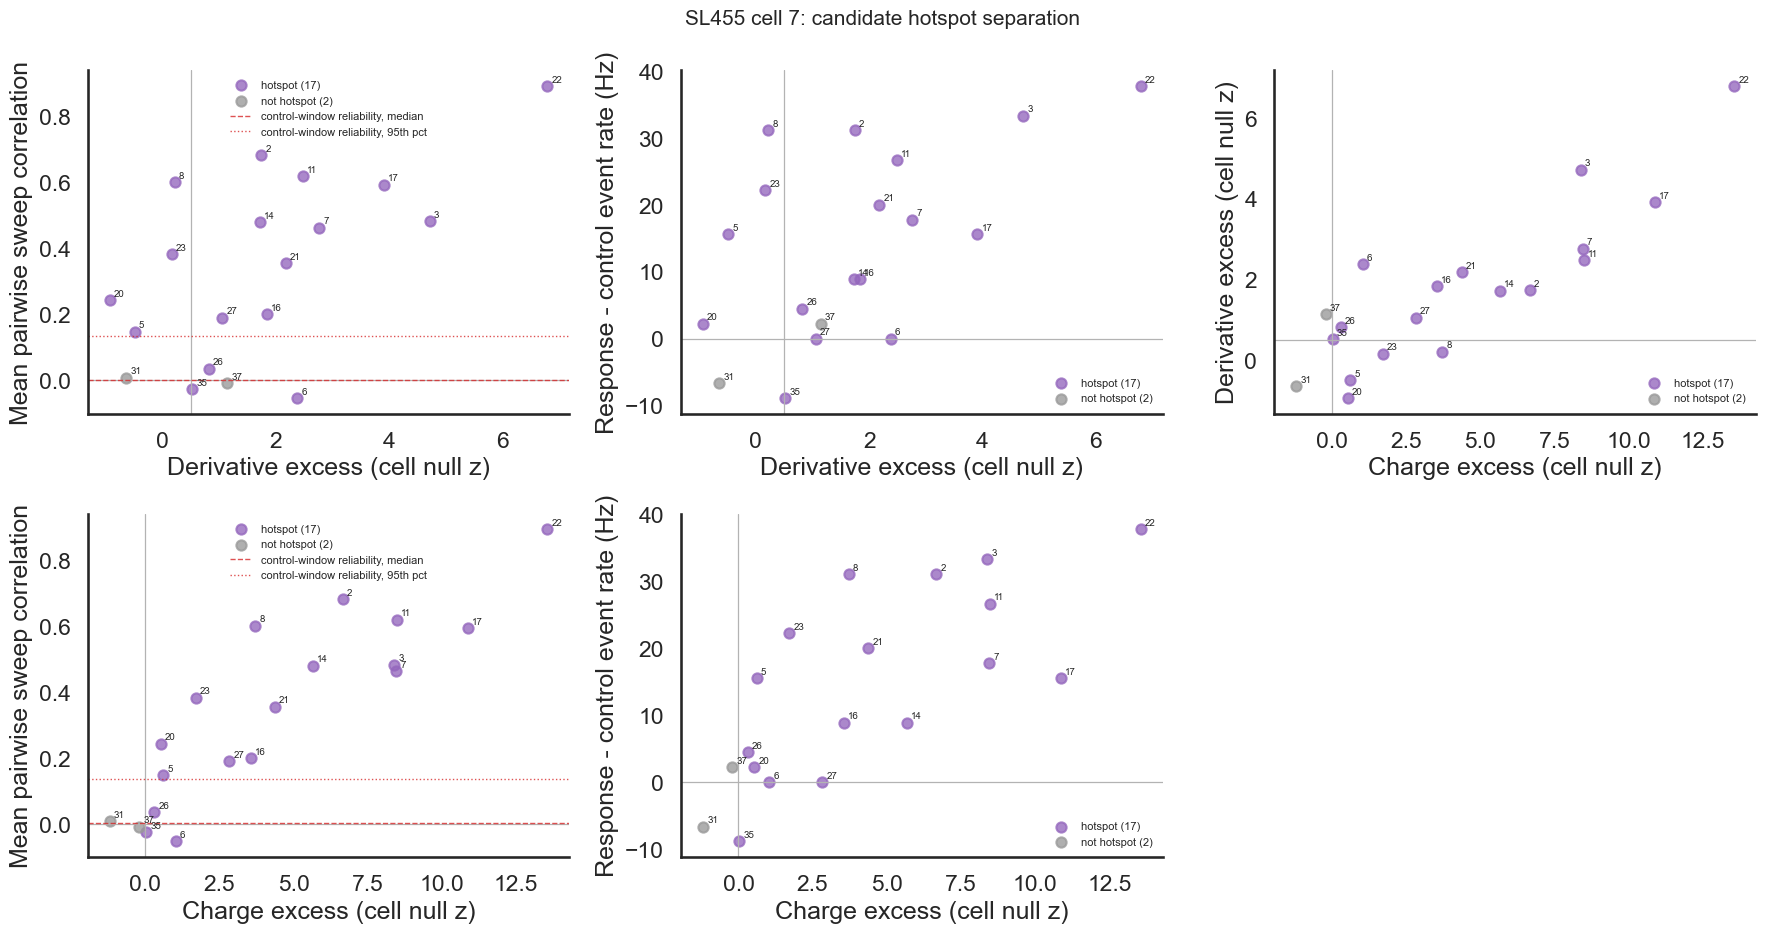

In [785]:
# Which excess decides is_hotspot: "charge", "derivative", "both" (AND) or
# "either" (OR). Set here while working in this section; it overrides the
# configuration cell for the rest of the session.
DETECTION_CRITERION = "charge"

# How the four criteria compare on this cell, without rescoring the spots.
print(pd.DataFrame([
    {"criterion": name,
     "hotspots": int(hotspot_verdict(example_detection_df, name).sum())}
    for name in ("charge", "derivative", "both", "either")
]).to_string(index=False))

example_hotspot_df, example_trace_cache = example_cell_hotspots(
    accuracy_dataset_cache, ACCURACY_CELL_ID
)
example_detection_df = detect_evoked_hotspots(
    example_hotspot_df, example_trace_cache
)
example_classification_scatter_figure = plot_hotspot_classification_scatters(
    example_detection_df
)
plt.show()

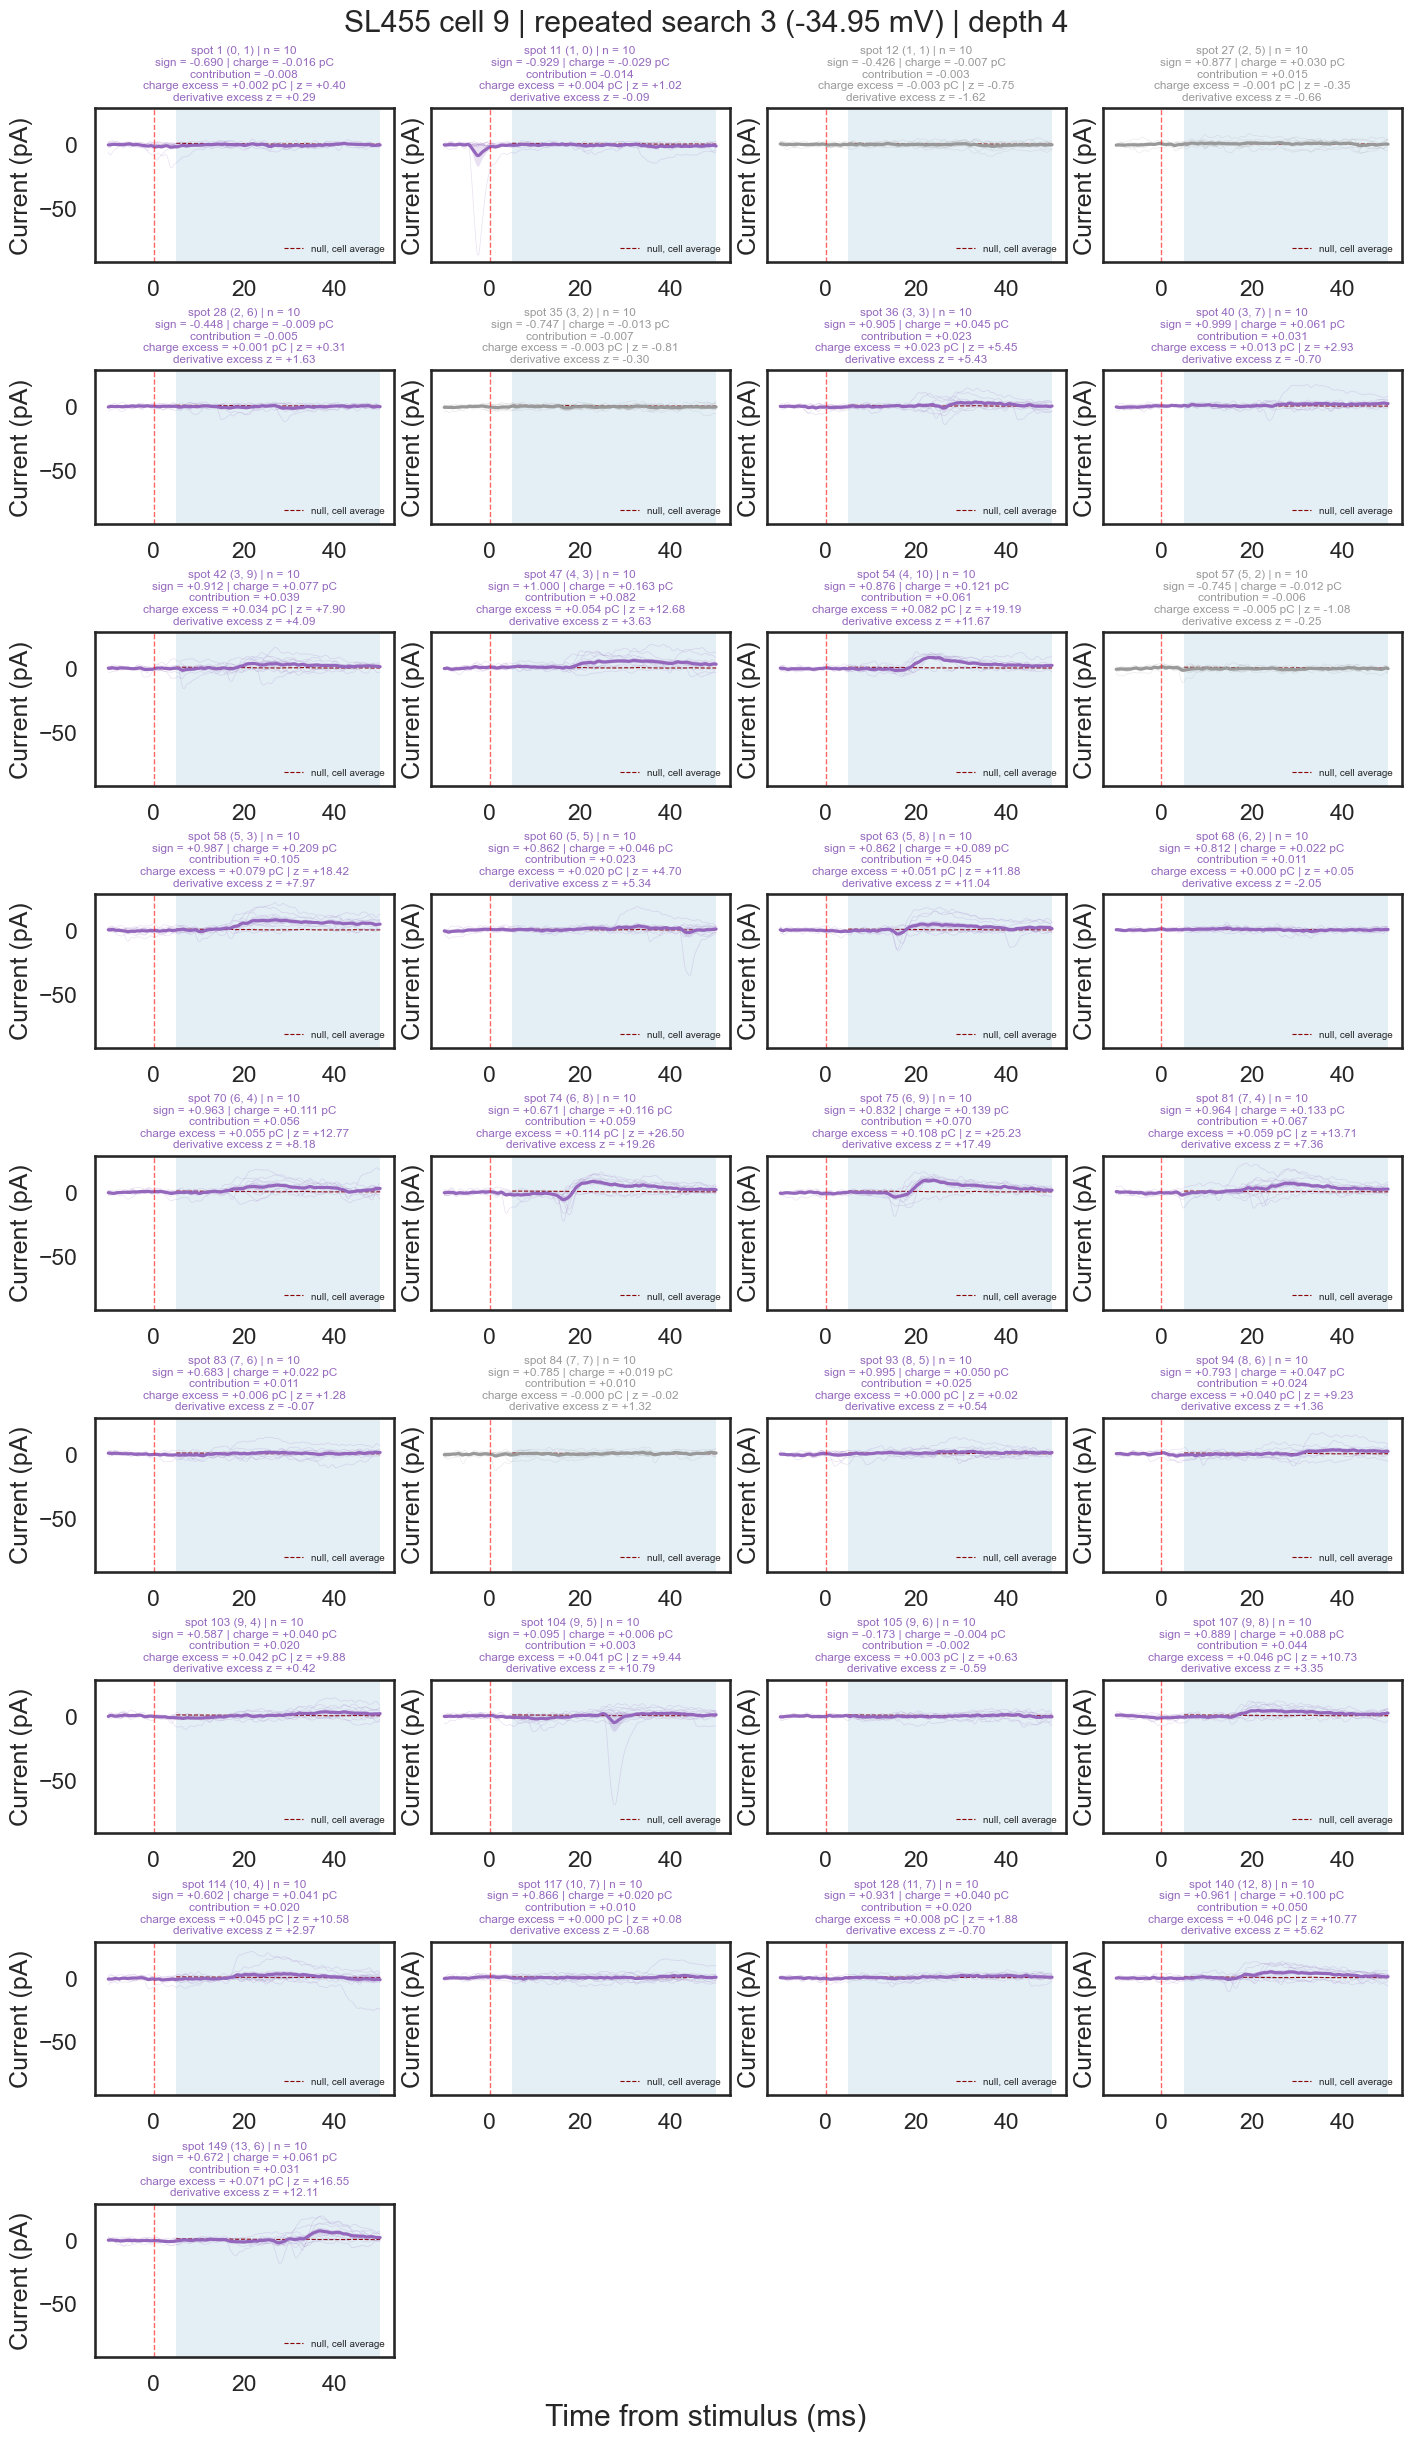

In [ ]:
# spot_range = [433, 434, 435, 436, 440, 689, 87]
spot_range = None

# columns = ["spot_idx", *DETECTION_COLUMNS, "is_hotspot"]
# display(example_detection_df.loc[
#     example_detection_df["spot_idx"].isin(spot_range), columns
# ])

test_hotspot_metrics_df, test_analysis_log_df, test_figures = run_accuracy_check(
    accuracy_dataset_cache,
    ACCURACY_CELL_ID,
    sign_mode=HOTSPOT_SIGN_MODE,
    auc_window_ms=HOTSPOT_AUC_WINDOW_MS,
    share_y=True,
    verdicts=verdict_marks(example_detection_df),
    spot_range=spot_range,
    plot_null=True
)

# if test_hotspot_metrics_df.empty:
#     print("No valid hotspots were available to plot for the accuracy check. Potentially because DEPTH_CHOICE is None.")
# else:
#     display(test_hotspot_metrics_df)

## 1. Calculate hotspot metrics for each group

Each animal in `ANIMALS_TO_LOAD` uses its newest valid result folder, avoiding duplicate counting of older result snapshots. The **Load data** block retains every repeated hotspot trace in `all_hotspot_trace_cache`. This section recalculates `hotspot_sign`, `synaptic_charge_pc`, and `synaptic_contribution` from those cached traces, so the metric settings or helper functions can be changed without reopening the MATLAB files. Group assignments and `MIN_FINAL_DEPTH` are applied afterward.

For each search, `avg_sign` is the mean of its finite hotspot signs. `inhi_frac` is the fraction of finite hotspots with `hotspot_sign > SIGN_EPSILON`; signs within ±`SIGN_EPSILON` are neutral and remain in the denominator. Positive signs are inhibitory-dominant. Spots with fewer than `MIN_SWEEPS_PER_HOTSPOT` sweeps are excluded.

`synaptic_charge_pc` is the net charge of the mean trace within `HOTSPOT_AUC_WINDOW_MS`. `synaptic_contribution` divides each signed charge by the sum of absolute charges across the retained hotspots in that cell.


### Check patch-day dopamine slope

Using the patch-day traces loaded before Section 0, identify the session under `Recordings/202606-Photometry-DMD`. Valid names follow `<YYYYMMDD>-<animal>-RewardPatch[_g#]` or `<YYYYMMDD>-<animal>-PunishPatch[_g#]`; `PrePatch` sessions are excluded. The Patch-session date is used directly because `Results-*` records the analysis/export date and often differs from the recording date. From `analysis_<session>.mat`, select the unique `Stim only`/`dLight` row and load its signed `stageAmp` response through `ndap.load_analysis_stage_response`.

With `SLOPE_WINDOW = None`, independently fit each feasible final-trial window from 15 through 40 trials and average those slopes; windows longer than the animal's recording are omitted. If fewer than 15 trials are available, fit one slope across all available trials. With an explicit window such as `SLOPE_WINDOW = 15` or `20`, fit that final window when enough trials exist; otherwise, fit one slope across the animal's entire available session. `NUM_GROUPS = 3` orders the k-means centers as dopamine `decrease`, `stable`, and `increase`; `NUM_GROUPS = 2` orders them as `decrease` and `increase`.

In [458]:
SLOPE_WINDOW = None  # Use all trials when a session is shorter than 15.
DA_SMOOTHING_WINDOW = 5
NUM_GROUPS = 3  # 3: decrease/stable/increase; 2: decrease/increase.

,animal,patch_date,session,event,amplitude_source,n_trials,n_finite_trials,slope_windows_used,dopamine_slope,dopamine_group,cluster_center
0,SL448,20260703,20260703-SL448-PunishPatch_g0,Stim only,stageMax/stageMin fallback,31,31,15:31 average,-0.065335,decrease,-0.032142
1,SL468,20260820,20260820-SL468-RewardPatch_g0,Stim only,stageMax/stageMin fallback,39,39,15:39 average,-0.017527,decrease,-0.032142
2,SL469,20260819,20260819-SL469-PunishPatch_g0,Stim only,stageMax/stageMin fallback,37,37,15:37 average,-0.013563,decrease,-0.032142
3,SL455,20260729,20260729-SL455-RewardPatch_g0,Stim only,stageMax/stageMin fallback,33,33,15:33 average,0.009519,stable,0.021627
4,SL453,20260721,20260721-SL453-PunishPatch_g0,Stim only,stageMax/stageMin fallback,24,24,15:24 average,0.019543,stable,0.021627
5,SL457,20260814,20260814-SL457-PunishPatch_g0,Stim only,stageMax/stageMin fallback,31,31,15:31 average,0.020701,stable,0.021627
6,SL454,20260728,20260728-SL454-PunishPatch_g0,Stim only,stageMax/stageMin fallback,31,31,15:31 average,0.036745,stable,0.021627
7,SL456,20260813,20260813-SL456-RewardPatch_g0,Stim only,stageMax/stageMin fallback,14,14,14,0.117417,increase,0.117417


,n_animals,cluster_center,animals
dopamine_group,,,
decrease,3,-0.032142,"[SL448, SL468, SL469]"
stable,4,0.021627,"[SL455, SL453, SL457, SL454]"
increase,1,0.117417,[SL456]


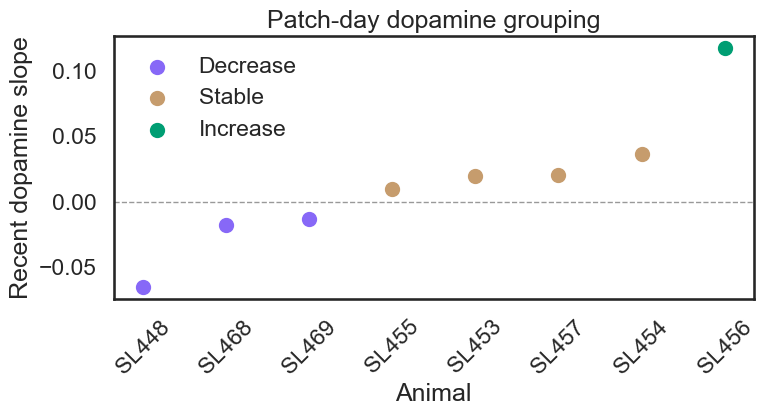

In [459]:
from sklearn.cluster import KMeans


DA_KMEANS_RANDOM_STATE = 2626
if (
    isinstance(NUM_GROUPS, (bool, np.bool_))
    or not isinstance(NUM_GROUPS, (int, np.integer))
    or int(NUM_GROUPS) not in (2, 3)
):
    raise ValueError("NUM_GROUPS must be the integer 2 or 3.")
NUM_GROUPS = int(NUM_GROUPS)
DA_GROUP_ORDER = (
    ["decrease", "increase"]
    if NUM_GROUPS == 2
    else ["decrease", "stable", "increase"]
)
DA_GROUP_COLORS = {
    "decrease": [135 / 255, 104 / 255, 247 / 255],
    "stable": [198 / 255, 156 / 255, 109 / 255],
    "increase": [0 / 255, 158 / 255, 115 / 255],
}


def recent_dopamine_slope(stage_amp, slope_window=None):
    """Fit and average the requested final-trial dopamine slopes."""
    response = np.asarray(stage_amp, dtype=float).ravel()
    if len(response) < 3:
        raise ValueError("At least three Stim only trials are required.")

    # Match MATLAB smoothdata(response, 'movmean', 5), including endpoints.
    smoothed = (
        pd.Series(response)
        .rolling(DA_SMOOTHING_WINDOW, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )
    if slope_window is None:
        windows = np.arange(15, 41, dtype=int)
    else:
        if not isinstance(slope_window, (int, np.integer)) or slope_window < 3:
            raise ValueError("SLOPE_WINDOW must be None or an integer >= 3.")
        windows = np.asarray([slope_window], dtype=int)
    feasible_windows = windows[windows <= len(response)]
    if len(feasible_windows) == 0:
        # A requested window longer than the recording falls back to
        # one slope fitted across the whole available session.
        feasible_windows = np.asarray([len(response)], dtype=int)
    windows = feasible_windows

    slopes = []
    for window in windows:
        segment = smoothed[-int(window):]
        trial = np.arange(1, len(segment) + 1, dtype=float)
        finite = np.isfinite(segment)
        slopes.append(
            np.polyfit(trial[finite], segment[finite], 1)[0]
            if finite.sum() >= 3 else np.nan
        )
    if not np.isfinite(slopes).any():
        raise ValueError("No finite dopamine slopes could be fitted.")
    return (
        float(np.nanmean(slopes)), np.asarray(slopes), windows, smoothed
    )


# Calculate slopes from the already-loaded raw responses.
dopamine_records = []
dopamine_traces = {}
for animal in DOPAMINE_ANIMALS:
    cached = patch_data_cache[animal]
    stage_amp = cached["stage_amp"]
    slope, fitted_slopes, fitted_windows, smoothed = recent_dopamine_slope(
        stage_amp, SLOPE_WINDOW
    )
    dopamine_records.append({
        "animal": animal,
        "patch_date": cached["patch_date"],
        "session": cached["session"],
        "event": cached["event"],
        "amplitude_source": cached["amplitude_source"],
        "n_trials": len(stage_amp),
        "n_finite_trials": int(np.isfinite(stage_amp).sum()),
        "slope_windows_used": (
            f"{fitted_windows[0]}:{fitted_windows[-1]} average"
            if len(fitted_windows) > 1 else int(fitted_windows[0])
        ),
        "dopamine_slope": slope,
    })
    dopamine_traces[animal] = {
        "stage_amp": stage_amp,
        "smoothed": smoothed,
        "window_lengths": fitted_windows,
        "window_slopes": fitted_slopes,
    }

dopamine_slope_df = pd.DataFrame(dopamine_records)
if (
    len(dopamine_slope_df) < NUM_GROUPS
    or dopamine_slope_df["dopamine_slope"].nunique() < NUM_GROUPS
):
    raise ValueError(
        f"{NUM_GROUPS}-group k-means requires at least "
        f"{NUM_GROUPS} distinct animal slopes."
    )

kmeans = KMeans(
    n_clusters=NUM_GROUPS, n_init=100,
    random_state=DA_KMEANS_RANDOM_STATE,
)
raw_labels = kmeans.fit_predict(dopamine_slope_df[["dopamine_slope"]])
center_order = np.argsort(kmeans.cluster_centers_.ravel())
label_by_cluster = {
    int(cluster): DA_GROUP_ORDER[rank]
    for rank, cluster in enumerate(center_order)
}
dopamine_slope_df["dopamine_group"] = [
    label_by_cluster[int(label)] for label in raw_labels
]
dopamine_slope_df["cluster_center"] = [
    float(kmeans.cluster_centers_[int(label), 0]) for label in raw_labels
]
dopamine_slope_df["dopamine_group"] = pd.Categorical(
    dopamine_slope_df["dopamine_group"],
    categories=DA_GROUP_ORDER,
    ordered=True,
)
dopamine_slope_df = dopamine_slope_df.sort_values(
    ["dopamine_group", "dopamine_slope", "animal"]
).reset_index(drop=True)

dopamine_group_animals = {
    group: dopamine_slope_df.loc[
        dopamine_slope_df["dopamine_group"] == group, "animal"
    ].tolist()
    for group in DA_GROUP_ORDER
}
dopamine_group_by_animal = {
    row.animal: str(row.dopamine_group)
    for row in dopamine_slope_df.itertuples(index=False)
}
decrease_animals = dopamine_group_animals["decrease"]
stable_animals = dopamine_group_animals.get("stable", [])
increase_animals = dopamine_group_animals["increase"]

display(dopamine_slope_df)
display(
    dopamine_slope_df.groupby("dopamine_group", observed=False)
    .agg(
        n_animals=("animal", "size"),
        cluster_center=("cluster_center", "first"),
        animals=("animal", lambda values: list(values)),
    )
)

fig, ax = plt.subplots(
    figsize=(max(8, 0.8 * len(dopamine_slope_df)), 4.5)
)
for group in DA_GROUP_ORDER:
    rows = dopamine_slope_df[
        dopamine_slope_df["dopamine_group"] == group
    ]
    ax.scatter(
        rows["animal"], rows["dopamine_slope"], s=90,
        color=DA_GROUP_COLORS[group], label=group.capitalize(), zorder=3,
    )
ax.axhline(0, color="0.6", linestyle="--", linewidth=1)
ax.set_xlabel("Animal")
ax.set_ylabel("Recent dopamine slope")
ax.set_title("Patch-day dopamine grouping")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()



### Apply groups and depth criteria to animals

Choose `GROUPING_MODE = "task"` for the original random/reward/punish assignment, or `GROUPING_MODE = "dopamine"` for random plus the dopamine groups selected by `NUM_GROUPS`. Dopamine mode requires the patch-day slope cell above to be run first. The random animals remain a separate group and are not included in dopamine k-means. Set `EXCLUDE_ANIMALS = True` and list animal IDs in `ANIMALS_TO_EXCLUDE` to remove all of their cells and hotspots from downstream analyses while retaining an exclusion record in `analysis_log_df`.

In [608]:
# Update configuration if needed.

HOTSPOT_TYPE = "evoked"

GROUPING_MODE = "task"  # "task" or "dopamine"
MIN_FINAL_DEPTH = 2  # Inclusive cutoff; set to None to keep every depth.
MIN_SWEEPS_PER_HOTSPOT = 1
PLOT_WINDOW_MS = (-10.0, 50.0)

# Sign calculation
HOTSPOT_SIGN_MODE = 'auc'
HOTSPOT_AUC_WINDOW_MS = [5,50] # ms

# Exclude every cell/hotspot belonging to the listed animals.
EXCLUDE_ANIMALS = False
ANIMALS_TO_EXCLUDE = ["SL455"]
GROUP_LABEL_FONTSIZE = 10

In [786]:
# Calculate hotspot variables (signs, charge, contribution)
all_hotspot_metrics_df, all_analysis_log_df = recalculate_hotspot_metrics(
    all_hotspot_base_df,
    all_analysis_base_log_df,
    all_hotspot_trace_cache,
    sign_mode=HOTSPOT_SIGN_MODE,
    auc_window_ms=HOTSPOT_AUC_WINDOW_MS,
)

# Keep only the spots matching HOTSPOT_TYPE, then resync the per-search log.
all_hotspot_metrics_df = apply_hotspot_type(
    all_hotspot_metrics_df, all_hotspot_trace_cache,
    HOTSPOT_TYPE, **HOTSPOT_CRITERIA,
)
all_analysis_log_df = refresh_log_sign_summaries(
    all_hotspot_metrics_df, all_analysis_log_df
)

HOTSPOT_TYPE=reanalysis: 924 of 1807 acquisition spots kept (924 pass the offline criterion).


In [787]:
# Keep group labels, plot colors, and endpoint comparisons synchronized.
grouping_mode = str(GROUPING_MODE).strip().casefold()
if grouping_mode == "task":
    GROUP_ORDER = TASK_GROUP_ORDER.copy()
    GROUP_COLORS = TASK_GROUP_COLORS.copy()
    animal_groups = {
        "random": random_animals,
        "reward": reward_animals,
        "punish": punish_animals,
    }
    COMPARISON_GROUPS = ("reward", "punish")
elif grouping_mode == "dopamine":
    if "dopamine_group_animals" not in globals():
        raise RuntimeError(
            "Run the patch-day dopamine slope cell before using "
            "GROUPING_MODE='dopamine'."
        )
    GROUP_ORDER = ["random", *DA_GROUP_ORDER]
    GROUP_COLORS = {
        "random": TASK_GROUP_COLORS["random"],
        **{group: DA_GROUP_COLORS[group] for group in DA_GROUP_ORDER},
    }
    animal_groups = {
        "random": random_animals,
        **{group: dopamine_group_animals[group] for group in DA_GROUP_ORDER},
    }
    COMPARISON_GROUPS = ("decrease", "increase")
else:
    raise ValueError(
        "GROUPING_MODE must be either 'task' or 'dopamine'; "
        f"received {GROUPING_MODE!r}."
    )

BASELINE_GROUP, COMPARISON_GROUP = COMPARISON_GROUPS
group_by_animal = resolve_group_assignments(
    ANIMALS_TO_LOAD, animal_groups
)
depth_filtered_df, depth_filtered_log_df = filter_hotspots_by_final_depth(
    all_hotspot_metrics_df, all_analysis_log_df, MIN_FINAL_DEPTH
)
analysis_ready_df, analysis_ready_log_df = filter_excluded_animals(
    depth_filtered_df,
    depth_filtered_log_df,
    EXCLUDE_ANIMALS,
    ANIMALS_TO_EXCLUDE,
)
hotspot_metrics_df, analysis_log_df = apply_group_assignments(
    analysis_ready_df, analysis_ready_log_df, group_by_animal
)
cell_group_keys = ["group", "animal", "results_folder", "cell"]
hotspot_metrics_df["synaptic_contribution"] = hotspot_metrics_df.groupby(
    cell_group_keys, observed=True, dropna=False
)["synaptic_charge_pc"].transform(get_synaptic_contribution)
display(analysis_log_df)
if hotspot_metrics_df.empty:
    raise ValueError(
        "No cached hotspots remain after applying the current group "
        f"assignments and MIN_FINAL_DEPTH={MIN_FINAL_DEPTH}."
    )

cell_metric_df = (
    hotspot_metrics_df.groupby(cell_group_keys, observed=True)
    .agg(
        cell_avg_synaptic_charge_pc=("synaptic_charge_pc", "mean"),
        cell_avg_synaptic_contribution=("synaptic_contribution", "mean"),
    )
    .reset_index()
)
cell_group_summary_df = (
    cell_metric_df.groupby("group", observed=True)
    .agg(
        n_cells=("cell", "size"),
        mean_cell_synaptic_charge_pc=("cell_avg_synaptic_charge_pc", "mean"),
        mean_cell_synaptic_contribution=("cell_avg_synaptic_contribution", "mean"),
    )
)
group_summary_df = (
    hotspot_metrics_df.groupby("group", observed=True)
    .agg(
        n_hotspots=("hotspot_sign", "size"),
        n_animals=("animal", "nunique"),
        median_sign=("hotspot_sign", "median"),
        mean_sign=("hotspot_sign", "mean"),
    )
    .join(cell_group_summary_df)
)
n_cells = group_summary_df.pop("n_cells")
group_summary_df.insert(2, "n_cells", n_cells)
group_summary_df = group_summary_df.reindex(GROUP_ORDER)
display(group_summary_df)
# hotspot_metrics_df.head()


,group,animal,results_folder,cell,search_idx,final_depth,status,n_hotspots,avg_sign,inhi_frac
0,random,SL458,Results-20260723,5,6,5,analyzed,18,-0.638017,0.055556
1,random,SL458,Results-20260723,6,6,5,analyzed,1,-0.675826,0.000000
2,random,SL452,Results-20260706,2,6,4,analyzed,107,0.494650,0.775701
3,random,SL452,Results-20260706,5,3,3,analyzed,18,-0.902302,0.000000
4,random,SL452,Results-20260706,6,3,2,analyzed,8,-0.858198,0.000000
5,random,SL452,Results-20260706,7,None,None,excluded: DEPTH_CHOICE-NONE marker,0,NaN,NaN
6,random,SL452,Results-20260706,8,2,4,analyzed,58,0.745675,0.896552
7,random,SL452,Results-20260706,9,3,4,analyzed,9,-0.321906,0.333333
8,reward,SL468,Results-20260821,2,6,4,analyzed,3,0.843961,1.000000
9,reward,SL468,Results-20260821,5,6,4,analyzed,6,0.981541,1.000000


,n_hotspots,n_animals,n_cells,median_sign,mean_sign,mean_cell_synaptic_charge_pc,mean_cell_synaptic_contribution
group,,,,,,,
random,219,2,7,0.698213,0.264897,0.016006,-0.174545
reward,454,3,18,0.371945,0.089197,0.102836,0.169942
punish,251,4,13,0.736574,0.405428,0.043918,-0.009534


## 2. Plot hotspot distributions

The three columns show hotspot sign, net charge, and contribution. Each uses permutation-bootstrap means in the upper panel and empirical CDFs of the same hotspot-level values below. Positive values indicate a positive-going-current-dominated hotspot; negative values indicate a negative-going-current-dominated hotspot.

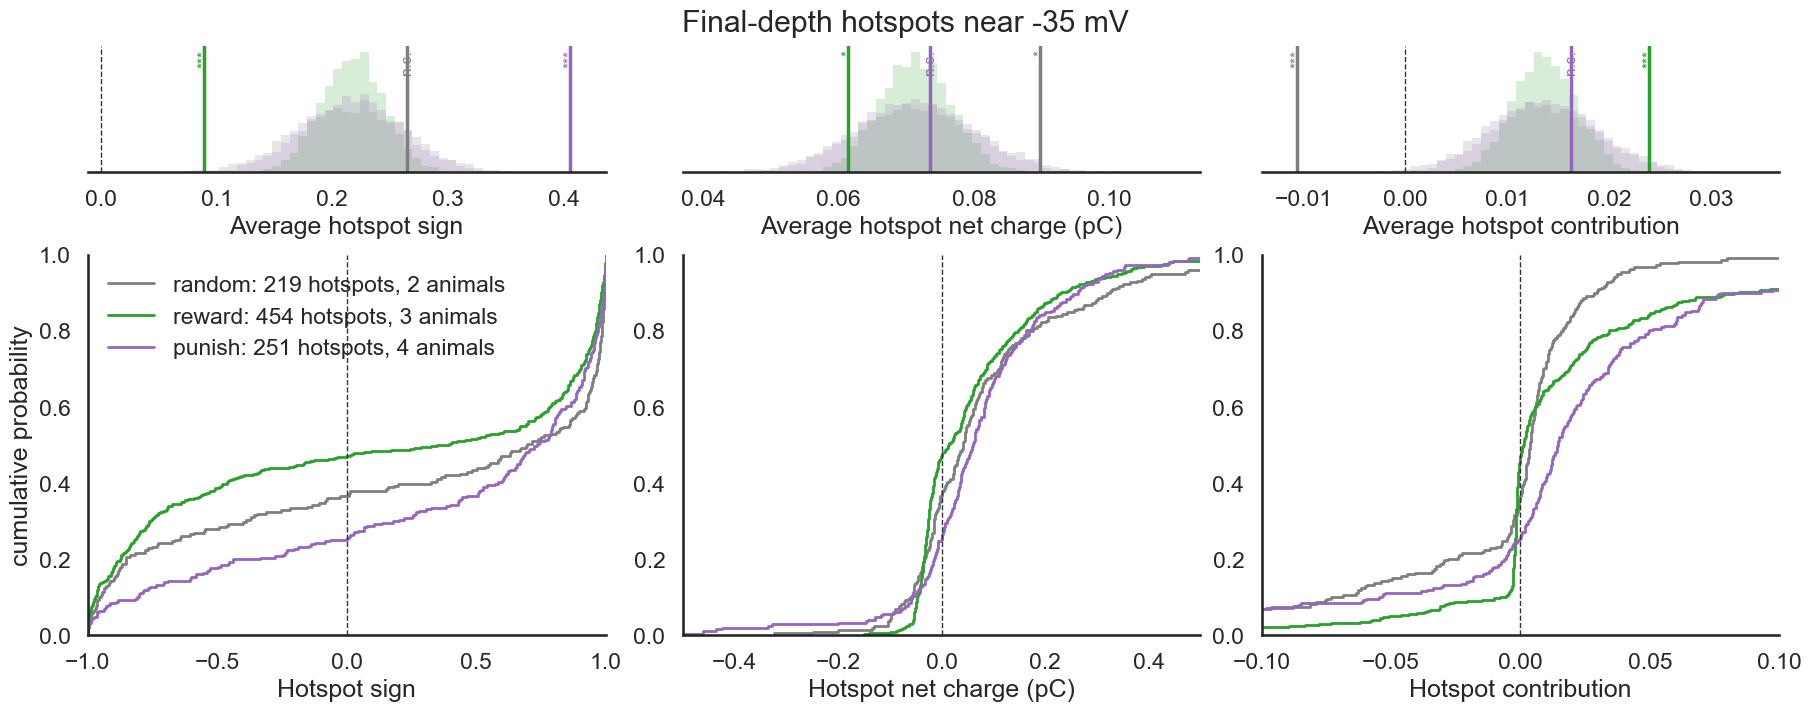

In [789]:
DISTRIBUTION_XLIMS = {
    "hotspot_sign": (-1, 1),
    "synaptic_charge_pc": (-0.5, 0.5),
    "synaptic_contribution": (-0.1, 0.1),
}

distribution_metrics = [
    ("hotspot_sign", "Hotspot sign", "Average hotspot sign"),
    (
        "synaptic_charge_pc",
        "Hotspot net charge (pC)",
        "Average hotspot net charge (pC)",
    ),
    (
        "synaptic_contribution",
        "Hotspot contribution",
        "Average hotspot contribution",
    ),
]

fig = plt.figure(figsize=(18, 7), layout="constrained")
grid = fig.add_gridspec(2, 3, height_ratios=(1, 3))
distribution_axes = [
    (fig.add_subplot(grid[0, index]), fig.add_subplot(grid[1, index]))
    for index in range(len(distribution_metrics))
]

for metric_index, (column, xlabel, top_xlabel) in enumerate(
    distribution_metrics
):
    distribution_groups = []
    for group in GROUP_ORDER:
        group_rows = hotspot_metrics_df.loc[
            hotspot_metrics_df["group"].eq(group)
        ].copy()
        group_rows[column] = pd.to_numeric(
            group_rows[column], errors="coerce"
        )
        group_rows = group_rows[np.isfinite(group_rows[column])]
        values = group_rows[column].to_numpy(dtype=float)
        if len(values):
            distribution_groups.append((group, group_rows, values))

    if not distribution_groups:
        raise ValueError(f"No finite {xlabel.lower()} values are available.")

    boot_data, boot_indices = ndap.generate_boot_data(
        [values for _, _, values in distribution_groups],
        random_state=2026,
    )
    axes_pair = distribution_axes[metric_index]
    for (group, group_rows, values), boot_idx in zip(
        distribution_groups, boot_indices
    ):
        label = (
            f"{group}: {len(values)} hotspots, "
            f"{group_rows['animal'].nunique()} animals"
        )
        ndap.plot_distribution(
            values,
            label=label,
            color=GROUP_COLORS[group],
            ax=axes_pair,
            boot_data=boot_data,
            boot_idx=boot_idx,
            xlabel=xlabel,
            top_xlabel=top_xlabel,
            show_legend=metric_index == 0,
        )

    for ax in axes_pair:
        ax.axvline(0, color="0.2", linestyle="--", linewidth=1)
    axes_pair[1].set_xlim(DISTRIBUTION_XLIMS[column])
    if metric_index:
        axes_pair[1].set_ylabel("")

fig.suptitle(f"Final-depth hotspots near {TARGET_VHOLD_MV:g} mV")
plt.show()

## 3. Compare spot response across depth

If hotspot is truely single synaptic response, then the amplitude of spot response should be similar regardless of depth.

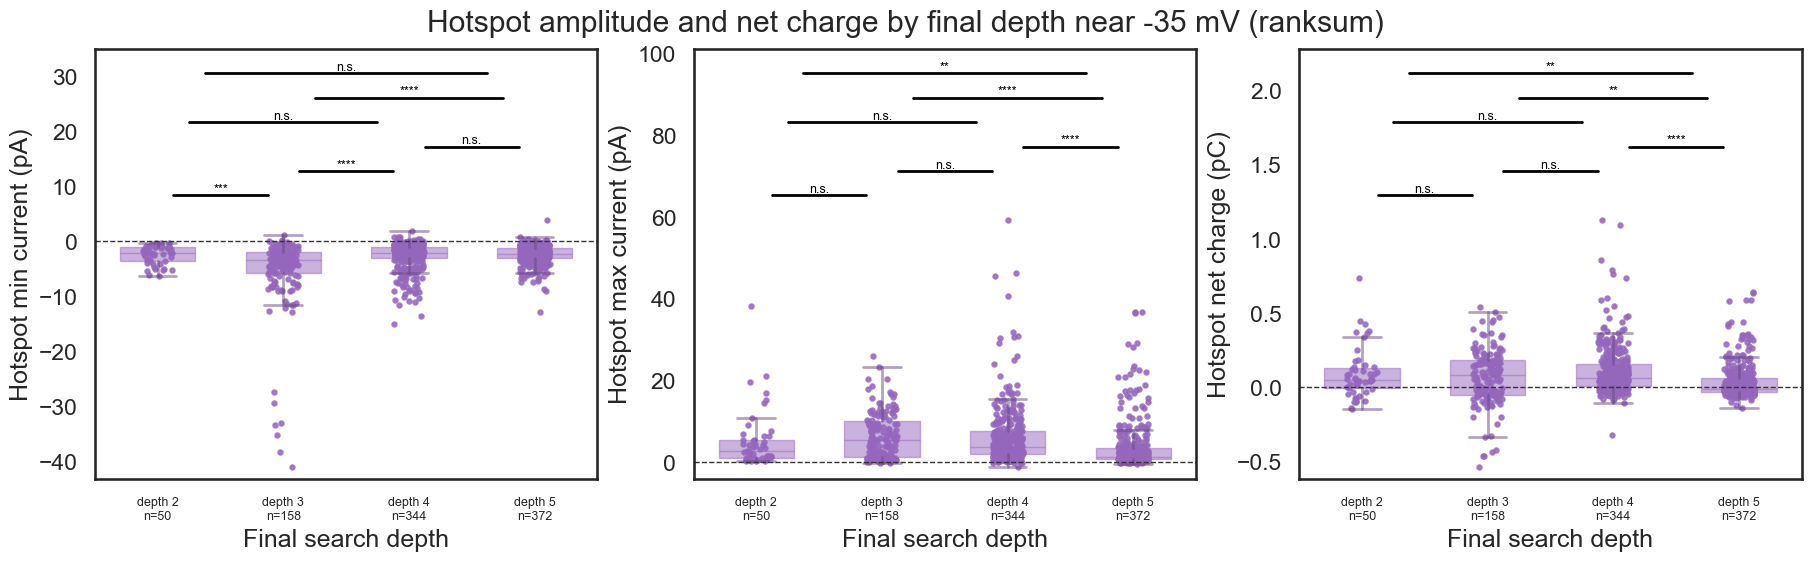

In [790]:
# Plot spot response amplitude and net charge at all final depths (2-5)
# using plotScatterBar. Uses all_hotspot_metrics_df so every loaded depth is
# kept, ignoring MIN_FINAL_DEPTH. Every depth pair is compared with a
# two-sample KS test drawn by plotStats.

from itertools import combinations

DEPTH_TEST = "ranksum"  # 'kstest', 'ranksum', 'ttest', ...

depth_amplitude_df = all_hotspot_metrics_df.copy()
depth_amplitude_df["final_depth"] = pd.to_numeric(
    depth_amplitude_df["final_depth"], errors="coerce"
)
depth_amplitude_df = depth_amplitude_df.dropna(subset=["final_depth"])
depth_values = sorted(depth_amplitude_df["final_depth"].unique())

depth_metrics = [
    ("min_current_pa", "Hotspot min current (pA)"),
    ("max_current_pa", "Hotspot max current (pA)"),
    ("synaptic_charge_pc", "Hotspot net charge (pC)"),
]

depth_pvalue_rows = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), layout="constrained")
for ax, (column, ylabel) in zip(axes, depth_metrics):
    depth_groups = []
    for depth in depth_values:
        values = pd.to_numeric(
            depth_amplitude_df.loc[
                depth_amplitude_df["final_depth"].eq(depth), column
            ],
            errors="coerce",
        ).dropna().to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        if len(values):
            depth_groups.append((depth, values))

    ndap.plotScatterBar(
        [values for _, values in depth_groups],
        labels=[
            f"depth {int(depth)}\nn={len(values)}"
            for depth, values in depth_groups
        ],
        style="box",
        ax=ax,
        colors=[to_rgba("tab:purple", 0.5)] * len(depth_groups),
    )
    ax.axhline(0, color="0.2", linestyle="--", linewidth=1)
    ax.set_xlabel("Final search depth")
    ax.set_ylabel(ylabel)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=9)

    # Stack one comparison bar per depth pair, narrowest span lowest.
    y_low, y_high = ax.get_ylim()
    step = 0.09 * (y_high - y_low)
    y_base = max(values.max() for _, values in depth_groups) + step
    pairs = sorted(
        combinations(range(len(depth_groups)), 2), key=lambda ij: (ij[1] - ij[0], ij[0])
    )
    for level, (i, j) in enumerate(pairs):
        p_value = ndap.plotStats(
            depth_groups[i][1],
            depth_groups[j][1],
            xloc=(i, j),
            ax=ax,
            test=DEPTH_TEST,
            yloc=y_base + level * step,
            fontsize=9,
        )
        depth_pvalue_rows.append({
            "metric": column,
            "depth_a": int(depth_groups[i][0]),
            "depth_b": int(depth_groups[j][0]),
            "n_a": len(depth_groups[i][1]),
            "n_b": len(depth_groups[j][1]),
            "p_value": p_value,
        })
    ax.set_ylim(y_low, y_base + len(pairs) * step)

fig.suptitle(
    f"Hotspot amplitude and net charge by final depth "
    f"near {TARGET_VHOLD_MV:g} mV ({DEPTH_TEST})"
)
plt.show()


### Detection metric distributions across every spot

The Section 0 scatters look at one cell. These histograms pool every spot of
every loaded animal, taken from `all_hotspot_base_df` so they include the spots
`HOTSPOT_TYPE` rejects — a distribution with only the survivors in it would not
show where the threshold sits. Both `z` columns are standardised within cell, so
pooling them across cells is the intended use; the event rate and the
reliability are not standardised, and a cell with unusual noise shows up as its
own bump.

This rescores every spot, so it takes a minute or two on the full cache.

8 of 1807 spots could not be scored.


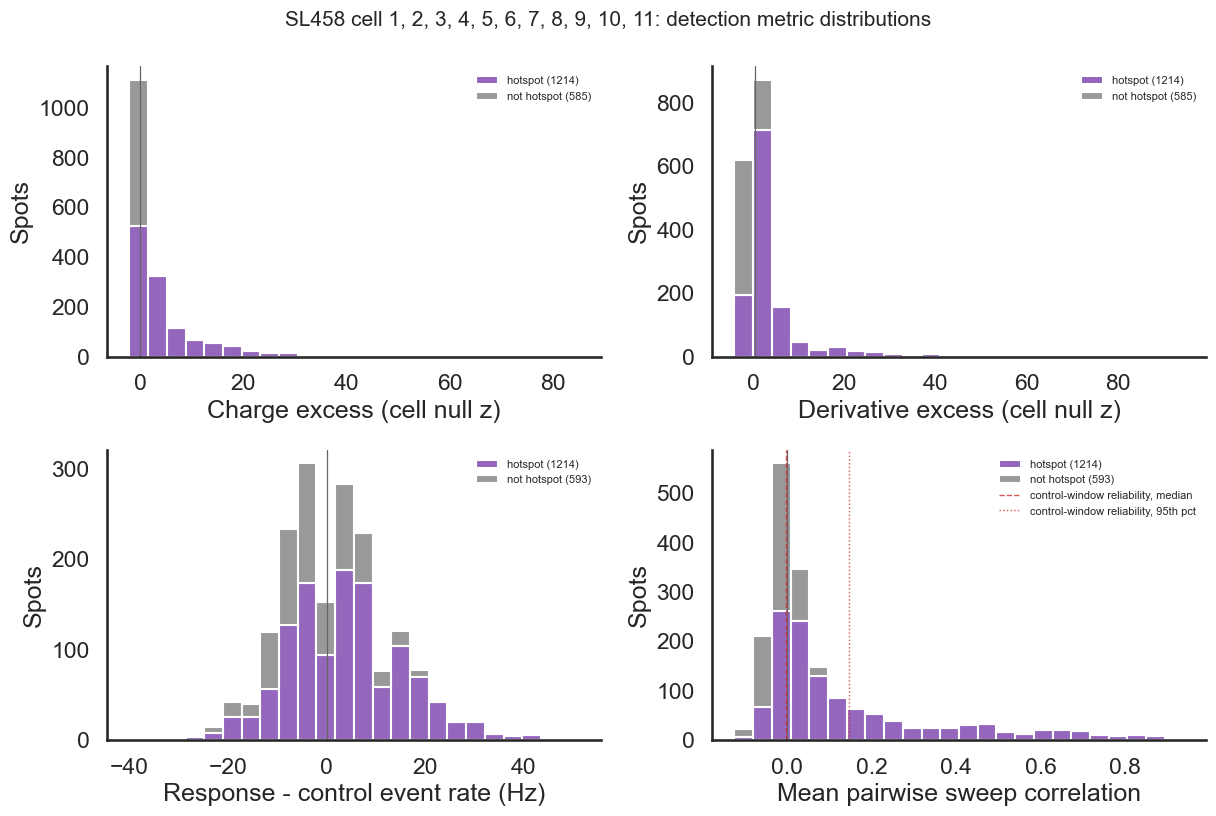

DETECTION_CRITERION='charge': 1214 of 1807 spots pass, across 38 cells.


,spots,hotspots,fraction
animal,,,
SL448,156,122,0.782
SL452,329,226,0.687
SL453,169,126,0.746
SL454,56,37,0.661
SL455,783,495,0.632
SL456,112,72,0.643
SL457,110,82,0.745
SL458,57,31,0.544
SL468,35,23,0.657


In [791]:
# Detection metrics for every loaded spot, pooled across cells. Scored from the
# unfiltered base table, so the spots HOTSPOT_TYPE would drop are still here.
all_detection_df = detect_evoked_hotspots(
    all_hotspot_base_df, all_hotspot_trace_cache
)
all_distribution_figure = plot_detection_distributions(all_detection_df)
plt.show()

print(
    f"DETECTION_CRITERION={DETECTION_CRITERION!r}: "
    f"{int(all_detection_df['is_hotspot'].sum())} of {len(all_detection_df)} spots "
    f"pass, across "
    f"{len(all_detection_df.drop_duplicates(subset=CELL_KEYS))} cells."
)
display(
    all_detection_df.groupby("animal", observed=True)["is_hotspot"]
    .agg(spots="size", hotspots="sum", fraction="mean")
    .round({"fraction": 3})
)

## 4. Compare spot response with minis (TODO: use the same detection algorithm to detect in hotspots)

Compare each cell's repeated-hotspot response with minis detected in its RC-recovery/post-stim baseline pool (loadSlicesDMD.m's `noise_cell<N>.mat`, `baselineData`).

The detector is an in-memory, sampling-rate-aware adaptation of [ellamcho/mini_detect's `functions.py`](https://github.com/ellamcho/mini_detect/blob/main/Code/functions.py). It applies the same 1-3000 Hz, second-order Butterworth filter; searches for polarity-specific monotonic decay windows; selects the local extremum near each decay start; and rejects candidates using a median-baseline noise gate plus the original amplitude limits (negative < -8 pA; positive between 8 and 60 pA).

The workflow is split into two stages:

1. **Load once before Section 0:** cache each cell's pooled RC-recovery/post-stim baseline (see "RC-recovery / post-stim baseline pool" above).
2. **Analyze repeatedly here:** select the currently retained hotspot rows, detect minis in the cached pool, calculate summaries, and plot an example trace per animal. Changing grouping, depth, exclusions, `RC_BASELINE_MINI_CONFIG`, or `MINI_CELL_SUMMARY` does not reopen the source files.

**How much baseline each cell contributes.** The pool is assembled per sweep from two windows ([loadSlicesDMD.m:281-289](../../NeuroDAP/Methods/loadSlicesDMD.m)): the RC-recovery-to-first-stim window, plus everything from 200 ms after the last photostim pulse to the end of the sweep. For the `randomSearch_Red_shun.cyc` protocol in this dataset -- RC check `delay=100 ms`, `pulseWidth=20 ms`; `rcCheckRecoveryWindow=100 ms` (the `loadSlicesDMD` default); photostim train on `ao2` with `delay=1000 ms`, `numPulses=10`, `isi=200 ms`; 5 s sweeps at 10 kHz -- that works out to:

| window | arithmetic | length |
| --- | --- | --- |
| pre-stim (RC recovery to first stim) | `1000 - (100 + 20 + 100)` | **780 ms** |
| post-stim (200 ms after last pulse to sweep end) | `5000 - (2800 + 200)` | **2000 ms** |
| total per full 10-spot search sweep | | **~2.78 s** |

This pool is long and continuous per cell, so the source detector's original 60 ms/15 ms decay windows are used unmodified. Negative-going events are treated as mEPSC-like and positive-going events as mIPSC-like at approximately -35 mV.


In [792]:
# ---- Mini detection parameters (tune these to calibrate detection) ----

# Bandpass filter applied to each baseline trace before any searching.
MINI_LOWCUT_HZ = 1.0
MINI_HIGHCUT_HZ = 3000.0
MINI_FILTER_ORDER = 2

# Running-median window estimating the local noise floor, and how many SDs
# above that floor a candidate peak must reach. Lower sigma -> more events.
MINI_BASELINE_WINDOW_MS = 100.0
MINI_NOISE_SIGMA = 2.0

# Negative-going (mEPSC-like) search: how long the monotonic decay must run,
# the step at which monotonicity is sampled, and how far past the decay start
# to look for the peak. Shorter windows admit faster/noisier events.
MINI_EPSC_DECAY_WINDOW_MS = 15.0
MINI_EPSC_DECAY_STEP_MS = 2.5
MINI_EPSC_PEAK_INTERVAL_MS = 1.0

# Positive-going (mIPSC-like) search: the same three settings.
MINI_IPSC_DECAY_WINDOW_MS = 40.0
MINI_IPSC_DECAY_STEP_MS = 10
MINI_IPSC_PEAK_INTERVAL_MS = 5.0

# Amplitude gates in pA. Negative events must be below
# -MINI_EPSC_MIN_AMPLITUDE_PA; positive events must land inside
# [MINI_IPSC_MIN_AMPLITUDE_PA, MINI_IPSC_MAX_AMPLITUDE_PA].
MINI_EPSC_MIN_AMPLITUDE_PA = 5.0
MINI_IPSC_MIN_AMPLITUDE_PA = 5.0
MINI_IPSC_MAX_AMPLITUDE_PA = 60.0

RC_BASELINE_MINI_CONFIG = ndap.MiniDetectionConfig(
    lowcut_hz=MINI_LOWCUT_HZ,
    highcut_hz=MINI_HIGHCUT_HZ,
    filter_order=MINI_FILTER_ORDER,
    baseline_window_ms=MINI_BASELINE_WINDOW_MS,
    noise_sigma=MINI_NOISE_SIGMA,
    epsc_decay_window_ms=MINI_EPSC_DECAY_WINDOW_MS,
    epsc_decay_step_ms=MINI_EPSC_DECAY_STEP_MS,
    epsc_peak_interval_ms=MINI_EPSC_PEAK_INTERVAL_MS,
    ipsc_decay_window_ms=MINI_IPSC_DECAY_WINDOW_MS,
    ipsc_decay_step_ms=MINI_IPSC_DECAY_STEP_MS,
    ipsc_peak_interval_ms=MINI_IPSC_PEAK_INTERVAL_MS,
    epsc_min_amplitude_pa=MINI_EPSC_MIN_AMPLITUDE_PA,
    ipsc_min_amplitude_pa=MINI_IPSC_MIN_AMPLITUDE_PA,
    ipsc_max_amplitude_pa=MINI_IPSC_MAX_AMPLITUDE_PA,
)

# ---- Summary and example-trace display ----
MINI_CELL_SUMMARY = "median"  # "median" or "mean"
RC_BASELINE_TRACE_SECONDS = 5.0  # example-trace duration shown per animal
RC_BASELINE_TRACES_PER_FIGURE = 6

rc_baseline_comparison_df, rc_baseline_analysis_log_df, rc_baseline_trace_records = (
    analyze_rc_baseline_mini_data(
        rc_baseline_mini_cache,
        hotspot_metrics_df,
        config=RC_BASELINE_MINI_CONFIG,
        summary=MINI_CELL_SUMMARY,
    )
)


,group,animal,results_folder,cell,n_hotspots,n_control_segments,control_duration_s,negative_noise_threshold_pa,positive_noise_threshold_pa,n_negative_minis,n_positive_minis,negative_mini_rate_hz,positive_mini_rate_hz,hotspot_min_pa,mini_min_pa,min_difference_pa,hotspot_max_pa,mini_max_pa,max_difference_pa
0,random,SL458,Results-20260723,5,18,1,216.8478,-6.957958,6.957958,702,303,3.237294,1.397293,-2.916880,-11.537911,8.621030,0.656586,9.040063,-8.383477
1,random,SL458,Results-20260723,6,1,1,219.6279,-4.090689,4.091705,633,53,2.882147,0.241317,-2.059122,-8.054255,5.995133,0.364928,6.471182,-6.106254
2,random,SL452,Results-20260706,2,107,1,200.1672,-14.307184,14.313796,176,475,0.879265,2.373016,-1.552742,-17.618565,16.065822,3.285840,25.702778,-22.416938
3,random,SL452,Results-20260706,5,18,1,200.1672,-2.542928,2.542928,425,12,2.123225,0.059950,-6.458799,-7.350596,0.891797,0.467838,6.411942,-5.944104
4,random,SL452,Results-20260706,6,8,1,189.0468,-8.678386,8.680902,879,649,4.649642,3.433012,-4.244507,-13.174046,8.929539,0.661192,12.806117,-12.144925
5,random,SL452,Results-20260706,8,58,1,88.9632,-8.139294,8.139294,264,371,2.967519,4.170264,-1.979824,-11.563076,9.583252,6.479756,10.992111,-4.512355
6,random,SL452,Results-20260706,9,9,1,214.0677,-3.591755,3.591755,330,71,1.541568,0.331671,-3.036692,-9.875400,6.838708,0.545717,7.417185,-6.871469
7,reward,SL468,Results-20260821,2,3,1,202.9473,-3.673358,3.673358,100,322,0.492739,1.586619,-0.395281,-6.725801,6.330520,5.325212,8.651671,-3.326460
8,reward,SL468,Results-20260821,5,6,1,202.9473,-2.638724,2.639947,52,200,0.256224,0.985478,-0.490527,-6.681971,6.191444,3.091213,8.550710,-5.459497
9,reward,SL468,Results-20260821,6,1,1,180.7065,-2.663040,2.663040,53,188,0.293293,1.040361,-0.321791,-6.652137,6.330347,6.447076,9.167147,-2.720071


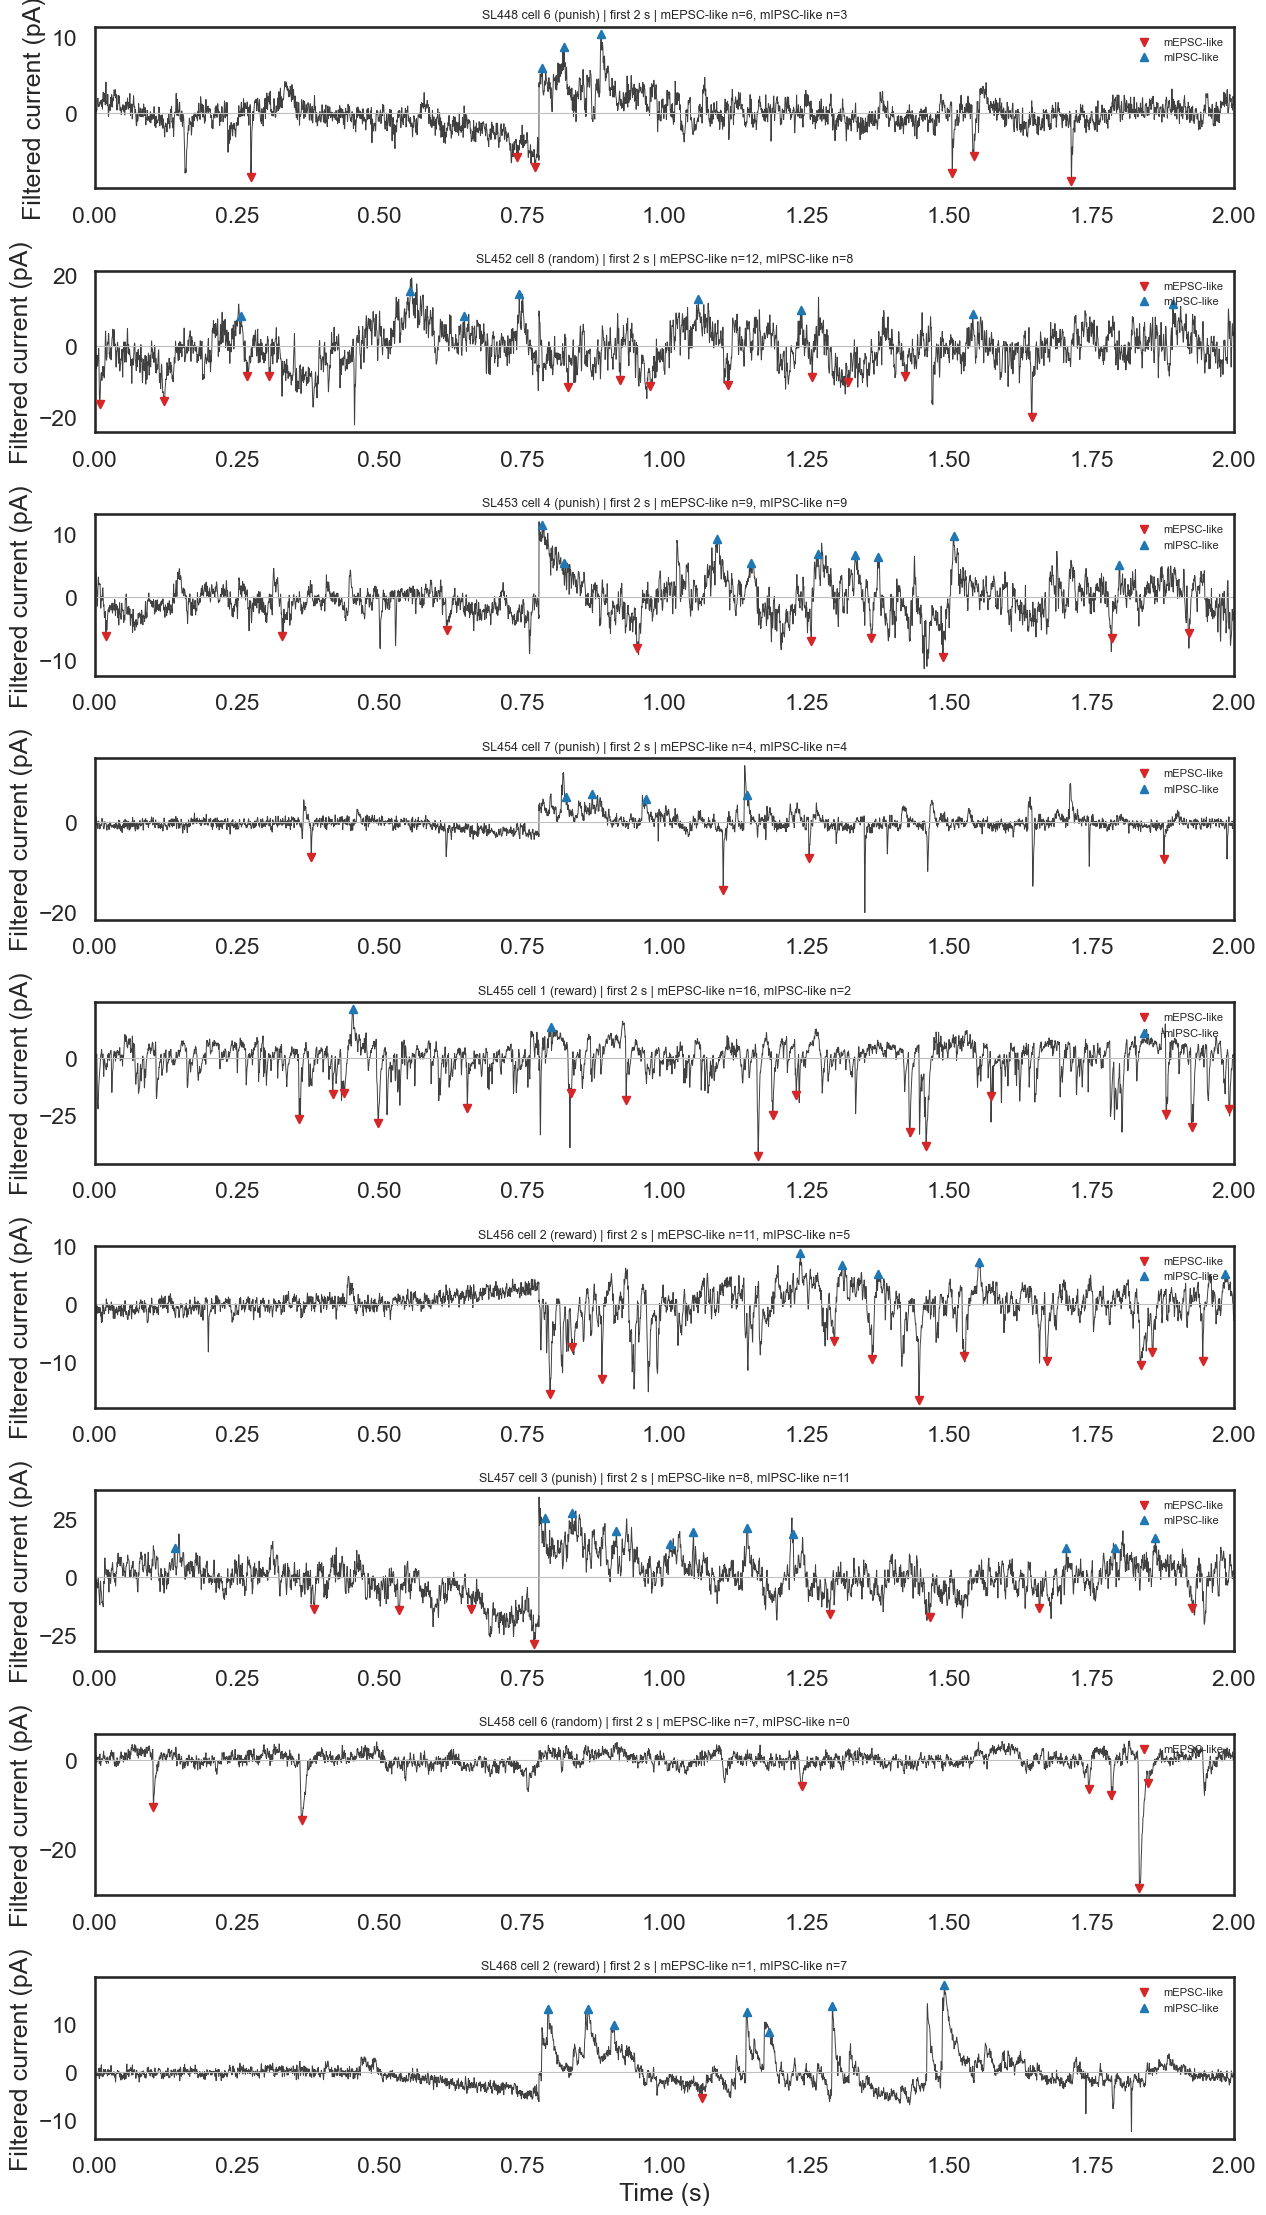

In [793]:
# display(rc_baseline_analysis_log_df)
if rc_baseline_comparison_df.empty:
    raise ValueError(
        "No cells had usable RC-baseline data. "
        "See rc_baseline_analysis_log_df."
    )
display(rc_baseline_comparison_df)

rc_baseline_validation_figures = plot_mini_trace_overview(
    rc_baseline_trace_records,
    duration_s=2.0,
    records_per_figure=20, # how many animals' example traces get stacked into a single figure before starting a new one
)
plt.show()


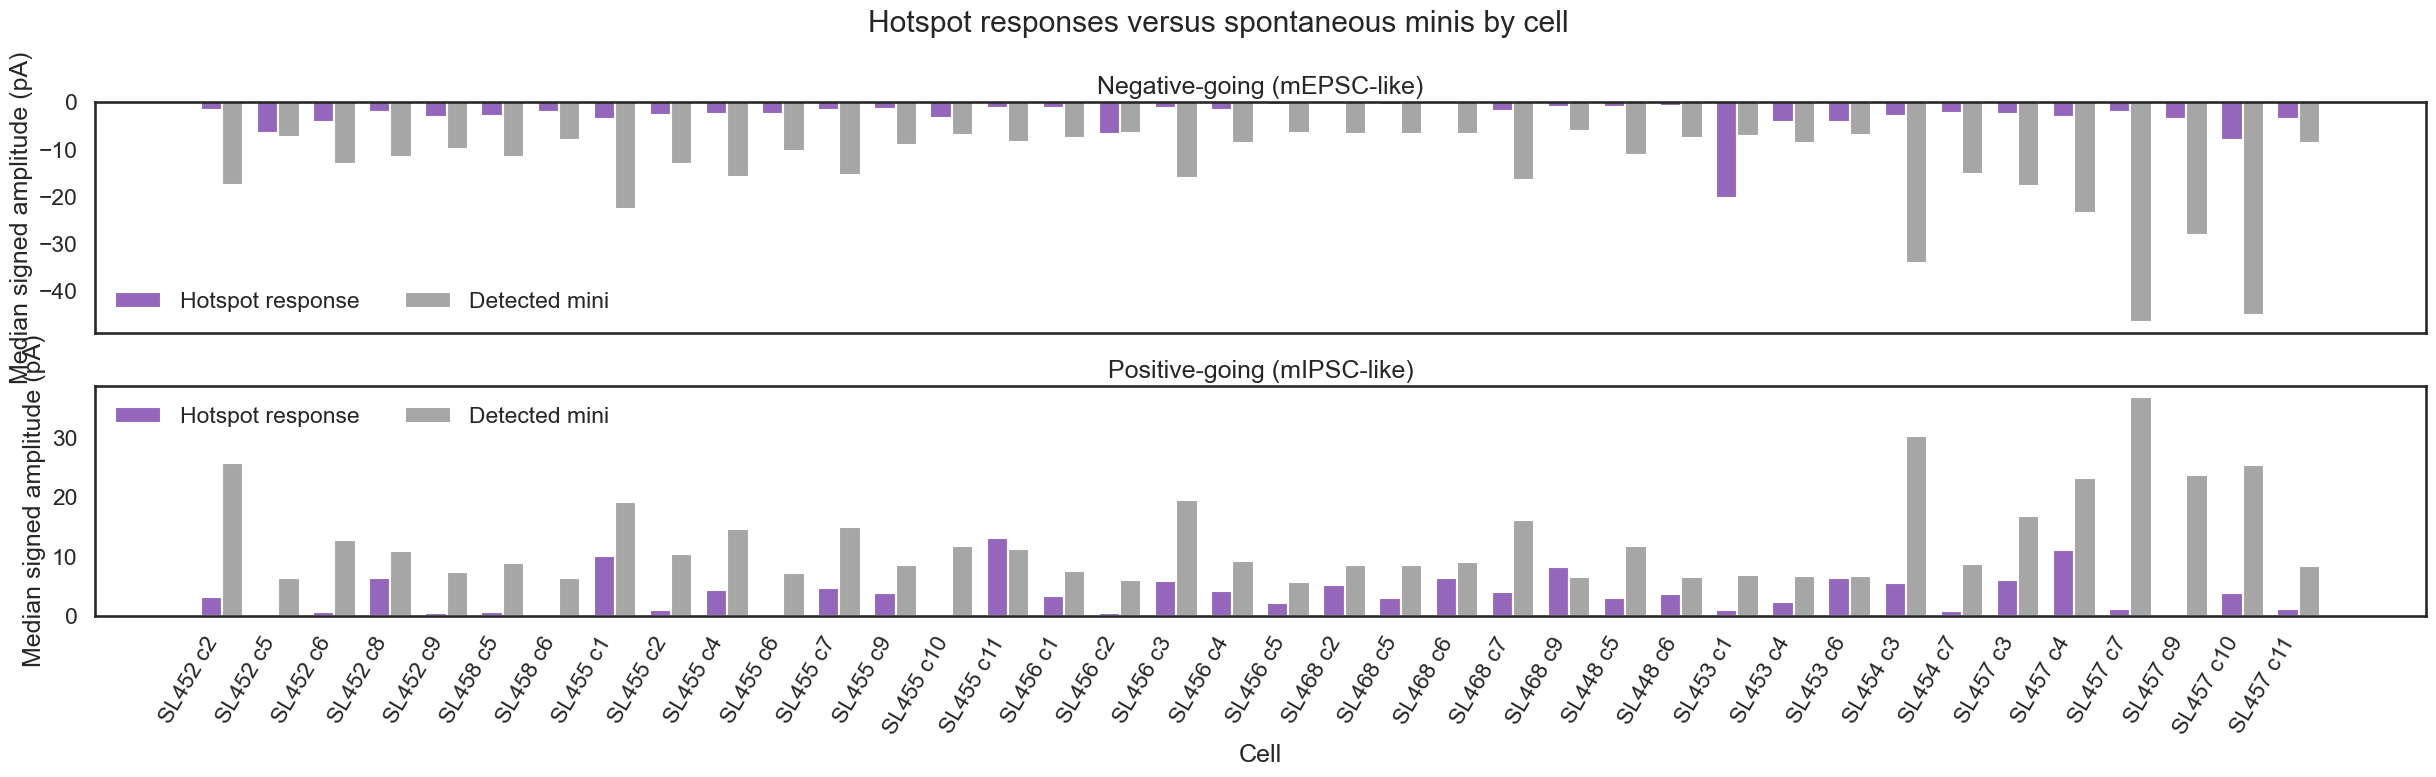

In [794]:
# Cell-by-cell comparison of median signed hotspot and mini amplitudes.
mini_plot_df = rc_baseline_comparison_df.copy()
mini_plot_df["group"] = pd.Categorical(
    mini_plot_df["group"], categories=GROUP_ORDER, ordered=True
)
mini_plot_df = mini_plot_df.sort_values(
    ["group", "animal", "cell"]
).reset_index(drop=True)
x = np.arange(len(mini_plot_df), dtype=float)
labels = [
    f"{row.animal} c{row.cell}"
    for row in mini_plot_df.itertuples(index=False)
]
bar_width = 0.38
fig, axes = plt.subplots(
    2, 1, figsize=(max(12, 0.65 * len(mini_plot_df)), 8), sharex=True
)
for ax, hotspot_column, mini_column, title in (
    (axes[0], "hotspot_min_pa", "mini_min_pa", "Negative-going (mEPSC-like)"),
    (axes[1], "hotspot_max_pa", "mini_max_pa", "Positive-going (mIPSC-like)"),
):
    ax.bar(
        x - bar_width / 2, mini_plot_df[hotspot_column],
        width=bar_width, color="tab:purple", label="Hotspot response",
    )
    ax.bar(
        x + bar_width / 2, mini_plot_df[mini_column],
        width=bar_width, color="0.65", label="Detected mini",
    )
    ax.axhline(0, color="0.2", linewidth=0.8)
    ax.set_ylabel("Median signed amplitude (pA)")
    ax.set_title(title)
    ax.legend(frameon=False, ncol=2)
axes[1].set_xticks(x, labels, rotation=60, ha="right")
axes[1].set_xlabel("Cell")
fig.suptitle("Hotspot responses versus spontaneous minis by cell")
fig.tight_layout()
plt.show()


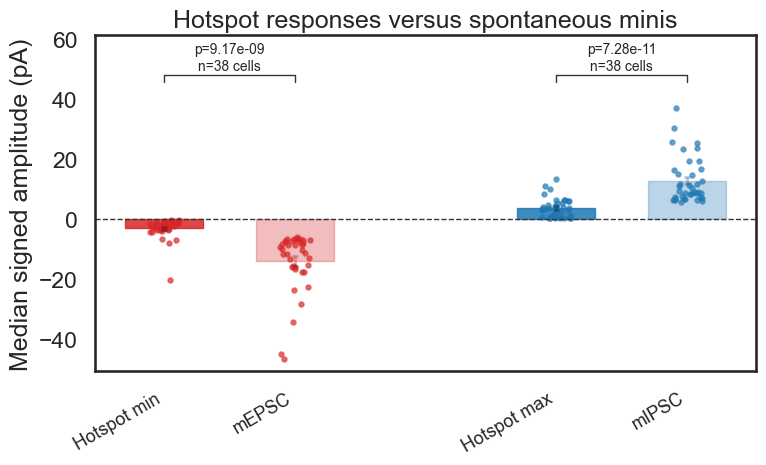

,comparison,n_cells,statistic,p_value
0,Hotspot min vs mEPSC,38,27.0,9.174983e-09
1,Hotspot max vs mIPSC,38,5.0,7.275958e-11


In [795]:
# Cell-matched hotspot and mini amplitudes with paired comparisons.
from scipy.stats import wilcoxon

comparison_specs = [
    ("hotspot_min_pa", "mini_min_pa", "Hotspot min", "mEPSC"),
    ("hotspot_max_pa", "mini_max_pa", "Hotspot max", "mIPSC"),
]
bar_values, statistics = [], []
for hotspot_column, mini_column, hotspot_label, mini_label in comparison_specs:
    paired = rc_baseline_comparison_df[[hotspot_column, mini_column]].apply(
        pd.to_numeric, errors="coerce"
    ).dropna()
    paired = paired[np.isfinite(paired).all(axis=1)]
    if paired.empty:
        break
    bar_values.extend([
        paired[hotspot_column].to_numpy(dtype=float),
        paired[mini_column].to_numpy(dtype=float),
    ])
    difference = paired[hotspot_column] - paired[mini_column]
    result = (
        (0.0, 1.0)
        if np.allclose(difference, 0)
        else wilcoxon(
            paired[hotspot_column], paired[mini_column],
            alternative="two-sided",
        )
    )
    statistics.append({
        "comparison": f"{hotspot_label} vs {mini_label}",
        "n_cells": len(paired),
        "statistic": float(result[0]),
        "p_value": float(result[1]),
    })

if len(bar_values) != 4:
    print("Both complete hotspot-mini pairs are required for this plot.")
else:
    labels = ["Hotspot min", "mEPSC", "Hotspot max", "mIPSC"]
    positions = [0, 1, 3, 4]
    colors = [
        to_rgba("tab:red", 0.85), to_rgba("tab:red", 0.30),
        to_rgba("tab:blue", 0.85), to_rgba("tab:blue", 0.30),
    ]
    fig, ax = plt.subplots(figsize=(8, 5))
    ndap.plotScatterBar(
        bar_values, labels=labels, colors=colors, positions=positions,
        style="bar", scatter_alpha=0.6, ax=ax,
    )
    ax.set_xticks(positions, labels, fontsize=13)
    ax.axhline(0, color="0.2", linestyle="--", linewidth=1)
    ax.set_ylabel(f"{MINI_CELL_SUMMARY.title()} signed amplitude (pA)")
    ax.set_title("Hotspot responses versus spontaneous minis")

    ymin, ymax = ax.get_ylim()
    span = ymax - ymin
    bracket_y, bracket_height = ymax + 0.05 * span, 0.025 * span
    for (left, right), result in zip(((0, 1), (3, 4)), statistics):
        ax.plot(
            [left, left, right, right],
            [bracket_y, bracket_y + bracket_height,
             bracket_y + bracket_height, bracket_y],
            color="0.2", linewidth=1,
        )
        ax.text(
            (left + right) / 2, bracket_y + 1.4 * bracket_height,
            f"p={result['p_value']:.3g}\n"
            f"n={result['n_cells']} cells",
            ha="center", va="bottom", fontsize=10,
        )
    ax.set_ylim(ymin, ymax + 0.22 * span)
    fig.tight_layout()
    plt.show()
    statistics_df = pd.DataFrame(statistics)
    display(statistics_df)

## 5. Fixed sign versus sign switching

This section separates two explanations for the active endpoint contrast: reward-to-punishment in task mode or dopamine-decrease-to-increase in dopamine mode. `COMPARISON_GROUPS` is selected automatically with `GROUPING_MODE`.

- **H1: fixed sign / magnitude change:** a hotspot retains its excitatory- or inhibitory-dominant identity, while condition can change $|x|$. For these unpaired data, the testable population-level implication is that the fraction on each side of zero is shared across conditions, while the conditional magnitude distributions may differ.
- **H2: sign switching / composition change:** condition changes the probability that a hotspot lies on each side of zero, and may also change $|x|$. A condition-specific sign fraction is consistent with sign switching or a change in population composition.

`SIGN_METRIC_COLUMN` chooses the signed quantity $x$ that Section 5 splits into a sign and a magnitude. Both options are bounded in $[-1, 1]$ and share the sign convention that positive is inhibitory-dominant, but they answer different questions. `"hotspot_sign"` is each hotspot's own AUC ratio, so it describes how one-sided that hotspot's trace is and knows nothing about the rest of the cell. `"synaptic_contribution"` (the default) is the hotspot's signed charge divided by the total absolute charge across its cell's retained hotspots, so its sign still gives dominance while its magnitude reports how much that hotspot matters relative to its siblings. Every subsection below reads one canonical `sign_metric` column, so switching metrics needs no other edit.

`ANALYSIS_WEIGHTING` controls the primary estimand throughout Section 5: `"animal_balanced"` nests hotspot → cell → animal, giving every cell equal weight inside its animal and every animal equal total weight, whereas `"pooled"` gives every hotspot equal weight. The default is animal-balanced. Whole-animal resampling and hierarchical validation preserve animal clustering under either setting.


### 5.1 Separate sign fraction from within-sign magnitude

#### What this analysis measures

This analysis separates **which side of zero a hotspot occupies** from **how strongly it occupies that side**. This prevents a change in the mean sign index from being interpreted as sign switching when it could instead reflect a magnitude change among already excitatory- or inhibitory-dominant hotspots.

#### Analysis steps

1. Keep finite values of the metric named by `SIGN_METRIC_COLUMN` and classify each hotspot as excitatory-dominant ($x<-δ$), inhibitory-dominant ($x>δ$), or neutral ($|x|\leq\delta$).
2. Exclude neutral values from the two-sign comparison and calculate both pooled and animal-balanced inhibitory- and excitatory-dominant fractions for every condition.
3. Use the fraction selected by `ANALYSIS_WEIGHTING` as the primary estimate and retain the alternative as a sensitivity diagnostic.
4. Within each condition and sign class, summarize $|x|$ using sample size, animal count, mean, median, and interquartile range.
5. Plot the within-sign magnitude with `plotScatterBar` bars. Pooled mode summarizes raw hotspots; animal-balanced mode summarizes one point per animal, obtained by averaging hotspots within cell and then cells within animal, with the raw hotspots kept as a faint background cloud.
6. Plot the per-cell excitation/inhibition balance. For `synaptic_contribution` a cell's hotspots carry unit absolute mass, so summing them gives that cell's net-to-total charge ratio in $[-1, 1]$, independent of how many hotspots the cell contributed; `hotspot_sign` has no such normalization and is averaged instead.

#### What each panel plots

A spot's **value** is the column named by `SIGN_METRIC_COLUMN`. A spot is **decisive** when |value| > `SIGN_EPSILON` and **neutral** otherwise; **inhibitory-dominant** means value > +`SIGN_EPSILON`, **excitatory-dominant** means value < −`SIGN_EPSILON`. Animal balancing is always the same two-step nesting, written below as $\underset{\text{animals}}{\mathrm{avg}}\ \underset{\text{cells}}{\mathrm{avg}}$, and it is exactly what the weights in `analysis_weights` encode. Pooled weighting replaces both averages with one flat average over spots.

**Panel 1 — sign fraction.** Dots are animals.

$$
\text{cell fraction} = \frac{\#\ \text{inhibitory-dominant spots in the cell}}{\#\ \text{decisive spots in the cell}}
$$

$$
\text{bar height} = 100\% \times \underset{\text{animals}}{\mathrm{avg}}\ \underset{\text{cells}}{\mathrm{avg}}\ \text{cell fraction}
\qquad\qquad
\text{bar height (pooled)} = 100\% \times \frac{\#\ \text{inhibitory-dominant spots}}{\#\ \text{decisive spots}}
$$

Neutral spots leave both the numerator and the denominator.

**Panel 2 — within-sign magnitude.** One bar per condition × sign; dots are animals.

$$
\text{cell magnitude} = \underset{\substack{\text{spots of this sign} \\ \text{in the cell}}}{\mathrm{avg}}\ |\text{value}|
\qquad\qquad
\text{bar height} = \underset{\text{animals}}{\mathrm{avg}}\ \underset{\text{cells}}{\mathrm{avg}}\ \text{cell magnitude}
$$

Cells holding no spot of that sign are skipped. The error bar is the SEM across animals, and the faint cloud behind each bar is every individual spot's |value|.

**Panel 3 — cell E/I balance.** Dots are animals.

$$
\text{cell balance}
= \frac{\sum_{\text{spots in the cell}} \text{net charge}}{\sum_{\text{spots in the cell}} |\text{net charge}|}
\qquad\qquad
\text{bar height} = \underset{\text{animals}}{\mathrm{avg}}\ \underset{\text{cells}}{\mathrm{avg}}\ \text{cell balance}
$$

Because a cell's contributions always sum to 1 in absolute value, the balance lands in $[-1, +1]$ however many spots the cell had: $+1$ is a purely inhibitory cell, $-1$ purely excitatory, $0$ a fully cancelled one. `hotspot_sign` carries no such normalization, so summing it would merely grow with spot count and it is averaged over the cell instead. This is the only panel that keeps **all** spots, neutral included — a signed balance needs the whole distribution, not just the decisive tails.

The `analysis_log_df.inhi_frac` column from Section 1 applies the same threshold to `hotspot_sign` but keeps neutral hotspots in its denominator. Section 5 intentionally reports the inhibitory fraction among decisive (non-neutral) hotspots only, and it applies the threshold to whichever metric `SIGN_METRIC_COLUMN` selects. Because `SIGN_EPSILON` is an absolute cutoff and the two metrics do not share a scale, the cell below prints how many hotspots the current combination classifies as neutral.

#### Expected result under each hypothesis

- **If H1 is true:** the selected excitatory/inhibitory fractions should be similar across conditions, but one or both conditional $|x|$ distributions may shift.
- **If H2 is true:** the fraction of sign should differ across conditions. Conditional magnitudes may also differ, so a joint change supports a mixture of switching/composition and amplitude effects.

This subsection is descriptive; uncertainty and model-based comparisons are added below.


Section 5 metric: synaptic_contribution (synaptic contribution); neutral when |value| <= SIGN_EPSILON = 0.0.


,n_hotspots,n_neutral,neutral_percent
group,,,
random,219,0,0.0
reward,454,0,0.0
punish,251,0,0.0


,n_hotspots,n_animals,pooled_inhibitory_fraction,n_cells,animal_balanced_inhibitory_fraction,between_animal_sd,pooled_excitatory_fraction,animal_balanced_excitatory_fraction,analysis_inhibitory_fraction,analysis_excitatory_fraction
group,,,,,,,,,,
random,219,2,0.634703,7,0.214447,0.263991,0.365297,0.785553,0.214447,0.785553
reward,454,3,0.528634,18,0.773646,0.170159,0.471366,0.226354,0.773646,0.226354
punish,251,4,0.745020,13,0.643243,0.179595,0.254980,0.356757,0.643243,0.356757


,group,dominance,n_hotspots,n_animals,median_magnitude,mean_magnitude,q25,q75
0,punish,excitatory-dominant,64,4,0.009972,0.050266,0.005346,0.056199
1,punish,inhibitory-dominant,187,4,0.038022,0.100714,0.014189,0.105328
2,random,excitatory-dominant,80,2,0.074286,0.292513,0.023900,0.218404
3,random,inhibitory-dominant,139,2,0.000747,0.030625,0.000741,0.020497
4,reward,excitatory-dominant,214,3,0.054395,0.099592,0.008294,0.190811
5,reward,inhibitory-dominant,240,3,0.115401,0.258435,0.045860,0.273236


,n_animals,animal_balanced_cell_balance,between_animal_sd,n_cells,pooled_cell_balance
group,,,,,
random,2,-0.531994,0.660805,7,-0.331740
reward,3,0.637051,0.254725,18,0.603583
punish,4,0.499353,0.470647,13,0.313657


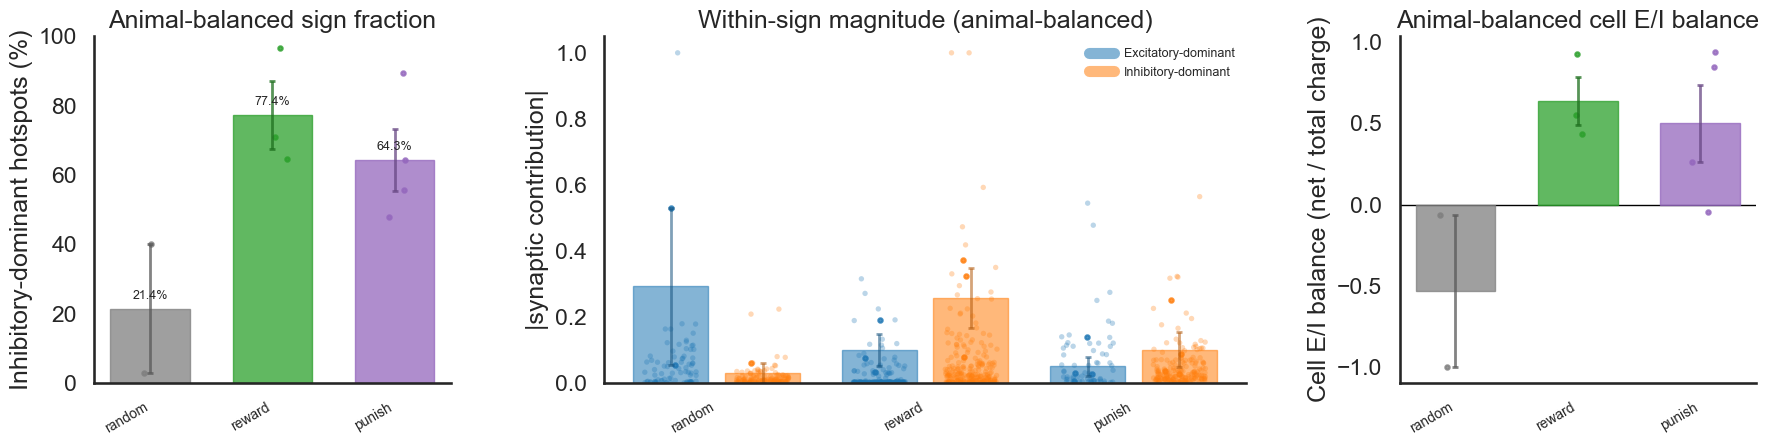

In [796]:
from scipy.optimize import linprog, minimize
from scipy.sparse import lil_matrix
from scipy.special import betaln, expit, gammaln


# SIGN_EPSILON is configured near the top of the notebook. Values inside
# [-SIGN_EPSILON, +SIGN_EPSILON] are treated as neutral throughout.


VALID_ANALYSIS_WEIGHTINGS = {"animal_balanced", "pooled"}
ANALYSIS_WEIGHTING = str(ANALYSIS_WEIGHTING).strip().lower()
if ANALYSIS_WEIGHTING not in VALID_ANALYSIS_WEIGHTINGS:
    raise ValueError(
        "ANALYSIS_WEIGHTING must be 'animal_balanced' or 'pooled'."
    )
WEIGHTING_LABEL = (
    "Animal-balanced"
    if ANALYSIS_WEIGHTING == "animal_balanced"
    else "Pooled"
)

# SIGN_METRIC_COLUMN is configured near the top of the notebook. Both options are
# bounded in [-1, 1] and share the sign convention that positive is inhibitory-
# dominant, so the whole of Section 5 works on either one unchanged.
VALID_SIGN_METRICS = {
    "hotspot_sign": "sign index",
    "synaptic_contribution": "synaptic contribution",
}
SIGN_METRIC_COLUMN = str(SIGN_METRIC_COLUMN).strip()
if SIGN_METRIC_COLUMN not in VALID_SIGN_METRICS:
    raise ValueError(
        "SIGN_METRIC_COLUMN must be one of "
        f"{sorted(VALID_SIGN_METRICS)}; received {SIGN_METRIC_COLUMN!r}."
    )
SIGN_METRIC_LABEL = VALID_SIGN_METRICS[SIGN_METRIC_COLUMN]


def analysis_weights(frame, weighting=ANALYSIS_WEIGHTING):
    """Return normalized hotspot weights for the selected estimand.

    Animal balancing nests hotspot -> cell -> animal: each hotspot is weighted
    by 1 / (cells in its animal x hotspots in its cell), so every cell carries
    the same mass inside its animal and every animal the same mass inside its
    group. Without the cell level a cell contributing 30 hotspots outvotes ten
    cells contributing 3 each in the same animal. Frames without a ``cell``
    column fall back to the flat hotspot -> animal nesting.
    """
    if frame.empty:
        return np.array([], dtype=float)
    if weighting == "pooled":
        return np.full(len(frame), 1.0 / len(frame))
    if "cell" not in frame.columns:
        counts = frame.groupby("animal", observed=True)["animal"].transform(
            "size"
        )
        weights = 1.0 / counts.to_numpy(dtype=float)
        return weights / weights.sum()
    hotspots_per_cell = (
        frame.groupby(["animal", "cell"], observed=True)["cell"]
        .transform("size")
        .to_numpy(dtype=float)
    )
    cells_per_animal = (
        frame.groupby("animal", observed=True)["cell"]
        .transform("nunique")
        .to_numpy(dtype=float)
    )
    weights = 1.0 / (cells_per_animal * hotspots_per_cell)
    return weights / weights.sum()


def weighted_quantile(values, quantiles, weights):
    """Calculate weighted quantiles using centered empirical mass."""
    values = np.asarray(values, dtype=float)
    quantiles = np.atleast_1d(quantiles).astype(float)
    weights = np.asarray(weights, dtype=float)
    finite = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not finite.any():
        return np.full(len(quantiles), np.nan)
    values = values[finite]
    weights = weights[finite]
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = (np.cumsum(weights) - 0.5 * weights) / weights.sum()
    return np.interp(quantiles, cumulative, values)


def prepare_sign_analysis_data(hotspot_df, epsilon=None, column=None):
    """Return finite values of the selected metric with biological sign labels.

    The chosen column is renamed to ``sign_metric`` so every downstream cell in
    Section 5 stays metric-agnostic; only ``SIGN_METRIC_COLUMN`` decides which
    hotspot quantity is actually decomposed into a sign and a magnitude.
    """
    epsilon = SIGN_EPSILON if epsilon is None else float(epsilon)
    column = SIGN_METRIC_COLUMN if column is None else str(column)
    required = {"group", "animal", column}
    missing = required.difference(hotspot_df.columns)
    if missing:
        raise ValueError(f"hotspot_df is missing columns: {sorted(missing)}")

    data = hotspot_df.loc[
        hotspot_df["group"].isin(GROUP_ORDER),
        ["group", "animal", "cell", column],
    ].copy()
    data = data.rename(columns={column: "sign_metric"})
    data["sign_metric"] = pd.to_numeric(data["sign_metric"], errors="coerce")
    data = data[np.isfinite(data["sign_metric"])].copy()
    data["dominance"] = classify_hotspot_signs(
        data["sign_metric"], epsilon
    )
    data["magnitude"] = data["sign_metric"].abs()
    return data


sign_analysis_df = prepare_sign_analysis_data(hotspot_metrics_df)
decisive_sign_df = sign_analysis_df[
    sign_analysis_df["dominance"] != "neutral"
].copy()
if decisive_sign_df.empty:
    raise ValueError("No non-neutral hotspot signs are available for Section 5.")
decisive_sign_df["is_inhibitory"] = decisive_sign_df[
    "dominance"
].eq("inhibitory-dominant").astype(int)

# SIGN_EPSILON is an absolute cutoff, but the two metrics do not share a scale:
# synaptic_contribution shrinks as a cell contributes more hotspots, so the same
# epsilon can discard a very different share of hotspots as neutral. Report that
# share rather than letting the metric choice change the denominator silently.
neutral_summary_df = (
    sign_analysis_df["dominance"].eq("neutral")
    .groupby(sign_analysis_df["group"], observed=True)
    .agg(n_hotspots="size", n_neutral="sum")
    .reindex(GROUP_ORDER)
)
neutral_summary_df["neutral_percent"] = (
    100 * neutral_summary_df["n_neutral"] / neutral_summary_df["n_hotspots"]
)
print(
    f"Section 5 metric: {SIGN_METRIC_COLUMN} ({SIGN_METRIC_LABEL}); "
    f"neutral when |value| <= SIGN_EPSILON = {SIGN_EPSILON}."
)
display(neutral_summary_df)

# Keep both summaries; ANALYSIS_WEIGHTING selects the primary one below.
# The animal-level fraction nests cells: each cell's own inhibitory fraction
# is averaged within animal, so a high-yield cell no longer dominates its
# animal. n_hotspots and n_inhibitory stay raw counts for the pooled estimand
# and for the cluster bootstrap in 5.2.
cell_sign_fraction_df = (
    decisive_sign_df
    .groupby(["group", "animal", "cell"], observed=True)
    .agg(
        n_hotspots=("sign_metric", "size"),
        n_inhibitory=("is_inhibitory", "sum"),
        inhibitory_fraction=("is_inhibitory", "mean"),
    )
    .reset_index()
)
animal_sign_fraction_df = (
    cell_sign_fraction_df
    .groupby(["group", "animal"], observed=True)
    .agg(
        n_cells=("cell", "nunique"),
        n_hotspots=("n_hotspots", "sum"),
        n_inhibitory=("n_inhibitory", "sum"),
        inhibitory_fraction=("inhibitory_fraction", "mean"),
    )
    .reset_index()
)
animal_sign_fraction_df["excitatory_fraction"] = (
    1.0 - animal_sign_fraction_df["inhibitory_fraction"]
)

pooled_sign_summary = (
    decisive_sign_df
    .groupby("group", observed=True)
    .agg(
        n_hotspots=("sign_metric", "size"),
        n_animals=("animal", "nunique"),
        pooled_inhibitory_fraction=("is_inhibitory", "mean"),
    )
)
balanced_sign_summary = (
    animal_sign_fraction_df.groupby("group", observed=True)
    .agg(
        n_cells=("n_cells", "sum"),
        animal_balanced_inhibitory_fraction=("inhibitory_fraction", "mean"),
        between_animal_sd=("inhibitory_fraction", "std"),
    )
)
sign_fraction_summary_df = pooled_sign_summary.join(balanced_sign_summary)
sign_fraction_summary_df["pooled_excitatory_fraction"] = (
    1.0 - sign_fraction_summary_df["pooled_inhibitory_fraction"]
)
sign_fraction_summary_df["animal_balanced_excitatory_fraction"] = (
    1.0 - sign_fraction_summary_df["animal_balanced_inhibitory_fraction"]
)
sign_fraction_summary_df = sign_fraction_summary_df.reindex(GROUP_ORDER)

fraction_column = (
    "animal_balanced_inhibitory_fraction"
    if ANALYSIS_WEIGHTING == "animal_balanced"
    else "pooled_inhibitory_fraction"
)
sign_fraction_summary_df["analysis_inhibitory_fraction"] = (
    sign_fraction_summary_df[fraction_column]
)
sign_fraction_summary_df["analysis_excitatory_fraction"] = (
    1.0 - sign_fraction_summary_df["analysis_inhibitory_fraction"]
)

magnitude_records = []
for (group, dominance), rows in decisive_sign_df.groupby(
    ["group", "dominance"], observed=True
):
    weights = analysis_weights(rows)
    values = rows["magnitude"].to_numpy(dtype=float)
    q25, median, q75 = weighted_quantile(
        values, [0.25, 0.5, 0.75], weights
    )
    magnitude_records.append({
        "group": group,
        "dominance": dominance,
        "n_hotspots": len(rows),
        "n_animals": rows["animal"].nunique(),
        "median_magnitude": median,
        "mean_magnitude": np.average(values, weights=weights),
        "q25": q25,
        "q75": q75,
    })
magnitude_summary_df = pd.DataFrame(magnitude_records)

display(sign_fraction_summary_df)
display(magnitude_summary_df)

underrepresented_groups = sign_fraction_summary_df.index[
    sign_fraction_summary_df["n_animals"] < 2
].tolist()
if underrepresented_groups:
    print(
        "Caution: fewer than two animals contributed valid hotspots for "
        f"{underrepresented_groups}. Their Section 5 results are descriptive "
        "and cannot estimate between-animal uncertainty."
    )

fig, (ax_fraction, ax_magnitude, ax_balance) = plt.subplots(
    1,
    3,
    figsize=(18, 4.8),
    gridspec_kw={"width_ratios": [1, 1.8, 1]},
)

# Panel 1: primary inhibitory-dominant fraction. Animal-level fractions
# are overlaid as diagnostics but do not determine the bar height.
group_positions = np.arange(len(GROUP_ORDER), dtype=float)
inhibitory_percent = (
    100
    * sign_fraction_summary_df.loc[
        GROUP_ORDER, "analysis_inhibitory_fraction"
    ].to_numpy(dtype=float)
)
bar_width = 0.65
fraction_distributions = []
for group in GROUP_ORDER:
    if ANALYSIS_WEIGHTING == "animal_balanced":
        values = animal_sign_fraction_df.loc[
            animal_sign_fraction_df["group"] == group,
            "inhibitory_fraction",
        ].to_numpy(dtype=float)
    else:
        values = (
            decisive_sign_df.loc[
                decisive_sign_df["group"] == group, "is_inhibitory"
            ]
            .to_numpy(dtype=float)
        )
    fraction_distributions.append(100 * values)
ndap.plotScatterBar(
    fraction_distributions,
    labels=GROUP_ORDER,
    style="bar",
    ax=ax_fraction,
    colors=[
        to_rgba(GROUP_COLORS[group], alpha=0.75) for group in GROUP_ORDER
    ],
    positions=group_positions,
    width=bar_width,
)
bars = ax_fraction.patches
for bar, value in zip(bars, inhibitory_percent):
    ax_fraction.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax_fraction.set_xticks(
    group_positions, GROUP_ORDER, rotation=30, ha="right",
    fontsize=GROUP_LABEL_FONTSIZE,
)
ax_fraction.set_ylabel("Inhibitory-dominant hotspots (%)")
ax_fraction.set_ylim(0, 100)
ax_fraction.set_title(f"{WEIGHTING_LABEL} sign fraction")
for spine in ("top", "right"):
    ax_fraction.spines[spine].set_visible(False)

# Panel 2: within-sign magnitude. Fixed offsets and widths keep every
# excitatory/inhibitory bar the same size.
def magnitude_plot_values(rows):
    """Return the points plotScatterBar should summarize into a bar.

    Pooled weighting plots every hotspot. Animal balancing plots one point per
    animal: cells are averaged within animal first, so the bar height equals
    the hotspot -> cell -> animal weighted mean in ``magnitude_summary_df`` and
    the error bar is a genuine between-animal SEM. Point-count tricks cannot
    express two nesting levels at once, which is why the raw hotspots are drawn
    separately as a faint cloud instead.
    """
    if ANALYSIS_WEIGHTING == "pooled":
        return rows["magnitude"].to_numpy(dtype=float)

    cell_means = rows.groupby(["animal", "cell"], observed=True)[
        "magnitude"
    ].mean()
    return (
        cell_means.groupby("animal", observed=True)
        .mean()
        .to_numpy(dtype=float)
    )


dominance_order = ["excitatory-dominant", "inhibitory-dominant"]
dominance_colors = {
    "excitatory-dominant": "tab:blue",
    "inhibitory-dominant": "tab:orange",
}
sign_bar_offsets = [-0.22, 0.22]
sign_bar_width = 0.36
positions, distributions, colors, hotspot_clouds = [], [], [], []
for group_index, group in enumerate(GROUP_ORDER):
    for sign_index, dominance in enumerate(dominance_order):
        rows = decisive_sign_df.loc[
            (decisive_sign_df["group"] == group)
            & (decisive_sign_df["dominance"] == dominance)
        ]
        values = magnitude_plot_values(rows) if len(rows) else np.array([])
        if len(values):
            positions.append(group_index + sign_bar_offsets[sign_index])
            distributions.append(values)
            colors.append(to_rgba(dominance_colors[dominance], alpha=0.55))
            hotspot_clouds.append(rows["magnitude"].to_numpy(dtype=float))

# Faint hotspot-level cloud, drawn first so the animal points sit on top. The
# bar summarizes animals; this keeps the raw spread the box plot used to show.
for position, cloud, color in zip(positions, hotspot_clouds, colors):
    cloud_jitter = (
        np.random.rand(len(cloud)) - 0.5
    ) * sign_bar_width * 0.7
    ax_magnitude.scatter(
        position + cloud_jitter,
        cloud,
        s=15,
        color=color[:3] + (0.3,),
        linewidths=0,
        edgecolors="none",
    )

ndap.plotScatterBar(
    distributions,
    style="bar",
    ax=ax_magnitude,
    colors=colors,
    positions=positions,
    width=sign_bar_width,
)
ax_magnitude.plot(
    [], [], color="tab:blue", linewidth=8, alpha=0.55,
    label="Excitatory-dominant",
)
ax_magnitude.plot(
    [], [], color="tab:orange", linewidth=8, alpha=0.55,
    label="Inhibitory-dominant",
)
ax_magnitude.set_xticks(
    group_positions, GROUP_ORDER, rotation=30, ha="right",
    fontsize=GROUP_LABEL_FONTSIZE,
)
# Contribution magnitudes sit far below 1, so a fixed 0-1 axis would squash
# them into the floor. Scale to the observed data instead of clipping it.
magnitude_ceiling = 1.05 * float(
    np.nanmax(decisive_sign_df["magnitude"].to_numpy(dtype=float))
)
ax_magnitude.set_ylabel(f"|{SIGN_METRIC_LABEL}|")
ax_magnitude.set_ylim(0, magnitude_ceiling)
ax_magnitude.set_title(f"Within-sign magnitude ({WEIGHTING_LABEL.lower()})")
ax_magnitude.legend(frameon=False, fontsize=9)
for spine in ("top", "right"):
    ax_magnitude.spines[spine].set_visible(False)

# Panel 3: per-cell excitation/inhibition balance. synaptic_contribution
# carries exactly unit absolute mass per cell, so summing a cell's hotspots
# returns net_charge / total_|charge| -- a balance index in [-1, 1] that
# already weights each hotspot by its share of the cell's charge and does not
# shrink as a cell contributes more hotspots. hotspot_sign has no such
# normalization, so its sum would grow with hotspot count; average it instead.
# Neutral hotspots stay in: a signed balance needs the whole distribution, not
# only the decisive tails.
CELL_BALANCE_AGGREGATION = (
    "sum" if SIGN_METRIC_COLUMN == "synaptic_contribution" else "mean"
)
cell_balance_df = (
    sign_analysis_df
    .groupby(["group", "animal", "cell"], observed=True)["sign_metric"]
    .agg(CELL_BALANCE_AGGREGATION)
    .rename("cell_balance")
    .reset_index()
)
# Cells are the unit of analysis in this panel, so animal balancing averages
# cells within animal before averaging animals; pooled keeps every cell equal.
animal_balance_df = (
    cell_balance_df
    .groupby(["group", "animal"], observed=True)["cell_balance"]
    .mean()
    .reset_index()
)
balance_summary_df = (
    animal_balance_df.groupby("group", observed=True)["cell_balance"]
    .agg(
        n_animals="size",
        animal_balanced_cell_balance="mean",
        between_animal_sd="std",
    )
    .join(
        cell_balance_df.groupby("group", observed=True)["cell_balance"]
        .agg(n_cells="size", pooled_cell_balance="mean")
    )
    .reindex(GROUP_ORDER)
)
display(balance_summary_df)

balance_frame = (
    animal_balance_df
    if ANALYSIS_WEIGHTING == "animal_balanced"
    else cell_balance_df
)
balance_distributions = [
    balance_frame.loc[
        balance_frame["group"] == group, "cell_balance"
    ].to_numpy(dtype=float)
    for group in GROUP_ORDER
]

ndap.plotScatterBar(
    balance_distributions,
    labels=GROUP_ORDER,
    style="bar",
    ax=ax_balance,
    colors=[
        to_rgba(GROUP_COLORS[group], alpha=0.75) for group in GROUP_ORDER
    ],
    positions=group_positions,
    width=bar_width,
)
# Positive is inhibitory-dominant, so the zero line marks the sign flip.
ax_balance.axhline(0, color="black", linewidth=1, zorder=0)
ax_balance.set_xticks(
    group_positions, GROUP_ORDER, rotation=30, ha="right",
    fontsize=GROUP_LABEL_FONTSIZE,
)
balance_axis_label = (
    "net / total charge"
    if SIGN_METRIC_COLUMN == "synaptic_contribution"
    else f"mean {SIGN_METRIC_LABEL}"
)
ax_balance.set_ylabel(f"Cell E/I balance ({balance_axis_label})")
ax_balance.set_title(f"{WEIGHTING_LABEL} cell E/I balance")
for spine in ("top", "right"):
    ax_balance.spines[spine].set_visible(False)

fig.tight_layout(w_pad=2.5)
plt.show()


### 5.1b Within-cell concentration of synaptic drive

Panel 2 of 5.1 asks whether inhibitory hotspots are individually larger than excitatory ones across the population. It cannot say whether that happens *inside* a cell: the same population difference arises if some cells are inhibitory with large spots while other cells are excitatory with small ones. This subsection works one cell at a time.

Each cell's absolute contributions are renormalized to a probability vector $p$ (so the statistics are defined for `hotspot_sign` as well as for `synaptic_contribution`, whose absolute mass already sums to one per cell), and two statistics are computed.

- **Effective number of spots**, $N_\text{eff} = 1/\sum_i p_i^2$, the inverse Herfindahl index. It lies between 1 and the number of stimulated spots and reads directly: a cell with $N_\text{eff}=2.3$ carries its drive as if it had 2.3 equally sized spots. It weights the large spots heavily and barely moves when small spots are added, which is what makes it usable here.
- **Spots needed to reach `COVERAGE_FRACTION`** (default 80%) of the cell's absolute contribution, and the **mean signed contribution of that covering set** $S$, $\frac{1}{|S|}\sum_{i \in S} c_i$. The count is the inverse framing of $N_\text{eff}$ and easier to state in a sentence: 3 spots out of 40 is concentrated, 30 is not. The plotted quantity is `coverage_mean_signed`, the mean signed contribution of the covering spots: it stays on the contribution scale, at the cost of shrinking as a cell needs more spots to reach coverage, so it is not comparable between cells with very different covering-set sizes. Two normalized alternatives are computed alongside it -- `coverage_signed_balance` divides by the covering set's own mass and spans $[-1, 1]$ at any coverage level, and `coverage_signed_share` divides by the cell's total mass. Swap the column name in the last `plot_concentration_panel` call to plot either one.

#### What each panel plots

Every cell's spots are first turned into shares, using **all** finite spots, neutral included:

$$
\text{share of a spot} = \frac{|\text{value of the spot}|}{\sum_{\text{spots in the cell}} |\text{value}|}
$$

All three panels then nest the same way as panel 3 of 5.1, $\underset{\text{animals}}{\mathrm{avg}}\ \underset{\text{cells}}{\mathrm{avg}}$, and the faint cloud behind each bar is the individual cells.

**Left — effective number of spots.**

$$
\text{effective spots} = \frac{1}{\sum_{\text{spots in the cell}} \text{share}^{2}}
$$

It equals the spot count when every spot is the same size and $1$ when a single spot carries everything, so "376 spots but 106 effective" says the drive is spread thin rather than concentrated.

**Middle — spots carrying 80% of the drive.** With the shares sorted largest first,

$$
\text{covering spots} = \min\left\{\, n \ :\ \sum_{m=1}^{n} \text{share}_{(m)} \ \geq\ \texttt{COVERAGE\_FRACTION} \,\right\}
$$

**Right — mean signed contribution of those spots.**

$$
\text{mean signed contribution} = \underset{\text{covering spots}}{\mathrm{avg}}\ \text{value}
$$

Two normalized alternatives are computed but not plotted:

$$
\texttt{coverage\_signed\_balance} = \frac{\sum_{\text{covering}} \text{value}}{\sum_{\text{covering}} |\text{value}|}
\qquad\qquad
\texttt{coverage\_signed\_share} = \frac{\sum_{\text{covering}} \text{value}}{\sum_{\text{cell}} |\text{value}|}
$$

The balance runs $-1$ to $+1$ at any coverage level; the share is bounded by roughly $\pm$`COVERAGE_FRACTION`.

The number of stimulated spots is a property of the search, not the cell, and `HOTSPOT_CRITERIA` decides how many small spots exist at all -- a stricter threshold deletes small spots and mechanically raises measured concentration. The panel-3 balance index is nearly immune to this; these are not. The covering-spot count inherits this more strongly than $N_\text{eff}$ does -- a cell with five spots can never need twenty -- so the Spearman correlation of each against the spot count is printed per condition, and the result is worth rerunning at `threshold_factor` 2 versus 3.


Concentration analysis keeps 33 of 38 cells (>= 4 retained hotspots).


,n_cells,n_animals,median_n_hotspots,mean_n_eff,mean_participation,median_n_spots_for_coverage,mean_n_spots_for_coverage,mean_coverage_spot_fraction,mean_coverage_mean_signed,mean_coverage_signed_balance,mean_coverage_signed_share,rho_n_eff_vs_n_hotspots,rho_n_eff_p_value,rho_n_spots_for_coverage_vs_n_hotspots,rho_n_spots_for_coverage_p_value
group,,,,,,,,,,,,,,,
random,6,2,18.0,19.315245,0.659530,8.5,12.833333,0.455735,-0.042108,-0.157885,-0.133985,0.985611,3.090857e-04,0.970588,1.284857e-03
reward,15,3,12.0,14.574944,0.692628,5.0,11.133333,0.496745,0.085754,0.575700,0.429010,0.929157,5.570049e-07,0.979075,2.269019e-10
punish,12,4,14.5,11.505881,0.610694,6.5,8.166667,0.440110,0.052414,0.500000,0.376733,0.956219,1.176902e-06,0.957752,9.872604e-07


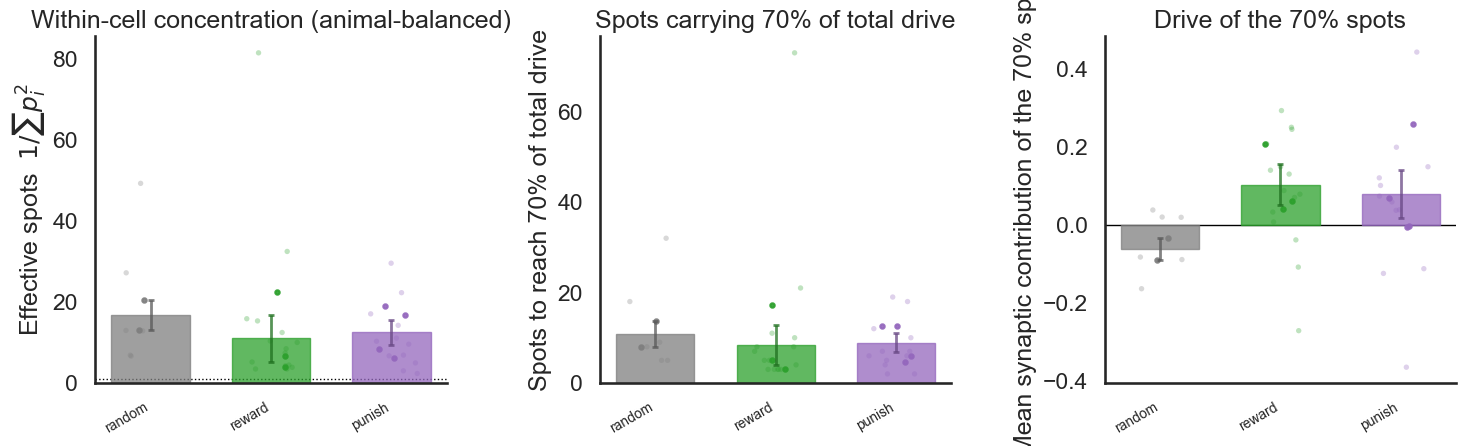

In [797]:
# Within-cell concentration of synaptic drive, one value per cell.
from scipy.stats import spearmanr

# Fraction of a cell's absolute contribution the "dominant" spots must cover.
# Change this one value to re-ask the question at 50%, 90%, and so on.
COVERAGE_FRACTION = 0.7
MIN_HOTSPOTS_FOR_CONCENTRATION = 4  # Concentration is degenerate below this.


def cell_concentration_metrics(signed_values, coverage=None):
    """Return concentration statistics for one cell's hotspots.

    Neutral hotspots are kept: they carry mass and belong in the denominator.
    Magnitudes are renormalized to a probability vector so the statistics stay
    defined for hotspot_sign, whose per-cell absolute mass is not fixed at one.
    """
    coverage = COVERAGE_FRACTION if coverage is None else float(coverage)
    signed = np.asarray(signed_values, dtype=float)
    magnitude = np.abs(signed)
    total = float(magnitude.sum())
    if total <= 0:
        return None
    shares = magnitude / total
    n_eff = float(1.0 / np.sum(shares ** 2))

    # Rank spots largest first; the covering set is the shortest prefix whose
    # cumulative mass reaches `coverage`. The tolerance keeps floating-point
    # cumulative sums from demanding one spot more than necessary.
    order = np.argsort(magnitude)[::-1]
    cumulative = np.cumsum(shares[order])
    n_cover = int(
        min(np.searchsorted(cumulative, coverage - 1e-12) + 1, signed.size)
    )
    covering_signed = signed[order[:n_cover]]
    covering_mass = float(np.abs(covering_signed).sum())

    return {
        "n_hotspots": int(signed.size),
        # Inverse Herfindahl: the number of equally sized spots that would
        # produce this much concentration. Bounded by 1 and n_hotspots.
        "n_eff": n_eff,
        # n_eff relative to what the cell could have reached; convenient but
        # far more spot-count dependent than n_eff itself.
        "participation": n_eff / signed.size,
        # How few spots account for `coverage` of the cell's drive.
        "n_spots_for_coverage": n_cover,
        "coverage_spot_fraction": n_cover / signed.size,
        # Which side those dominant spots fall on, in three normalizations.
        # The balance divides by the covering set's own mass, so it spans
        # [-1, 1] whatever the coverage level -- this is the plotted one. The
        # share divides by the cell's total mass instead, so it is bounded by
        # roughly +/- coverage. The mean is the literal per-spot average and
        # shrinks mechanically as more spots are needed to reach coverage.
        "coverage_signed_balance": float(
            covering_signed.sum() / covering_mass
        ),
        "coverage_signed_share": float(covering_signed.sum() / total),
        "coverage_mean_signed": float(covering_signed.mean()),
    }


concentration_records = []
for (group, animal, cell), rows in sign_analysis_df.groupby(
    ["group", "animal", "cell"], observed=True
):
    metrics = cell_concentration_metrics(rows["sign_metric"])
    if metrics is None:
        continue
    concentration_records.append(
        {"group": group, "animal": animal, "cell": cell, **metrics}
    )
cell_concentration_df = pd.DataFrame.from_records(concentration_records)
if cell_concentration_df.empty:
    raise ValueError("No cells carry nonzero synaptic mass.")

eligible_concentration_df = cell_concentration_df[
    cell_concentration_df["n_hotspots"] >= MIN_HOTSPOTS_FOR_CONCENTRATION
].copy()
print(
    f"Concentration analysis keeps {len(eligible_concentration_df)} of "
    f"{len(cell_concentration_df)} cells "
    f"(>= {MIN_HOTSPOTS_FOR_CONCENTRATION} retained hotspots)."
)
if eligible_concentration_df.empty:
    raise ValueError(
        "No cell reaches MIN_HOTSPOTS_FOR_CONCENTRATION; lower it or relax "
        "HOTSPOT_CRITERIA."
    )

concentration_summary_df = (
    eligible_concentration_df.groupby("group", observed=True)
    .agg(
        n_cells=("n_eff", "size"),
        n_animals=("animal", "nunique"),
        median_n_hotspots=("n_hotspots", "median"),
        mean_n_eff=("n_eff", "mean"),
        mean_participation=("participation", "mean"),
        median_n_spots_for_coverage=("n_spots_for_coverage", "median"),
        mean_n_spots_for_coverage=("n_spots_for_coverage", "mean"),
        mean_coverage_spot_fraction=("coverage_spot_fraction", "mean"),
        mean_coverage_mean_signed=("coverage_mean_signed", "mean"),
        mean_coverage_signed_balance=("coverage_signed_balance", "mean"),
        mean_coverage_signed_share=("coverage_signed_share", "mean"),
    )
    .reindex(GROUP_ORDER)
)
# Both n_eff and the spot count needed for coverage are bounded above by the
# number of stimulated spots, which the search sets rather than the biology.
# Report that coupling instead of assuming it away.
for column in ("n_eff", "n_spots_for_coverage"):
    rho_values, rho_p_values = [], []
    for group in GROUP_ORDER:
        rows = eligible_concentration_df[
            eligible_concentration_df["group"] == group
        ]
        if len(rows) >= 3:
            rho, p_value = spearmanr(rows["n_hotspots"], rows[column])
        else:
            rho, p_value = np.nan, np.nan
        rho_values.append(rho)
        rho_p_values.append(p_value)
    concentration_summary_df[f"rho_{column}_vs_n_hotspots"] = rho_values
    concentration_summary_df[f"rho_{column}_p_value"] = rho_p_values
display(concentration_summary_df)

# Cells are the unit of analysis; animal balancing averages cells within animal
# first, exactly as in the panel-3 balance index.
concentration_positions = np.arange(len(GROUP_ORDER), dtype=float)
concentration_bar_width = 0.65


def concentration_group_values(column):
    """Per-group arrays for plotScatterBar under the selected weighting."""
    if ANALYSIS_WEIGHTING == "animal_balanced":
        source = (
            eligible_concentration_df
            .groupby(["group", "animal"], observed=True)[column]
            .mean()
            .reset_index()
        )
    else:
        source = eligible_concentration_df
    return [
        source.loc[source["group"] == group, column].to_numpy(dtype=float)
        for group in GROUP_ORDER
    ]


def plot_concentration_panel(ax, column, ylabel, title, zero_line=False):
    """Bar of the selected estimand with the cell-level cloud behind it."""
    colors = [
        to_rgba(GROUP_COLORS[group], alpha=0.75) for group in GROUP_ORDER
    ]
    if ANALYSIS_WEIGHTING == "animal_balanced":
        # Bars and points summarize animals, so keep the cells visible too.
        for position, group, color in zip(
            concentration_positions, GROUP_ORDER, colors
        ):
            cloud = eligible_concentration_df.loc[
                eligible_concentration_df["group"] == group, column
            ].to_numpy(dtype=float)
            jitter = (
                np.random.rand(len(cloud)) - 0.5
            ) * concentration_bar_width * 0.7
            ax.scatter(
                position + jitter,
                cloud,
                s=15,
                color=color[:3] + (0.3,),
                linewidths=0,
                edgecolors="none",
            )
    ndap.plotScatterBar(
        concentration_group_values(column),
        labels=GROUP_ORDER,
        style="bar",
        ax=ax,
        colors=colors,
        positions=concentration_positions,
        width=concentration_bar_width,
        scatter_alpha=0.9,
    )
    if zero_line:
        ax.axhline(0, color="black", linewidth=1, zorder=0)
    ax.set_xticks(
        concentration_positions, GROUP_ORDER, rotation=30, ha="right",
        fontsize=GROUP_LABEL_FONTSIZE,
    )
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)


fig, (ax_neff, ax_coverage_count, ax_coverage_sign) = plt.subplots(
    1, 3, figsize=(15, 4.8)
)
plot_concentration_panel(
    ax_neff,
    "n_eff",
    r"Effective spots  $1/\sum p_i^2$",
    f"Within-cell concentration ({WEIGHTING_LABEL.lower()})",
)
ax_neff.axhline(
    1.0, color="black", linewidth=1, linestyle=":", zorder=0,
)
plot_concentration_panel(
    ax_coverage_count,
    "n_spots_for_coverage",
    f"Spots to reach {COVERAGE_FRACTION:.0%} of total drive",
    f"Spots carrying {COVERAGE_FRACTION:.0%} of total drive",
)
ax_coverage_count.set_ylim(bottom=0)
plot_concentration_panel(
    ax_coverage_sign,
    "coverage_mean_signed",
    f"Mean {SIGN_METRIC_LABEL} of the {COVERAGE_FRACTION:.0%} spots",
    f"Drive of the {COVERAGE_FRACTION:.0%} spots",
    zero_line=True,
)

fig.tight_layout(w_pad=2.5)
plt.show()


### 5.2 Minimum and maximum sign-switch mass

#### What this analysis measures

The baseline and comparison hotspots are unpaired, so an exact switch fraction is not identifiable. However, their inhibitory-dominant probabilities under the selected `ANALYSIS_WEIGHTING` constrain the fraction that would have different signs under any possible coupling of the two marginal distributions. These are the Fréchet bounds on sign disagreement.

Let $p_B=P_{baseline}(x>0)$ and $p_C=P_{comparison}(x>0)$. Then

$$
S_{switch,min}=|p_C-p_B|
$$

and

$$
S_{switch,max}=1-|p_B+p_C-1|.
$$

The lower bound is the probability mass that **must** cross zero to reconcile the two sign proportions. The upper bound is the largest sign disagreement compatible with those marginals; it is not an estimate of the actual switch rate.

#### Analysis steps

1. Calculate inhibitory-dominant fractions for `BASELINE_GROUP` and `COMPARISON_GROUP` using the selected weighting.
2. Use those fractions as $p_B$ and $p_C$. With animal balancing, each animal has equal total weight; with pooling, contribution is proportional to hotspot count.
3. Calculate $S_{switch,min}$ and $S_{switch,max}$ from the equations above.
4. If both comparison groups contain at least two contributing animals, resample whole animals within condition 10,000 times and report cluster-bootstrap intervals for both bounds. Otherwise, report only the descriptive bounds.

#### Expected result under each hypothesis

- **If H1 is true:** $p_B$ and $p_C$ should be similar, so $S_{switch,min}$ should be near zero within animal-level uncertainty.
- **If H2 is true:** a clearly positive $S_{switch,min}$ indicates that some cross-zero population mass is required. A large lower bound is stronger distribution-level evidence for switching/composition change.

These bounds do not reveal which hotspots switched or the direction of individual transitions.


In [798]:
def switch_fraction_bounds(p_positive_a, p_positive_b):
    """Fréchet bounds on sign disagreement from two positive marginals."""
    p_positive_a = float(p_positive_a)
    p_positive_b = float(p_positive_b)
    lower = abs(p_positive_b - p_positive_a)
    upper = 1.0 - abs(p_positive_a + p_positive_b - 1.0)
    return lower, upper


def bootstrap_switch_bounds(
    animal_fraction_df, n_bootstrap=10_000, seed=2026
):
    """Cluster-bootstrap selected-weighting bounds by animal."""
    counts = {
        group: animal_fraction_df.loc[
            animal_fraction_df["group"] == group,
            ["n_hotspots", "n_inhibitory", "inhibitory_fraction"],
        ].to_numpy(dtype=float)
        for group in COMPARISON_GROUPS
    }
    if any(len(values) == 0 for values in counts.values()):
        raise ValueError(
            f"{BASELINE_GROUP} and {COMPARISON_GROUP} must each "
            "contain at least one animal."
        )

    rng = np.random.default_rng(seed)
    samples = np.empty((n_bootstrap, 2), dtype=float)
    for index in range(n_bootstrap):
        fractions = {}
        for group, group_counts in counts.items():
            sampled = group_counts[
                rng.integers(0, len(group_counts), size=len(group_counts))
            ]
            if ANALYSIS_WEIGHTING == "animal_balanced":
                fractions[group] = sampled[:, 2].mean()
            else:
                fractions[group] = sampled[:, 1].sum() / sampled[:, 0].sum()
        samples[index] = switch_fraction_bounds(
            fractions[BASELINE_GROUP], fractions[COMPARISON_GROUP]
        )
    return samples


p_inhibitory = sign_fraction_summary_df["analysis_inhibitory_fraction"]
switch_min, switch_max = switch_fraction_bounds(
    p_inhibitory[BASELINE_GROUP], p_inhibitory[COMPARISON_GROUP]
)
comparison_animal_counts = animal_sign_fraction_df.groupby(
    "group", observed=True
)["animal"].nunique()
bootstrap_is_estimable = all(
    comparison_animal_counts.get(group, 0) >= 2
    for group in COMPARISON_GROUPS
)
if bootstrap_is_estimable:
    switch_bound_samples = bootstrap_switch_bounds(
        animal_sign_fraction_df
    )
    lower_ci = np.percentile(switch_bound_samples, 2.5, axis=0)
    upper_ci = np.percentile(switch_bound_samples, 97.5, axis=0)
else:
    switch_bound_samples = np.empty((0, 2))
    lower_ci = np.repeat(np.nan, 2)
    upper_ci = np.repeat(np.nan, 2)
switch_bounds_df = pd.DataFrame(
    {
        "estimate": [switch_min, switch_max],
        "cluster-bootstrap 2.5%": lower_ci,
        "cluster-bootstrap 97.5%": upper_ci,
    },
    index=["minimum sign-switch mass", "maximum sign-switch mass"],
)

display(
    pd.Series(
        {
            f"{BASELINE_GROUP} P(inhibitory-dominant)": (
                p_inhibitory[BASELINE_GROUP]
            ),
            f"{COMPARISON_GROUP} P(inhibitory-dominant)": (
                p_inhibitory[COMPARISON_GROUP]
            ),
        },
        name=f"{WEIGHTING_LABEL.lower()} estimate",
    ).to_frame()
)
display(switch_bounds_df)
if not bootstrap_is_estimable:
    print(
        "Cluster-bootstrap intervals are not reported because "
        f"{BASELINE_GROUP} and {COMPARISON_GROUP} must each have at "
        "least two contributing animals."
    )
print(
    "These are coupling bounds implied by unpaired marginal distributions; "
    "they do not identify which individual hotspots switched sign."
)


,animal-balanced estimate
reward P(inhibitory-dominant),0.773646
punish P(inhibitory-dominant),0.643243


,estimate,cluster-bootstrap 2.5%,cluster-bootstrap 97.5%
minimum sign-switch mass,0.130403,0.004995,0.343554
maximum sign-switch mass,0.583111,0.350593,0.792894


These are coupling bounds implied by unpaired marginal distributions; they do not identify which individual hotspots switched sign.


### 5.3 Sign-constrained optimal transport

#### What this analysis measures

Optimal transport asks how baseline probability mass must be reassigned to reproduce the comparison distribution. It provides a distribution-level comparison between a strict sign-fixed explanation, where transport across zero is forbidden, and a sign-switching explanation, where cross-zero transport is allowed.

For source bin $x_i$ and target bin $x_j$, the implemented cost is

$$
C(x_i,x_j)=|x_i-x_j|^2+\lambda\,I[\operatorname{sign}(x_i)\neq\operatorname{sign}(x_j)].
$$

where $|x_i-x_j|^2$ says "moving further is more expensive" and $\lambda\,I[\operatorname{sign}(x_i)\neq\operatorname{sign}(x_j)]$ determines the extra price to cross zero

The panel plots how much mass still has to change sign once switching is priced at $\lambda$:

$$
\text{cross-zero mass}(\lambda) = \sum_{\substack{\text{plan entries whose source and target} \\ \text{lie on opposite sides of zero}}} \text{transported mass}
$$

#### Analysis steps

1. Convert the weighted baseline and comparison hotspot distributions into 80 common bins spanning $[-L,L]$, where $L=\max_i |x_i|$ over the decisive hotspots. The grid follows the metric's actual range rather than a fixed $[-1,1]$, which would leave most bins empty for `synaptic_contribution`, and stays symmetric about zero so the cross-zero logic is unchanged.
2. Solve balanced transport with cross-zero entries fixed to zero. This strict sign-fixed problem is feasible only when the two groups have exactly the same total mass on each side of zero.
3. Solve unconstrained transport with $\lambda=0$ and report its squared movement cost and cross-zero mass.
4. Repeat over increasing $\lambda$ values. For each solution, separate the squared movement cost, cross-zero mass, and total penalized objective.
5. Plot how movement cost and cross-zero mass change as switching becomes increasingly expensive.

#### Expected result under each hypothesis

- **If H1 is true:** strict sign-fixed transport should be feasible, and allowing cross-zero movement should provide little improvement. The optimal cross-zero mass should fall to zero with a modest penalty, while remaining differences are explained by movement within each sign.
- **If H2 is true:** strict sign-fixed transport is infeasible when sign proportions differ, or unconstrained transport obtains a much better explanation by moving appreciable mass across zero. Cross-zero mass that persists even for large $\lambda$ reflects mass forced by the marginal sign imbalance; its minimum is linked to Section 5.2's lower bound.

,model,feasible,squared movement cost,cross-zero mass,message
0,strict sign-fixed (crossing forbidden),False,inf,NaN,The problem is infeasible. (HiGHS Status 8: mo...
1,unconstrained sign-switch (lambda=0),True,0.089833,0.130403,optimal balanced transport


,lambda,squared movement cost,cross-zero mass,penalized objective
0,0.000,0.089833,0.130403,0.089833
1,0.001,0.089833,0.130403,0.089963
2,0.010,0.089833,0.130403,0.091137
3,0.100,0.089833,0.130403,0.102873
4,1.000,0.089833,0.130403,0.220236
5,10.000,0.089833,0.130403,1.393859
6,100.000,0.089833,0.130403,13.130098


Strict sign-fixed transport is infeasible because reward and punish contain different mass on the two sides of zero. The minimum cross-zero mass is therefore constrained by Section 5.2's lower bound.


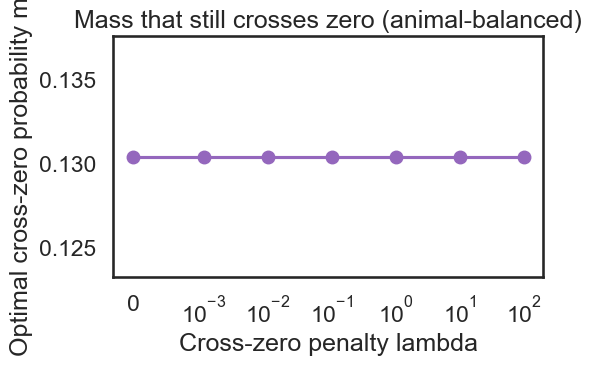

In [799]:
def weighted_hotspot_histogram(frame, group, bin_edges):
    """Discretize one condition using ANALYSIS_WEIGHTING."""
    rows = frame[frame["group"] == group]
    if rows.empty:
        raise ValueError(f"No observations for {group}.")
    mass, _ = np.histogram(
        rows["sign_metric"],
        bins=bin_edges,
        weights=analysis_weights(rows),
    )
    mass = mass.astype(float)
    mass /= mass.sum()
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    keep = mass > 0
    return centers[keep], mass[keep]


def solve_sign_penalized_transport(
    source_x,
    source_mass,
    target_x,
    target_mass,
    crossing_penalty=0.0,
    forbid_crossing=False,
):
    """Solve balanced discrete OT with squared movement and sign penalty."""
    source_x = np.asarray(source_x, dtype=float)
    target_x = np.asarray(target_x, dtype=float)
    source_mass = np.asarray(source_mass, dtype=float)
    target_mass = np.asarray(target_mass, dtype=float)
    source_mass = source_mass / source_mass.sum()
    target_mass = target_mass / target_mass.sum()

    n_source, n_target = len(source_x), len(target_x)
    movement_cost = (source_x[:, None] - target_x[None, :]) ** 2
    crossing = np.signbit(source_x[:, None]) != np.signbit(target_x[None, :])
    objective = movement_cost + crossing_penalty * crossing

    # The final target constraint is redundant because both marginals sum to 1.
    constraints = lil_matrix(
        (n_source + n_target - 1, n_source * n_target), dtype=float
    )
    for source_index in range(n_source):
        start = source_index * n_target
        constraints[source_index, start : start + n_target] = 1.0
    for target_index in range(n_target - 1):
        constraints[
            n_source + target_index, target_index::n_target
        ] = 1.0
    constraint_values = np.concatenate([source_mass, target_mass[:-1]])

    if forbid_crossing:
        bounds = [
            (0.0, 0.0) if is_crossing else (0.0, None)
            for is_crossing in crossing.ravel()
        ]
    else:
        bounds = (0.0, None)

    result = linprog(
        objective.ravel(),
        A_eq=constraints.tocsr(),
        b_eq=constraint_values,
        bounds=bounds,
        method="highs",
    )
    if not result.success:
        return {
            "success": False,
            "message": result.message,
            "movement_cost": np.inf,
            "cross_zero_mass": np.nan,
            "penalized_cost": np.inf,
        }

    plan = result.x.reshape(n_source, n_target)
    cross_zero_mass = float(plan[crossing].sum())
    squared_movement = float(np.sum(plan * movement_cost))
    return {
        "success": True,
        "message": result.message,
        "movement_cost": squared_movement,
        "cross_zero_mass": cross_zero_mass,
        "penalized_cost": squared_movement + crossing_penalty * cross_zero_mass,
    }


# Binning keeps the transport program small and makes all lambda values use the
# same empirical support. Eighty bins span the observed support so the
# resolution follows the selected metric: hotspot_sign reaches +/-1, whereas
# synaptic_contribution concentrates near zero and would leave most of a fixed
# +/-1 grid empty. The grid stays symmetric about zero, so the cross-zero logic
# and the Section 5.2 bounds remain comparable across metrics.
transport_limit = float(
    np.nanmax(np.abs(decisive_sign_df["sign_metric"].to_numpy(dtype=float)))
)
TRANSPORT_BIN_EDGES = np.linspace(
    -transport_limit, transport_limit, 81
) * (1.0 + 1e-9)
baseline_x, baseline_mass = weighted_hotspot_histogram(
    decisive_sign_df, BASELINE_GROUP, TRANSPORT_BIN_EDGES
)
comparison_x, comparison_mass = weighted_hotspot_histogram(
    decisive_sign_df, COMPARISON_GROUP, TRANSPORT_BIN_EDGES
)

strict_transport = solve_sign_penalized_transport(
    baseline_x,
    baseline_mass,
    comparison_x,
    comparison_mass,
    forbid_crossing=True,
)
transport_lambdas = np.array([0.0, 1e-3, 1e-2, 0.1, 1.0, 10.0, 100.0])
transport_records = []
for penalty in transport_lambdas:
    solution = solve_sign_penalized_transport(
        baseline_x,
        baseline_mass,
        comparison_x,
        comparison_mass,
        crossing_penalty=penalty,
    )
    transport_records.append(
        {
            "lambda": penalty,
            "squared movement cost": solution["movement_cost"],
            "cross-zero mass": solution["cross_zero_mass"],
            "penalized objective": solution["penalized_cost"],
        }
    )
transport_df = pd.DataFrame(transport_records)

strict_summary_df = pd.DataFrame(
    [
        {
            "model": "strict sign-fixed (crossing forbidden)",
            "feasible": strict_transport["success"],
            "squared movement cost": strict_transport["movement_cost"],
            "cross-zero mass": strict_transport["cross_zero_mass"],
            "message": strict_transport["message"],
        },
        {
            "model": "unconstrained sign-switch (lambda=0)",
            "feasible": True,
            "squared movement cost": transport_df.iloc[0][
                "squared movement cost"
            ],
            "cross-zero mass": transport_df.iloc[0]["cross-zero mass"],
            "message": "optimal balanced transport",
        },
    ]
)
display(strict_summary_df)
display(transport_df)

if not strict_transport["success"]:
    print(
        "Strict sign-fixed transport is infeasible because "
        f"{BASELINE_GROUP} and {COMPARISON_GROUP} contain different "
        "mass on the two sides of zero. The minimum "
        "cross-zero mass is therefore constrained by Section 5.2's lower bound."
    )

fig, ax_mass = plt.subplots(figsize=(6, 4))
ax_mass.plot(
    transport_df["lambda"],
    transport_df["cross-zero mass"],
    marker="o",
    color="tab:purple",
)
ax_mass.set_xscale("symlog", linthresh=1e-3)
ax_mass.set_xlabel("Cross-zero penalty lambda")
ax_mass.set_ylabel("Optimal cross-zero probability mass")
ax_mass.set_title(
    f"Mass that still crosses zero ({WEIGHTING_LABEL.lower()})"
)
fig.tight_layout()
plt.show()


### 5.4 Population model fitting and validation

#### What this analysis measures

This subsection makes the H1-versus-H2 comparison explicit at the animal level for the two groups in `COMPARISON_GROUPS`. Because hotspots are unpaired across conditions, the identifiable comparison is between a model with one shared population sign probability and a model with condition-specific sign probabilities—not a model that estimates individual $-\rightarrow+$ or $+\rightarrow-$ transition rates.

- **H1 model:** the two endpoint groups share one $p_I=P(x>0)$.
- **H2 model:** each endpoint group has a separate $p_I$ value.

Both models use the same condition- and sign-specific magnitude distributions, so their predictive-performance difference isolates the sign-composition component.

#### Analysis steps

1. For each animal, count the number of inhibitory-dominant hotspots $k_a$ among $n_a$ decisive hotspots.
2. Fit H1 and H2 with a beta-binomial likelihood. This treats the animal as the replicate and uses a shared concentration parameter to allow more between-animal variation than a simple binomial model.
3. Obtain regularized maximum-a-posteriori estimates using weak priors on the sign logits and concentration. Approximate parameter uncertainty with the inverse-Hessian (Laplace) covariance.
4. Fit logit-normal magnitude distributions separately for each condition and observed sign using `ANALYSIS_WEIGHTING`.
5. Generate 2,000 approximate posterior-predictive experiments with the observed number of hotspots per animal. Aggregate simulated outcomes with the selected weighting and compare observed and predictive intervals for $P(x>0)$, $E[x]$, $E(|x|\mid x<0)$, and $E(|x|\mid x>0)$.
6. Plot the predictive distribution of the comparison-minus-baseline inhibitory fraction under both models and mark the observed value.
7. When every condition has at least two contributing animals, perform leave-one-animal-out refitting and compare sign expected log predictive density (ELPD). If holding out an animal would remove its condition from training, report the comparison as not estimable.

The panel plots the predicted spread of the condition contrast under each model:

$$
\Delta p = \text{comparison group's inhibitory fraction} - \text{baseline group's inhibitory fraction}
$$

Each simulated experiment is aggregated into an inhibitory fraction under `ANALYSIS_WEIGHTING`, so the simulated and observed values are the same quantity; the dashed line marks the observed one.

#### Expected result under each hypothesis

- **If H1 is true:** the shared-sign model should reproduce each condition's sign fraction and the active endpoint difference. H2 should provide little or no out-of-animal predictive gain, so $\Delta\mathrm{ELPD}=\mathrm{ELPD}_{H2}-\mathrm{ELPD}_{H1}$ should be near zero or negative.
- **If H2 is true:** the observed condition-specific sign fractions—especially the active endpoint difference—should fall poorly within H1 predictions but be reproduced by H2. With enough animals, H2 should have positive leave-one-animal-out $\Delta\mathrm{ELPD}$.
- **If both sign and magnitude change:** H2 improves sign prediction, while the conditional magnitude summaries also differ across conditions.

Posterior-predictive fit alone asks whether a model can generate data like those observed; leave-one-animal-out ELPD asks whether the added condition-specific sign parameters improve prediction. Neither identifies directional switching rates without paired hotspots or additional mechanistic constraints.


In [800]:
# This is the identifiable population-level H1-vs-H2 comparison for unpaired
# hotspots. H1 has one shared sign probability; H2 has one per condition. A
# beta-binomial likelihood makes the animal, rather than the hotspot, the unit
# of replication and allows extra between-animal variation.

SIGN_LOGIT_PRIOR_SD = 2.0
LOG_CONCENTRATION_PRIOR_MEAN = np.log(10.0)
LOG_CONCENTRATION_PRIOR_SD = 2.0
N_POSTERIOR_PREDICTIVE = 2_000
MODEL_GROUPS = list(COMPARISON_GROUPS)
SIGN_CLASSES = {"excitatory-dominant", "inhibitory-dominant"}
PPC_METRICS = (
    "p_inhibitory", "mean_sign",
    "excitatory_magnitude", "inhibitory_magnitude",
)
model_sign_df = decisive_sign_df[
    decisive_sign_df["group"].isin(MODEL_GROUPS)
].copy()
missing_sign_classes = {
    group: sorted(
        SIGN_CLASSES
        - set(model_sign_df.loc[model_sign_df["group"] == group, "dominance"])
    )
    for group in MODEL_GROUPS
}
missing_sign_classes = {
    group: labels for group, labels in missing_sign_classes.items() if labels
}
if missing_sign_classes:
    raise ValueError(
        "Section 5.4 requires both sign classes in each endpoint group; "
        f"missing: {missing_sign_classes}."
    )


def beta_binomial_logpmf(k, n, alpha, beta):
    """Log PMF of a beta-binomial count."""
    return (
        gammaln(n + 1)
        - gammaln(k + 1)
        - gammaln(n - k + 1)
        + betaln(k + alpha, n - k + beta)
        - betaln(alpha, beta)
    )


def make_animal_sign_counts(frame):
    counts = (
        frame
        .groupby(["group", "animal"], observed=True)
        .agg(
            n=("is_inhibitory", "size"),
            k_positive=("is_inhibitory", "sum"),
        )
        .reset_index()
    )
    counts["group"] = pd.Categorical(
        counts["group"], categories=MODEL_GROUPS, ordered=True
    )
    return counts.sort_values(["group", "animal"]).reset_index(drop=True)


animal_sign_counts_df = make_animal_sign_counts(model_sign_df)


def fit_beta_binomial_sign_model(counts, condition_specific):
    """Regularized MAP fit of a clustered H1 or H2 sign model."""
    n_logits = len(MODEL_GROUPS) if condition_specific else 1
    pooled_p = np.clip(counts["k_positive"].sum() / counts["n"].sum(), 0.01, 0.99)
    initial = np.r_[
        np.repeat(np.log(pooled_p / (1.0 - pooled_p)), n_logits),
        LOG_CONCENTRATION_PRIOR_MEAN,
    ]

    group_index = counts["group"].map(
        {group: index for index, group in enumerate(MODEL_GROUPS)}
    ).to_numpy(dtype=int)
    k = counts["k_positive"].to_numpy(dtype=float)
    n = counts["n"].to_numpy(dtype=float)

    def negative_log_posterior(parameters):
        logits = parameters[:n_logits]
        log_concentration = parameters[-1]
        probabilities = expit(logits)
        concentration = np.exp(np.clip(log_concentration, -8.0, 12.0))
        p_observation = (
            probabilities[group_index]
            if condition_specific
            else np.repeat(probabilities[0], len(counts))
        )
        alpha = np.clip(p_observation * concentration, 1e-9, None)
        beta = np.clip((1.0 - p_observation) * concentration, 1e-9, None)
        log_likelihood = beta_binomial_logpmf(k, n, alpha, beta).sum()
        log_prior = -0.5 * np.sum((logits / SIGN_LOGIT_PRIOR_SD) ** 2)
        log_prior -= 0.5 * (
            (log_concentration - LOG_CONCENTRATION_PRIOR_MEAN)
            / LOG_CONCENTRATION_PRIOR_SD
        ) ** 2
        return -(log_likelihood + log_prior)

    result = minimize(negative_log_posterior, initial, method="BFGS")
    if not np.isfinite(result.fun):
        raise RuntimeError("The beta-binomial model fit produced a non-finite result.")

    covariance = np.asarray(result.hess_inv, dtype=float)
    covariance = (covariance + covariance.T) / 2.0
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    covariance = eigenvectors @ np.diag(np.clip(eigenvalues, 1e-8, None)) @ eigenvectors.T
    return {
        "condition_specific": condition_specific,
        "result": result,
        "parameters": result.x,
        "covariance": covariance,
    }


def model_sign_probabilities(fit, parameters=None):
    if parameters is None:
        parameters = fit["parameters"]
    logits = parameters[:-1]
    if fit["condition_specific"]:
        values = expit(logits)
    else:
        values = np.repeat(expit(logits[0]), len(MODEL_GROUPS))
    return pd.Series(values, index=MODEL_GROUPS, name="P(inhibitory-dominant)")


sign_model_h1 = fit_beta_binomial_sign_model(
    animal_sign_counts_df, condition_specific=False
)
sign_model_h2 = fit_beta_binomial_sign_model(
    animal_sign_counts_df, condition_specific=True
)
fitted_sign_probabilities_df = pd.concat(
    {
        "H1: shared sign composition": model_sign_probabilities(sign_model_h1),
        "H2: condition-specific composition": model_sign_probabilities(sign_model_h2),
    },
    axis=1,
)
display(fitted_sign_probabilities_df)


def fit_logit_magnitude_parameters(frame):
    """Fit weighted logit-normal parameters by group and sign."""
    parameters = {}
    for (group, dominance), rows in frame.groupby(
        ["group", "dominance"], observed=True
    ):
        weights = analysis_weights(rows)
        magnitude = np.clip(rows["magnitude"].to_numpy(dtype=float), 1e-5, 1 - 1e-5)
        transformed = np.log(magnitude / (1.0 - magnitude))
        mean = float(np.average(transformed, weights=weights))
        variance = float(np.average((transformed - mean) ** 2, weights=weights))
        parameters[(group, dominance)] = (mean, max(np.sqrt(variance), 0.05))
    return parameters


magnitude_parameters = fit_logit_magnitude_parameters(model_sign_df)


def summarize_condition_components(frame):
    """Observed PPC targets under the selected analysis weighting."""
    records = []
    for group in MODEL_GROUPS:
        rows = frame[frame["group"] == group]
        weights = analysis_weights(rows)
        record = {
            "group": group,
            "p_inhibitory": np.average(rows["is_inhibitory"], weights=weights),
            "mean_sign": np.average(rows["sign_metric"], weights=weights),
        }
        for dominance, metric in (
            ("excitatory-dominant", "excitatory_magnitude"),
            ("inhibitory-dominant", "inhibitory_magnitude"),
        ):
            sign_rows = rows[rows["dominance"] == dominance]
            record[metric] = np.average(
                sign_rows["magnitude"], weights=analysis_weights(sign_rows)
            )
        records.append(record)
    return pd.DataFrame.from_records(records).set_index("group")


condition_components_df = summarize_condition_components(model_sign_df)
display(condition_components_df)


def posterior_predictive_summaries(
    fit,
    counts,
    magnitude_parameters,
    n_draws=N_POSTERIOR_PREDICTIVE,
    seed=2026,
):
    """Laplace-approximate PPC with the observed number of spots per animal."""
    rng = np.random.default_rng(seed)
    parameter_draws = rng.multivariate_normal(
        fit["parameters"], fit["covariance"], size=n_draws
    )
    simulations = {
        (group, metric): np.full(n_draws, np.nan)
        for group in MODEL_GROUPS
        for metric in PPC_METRICS
    }

    rows_by_group = {
        group: counts[counts["group"] == group] for group in MODEL_GROUPS
    }
    for draw_index, parameters in enumerate(parameter_draws):
        probabilities = model_sign_probabilities(fit, parameters)
        concentration = np.exp(np.clip(parameters[-1], -8.0, 12.0))
        for group in MODEL_GROUPS:
            animal_records = []
            for row in rows_by_group[group].itertuples(index=False):
                p = float(probabilities[group])
                animal_p = rng.beta(p * concentration, (1.0 - p) * concentration)
                n_positive = rng.binomial(int(row.n), animal_p)
                n_negative = int(row.n) - n_positive

                positive_values = np.array([], dtype=float)
                negative_values = np.array([], dtype=float)
                if n_positive:
                    mu, sigma = magnitude_parameters[
                        (group, "inhibitory-dominant")
                    ]
                    positive_values = expit(rng.normal(mu, sigma, n_positive))
                if n_negative:
                    mu, sigma = magnitude_parameters[
                        (group, "excitatory-dominant")
                    ]
                    negative_values = expit(rng.normal(mu, sigma, n_negative))

                animal_records.append({
                    "n": int(row.n),
                    "n_positive": n_positive,
                    "n_negative": n_negative,
                    "positive_sum": positive_values.sum(),
                    "negative_sum": negative_values.sum(),
                })

            simulated = pd.DataFrame(animal_records)
            if ANALYSIS_WEIGHTING == "animal_balanced":
                inverse_n = 1.0 / simulated["n"]
                p_inhibitory = (
                    simulated["n_positive"] * inverse_n
                ).mean()
                mean_sign = (
                    (simulated["positive_sum"] - simulated["negative_sum"])
                    * inverse_n
                ).mean()
                negative_mass = simulated["n_negative"] * inverse_n
                positive_mass = simulated["n_positive"] * inverse_n
                excitatory_magnitude = (
                    (simulated["negative_sum"] * inverse_n).sum()
                    / negative_mass.sum()
                    if negative_mass.sum() else np.nan
                )
                inhibitory_magnitude = (
                    (simulated["positive_sum"] * inverse_n).sum()
                    / positive_mass.sum()
                    if positive_mass.sum() else np.nan
                )
            else:
                n_total = simulated["n"].sum()
                p_inhibitory = simulated["n_positive"].sum() / n_total
                mean_sign = (
                    simulated["positive_sum"].sum()
                    - simulated["negative_sum"].sum()
                ) / n_total
                excitatory_magnitude = (
                    simulated["negative_sum"].sum()
                    / simulated["n_negative"].sum()
                    if simulated["n_negative"].sum() else np.nan
                )
                inhibitory_magnitude = (
                    simulated["positive_sum"].sum()
                    / simulated["n_positive"].sum()
                    if simulated["n_positive"].sum() else np.nan
                )

            for metric, value in {
                "p_inhibitory": p_inhibitory,
                "mean_sign": mean_sign,
                "excitatory_magnitude": excitatory_magnitude,
                "inhibitory_magnitude": inhibitory_magnitude,
            }.items():
                simulations[(group, metric)][draw_index] = value
    return simulations


def summarize_posterior_predictive(simulations, observed_components, model_name):
    records = []
    for group in MODEL_GROUPS:
        for metric in PPC_METRICS:
            values = simulations[(group, metric)]
            observed = observed_components.loc[group, metric]
            records.append(
                {
                    "model": model_name,
                    "group": group,
                    "metric": metric,
                    "observed": observed,
                    "predictive median": np.nanmedian(values),
                    "predictive 2.5%": np.nanpercentile(values, 2.5),
                    "predictive 97.5%": np.nanpercentile(values, 97.5),
                }
            )
    return pd.DataFrame(records)


h1_ppc = posterior_predictive_summaries(
    sign_model_h1, animal_sign_counts_df, magnitude_parameters, seed=2026
)
h2_ppc = posterior_predictive_summaries(
    sign_model_h2, animal_sign_counts_df, magnitude_parameters, seed=2027
)
posterior_predictive_df = pd.concat(
    [
        summarize_posterior_predictive(
            h1_ppc, condition_components_df, "H1: shared sign composition"
        ),
        summarize_posterior_predictive(
            h2_ppc, condition_components_df, "H2: condition-specific composition"
        ),
    ],
    ignore_index=True,
)
display(posterior_predictive_df)


def held_out_log_predictive(fit, held_out_row):
    probabilities = model_sign_probabilities(fit)
    p = float(probabilities[str(held_out_row.group)])
    concentration = np.exp(np.clip(fit["parameters"][-1], -8.0, 12.0))
    return float(
        beta_binomial_logpmf(
            held_out_row.k_positive,
            held_out_row.n,
            p * concentration,
            (1.0 - p) * concentration,
        )
    )


# Leave out complete animals, refit, and score the held-out sign count. This is
# only identifiable when every condition retains at least one training animal.
animals_per_group = animal_sign_counts_df.groupby(
    "group", observed=True
)["animal"].nunique().reindex(MODEL_GROUPS, fill_value=0)
loao_is_estimable = bool((animals_per_group >= 2).all())
loao_log_scores_df = pd.DataFrame()
loao_summary_df = pd.DataFrame()
h1_elpd = np.nan
h2_elpd = np.nan

if loao_is_estimable:
    loao_records = []
    for held_out_index, held_out in animal_sign_counts_df.iterrows():
        training_counts = animal_sign_counts_df.drop(index=held_out_index)
        for model_name, condition_specific in (
            ("H1: shared sign composition", False),
            ("H2: condition-specific composition", True),
        ):
            fitted = fit_beta_binomial_sign_model(
                training_counts, condition_specific
            )
            loao_records.append(
                {
                    "model": model_name,
                    "held-out group": str(held_out["group"]),
                    "held-out animal": held_out["animal"],
                    "sign log predictive density": held_out_log_predictive(
                        fitted, held_out
                    ),
                }
            )
    loao_log_scores_df = pd.DataFrame(loao_records)
    loao_summary_df = (
        loao_log_scores_df.groupby("model", observed=True)[
            "sign log predictive density"
        ]
        .agg([("sign ELPD", "sum"), ("mean per animal", "mean")])
        .sort_values("sign ELPD", ascending=False)
    )
    h1_elpd = loao_summary_df.loc[
        "H1: shared sign composition", "sign ELPD"
    ]
    h2_elpd = loao_summary_df.loc[
        "H2: condition-specific composition", "sign ELPD"
    ]
    loao_summary_df["delta ELPD vs H1"] = (
        loao_summary_df["sign ELPD"] - h1_elpd
    )
    display(loao_summary_df)
    display(loao_log_scores_df)
else:
    print(
        "Leave-one-animal-out model comparison is not estimable: each "
        "condition needs at least two animals with valid hotspots so the held-"
        "out animal's condition remains represented in training. Contributing "
        f"animal counts: {animals_per_group.to_dict()}"
    )

observed_delta_p = (
    condition_components_df.loc[COMPARISON_GROUP, "p_inhibitory"]
    - condition_components_df.loc[BASELINE_GROUP, "p_inhibitory"]
)

,H1: shared sign composition,H2: condition-specific composition
reward,0.721204,0.712618
punish,0.721204,0.721028


,p_inhibitory,mean_sign,excitatory_magnitude,inhibitory_magnitude
group,,,,
reward,0.773646,0.197383,0.099592,0.258435
punish,0.643243,0.016000,0.050266,0.100714


,model,group,metric,observed,predictive median,predictive 2.5%,predictive 97.5%
0,H1: shared sign composition,reward,p_inhibitory,0.773646,0.730024,0.480232,0.901608
1,H1: shared sign composition,reward,mean_sign,0.197383,0.312520,0.164566,0.434606
2,H1: shared sign composition,reward,excitatory_magnitude,0.099592,0.105278,0.062161,0.175995
3,H1: shared sign composition,reward,inhibitory_magnitude,0.258435,0.472013,0.386694,0.560363
4,H1: shared sign composition,punish,p_inhibitory,0.643243,0.719505,0.497864,0.885474
5,H1: shared sign composition,punish,mean_sign,0.016000,0.056894,0.020337,0.087938
6,H1: shared sign composition,punish,excitatory_magnitude,0.050266,0.048500,0.027400,0.079799
7,H1: shared sign composition,punish,inhibitory_magnitude,0.100714,0.097091,0.075538,0.123436
8,H2: condition-specific composition,reward,p_inhibitory,0.773646,0.712375,0.424725,0.927257
9,H2: condition-specific composition,reward,mean_sign,0.197383,0.300457,0.131827,0.448615


,sign ELPD,mean per animal,delta ELPD vs H1
model,,,
H1: shared sign composition,-27.667358,-3.952480,0.000000
H2: condition-specific composition,-31.910072,-4.558582,-4.242714


,model,held-out group,held-out animal,sign log predictive density
0,H1: shared sign composition,reward,SL455,-7.890572
1,H2: condition-specific composition,reward,SL455,-10.143915
2,H1: shared sign composition,reward,SL456,-2.889727
3,H2: condition-specific composition,reward,SL456,-2.904234
4,H1: shared sign composition,reward,SL468,-3.356455
5,H2: condition-specific composition,reward,SL468,-4.964694
6,H1: shared sign composition,punish,SL448,-3.699115
7,H2: condition-specific composition,punish,SL448,-3.886747
8,H1: shared sign composition,punish,SL453,-3.749824
9,H2: condition-specific composition,punish,SL453,-3.749604


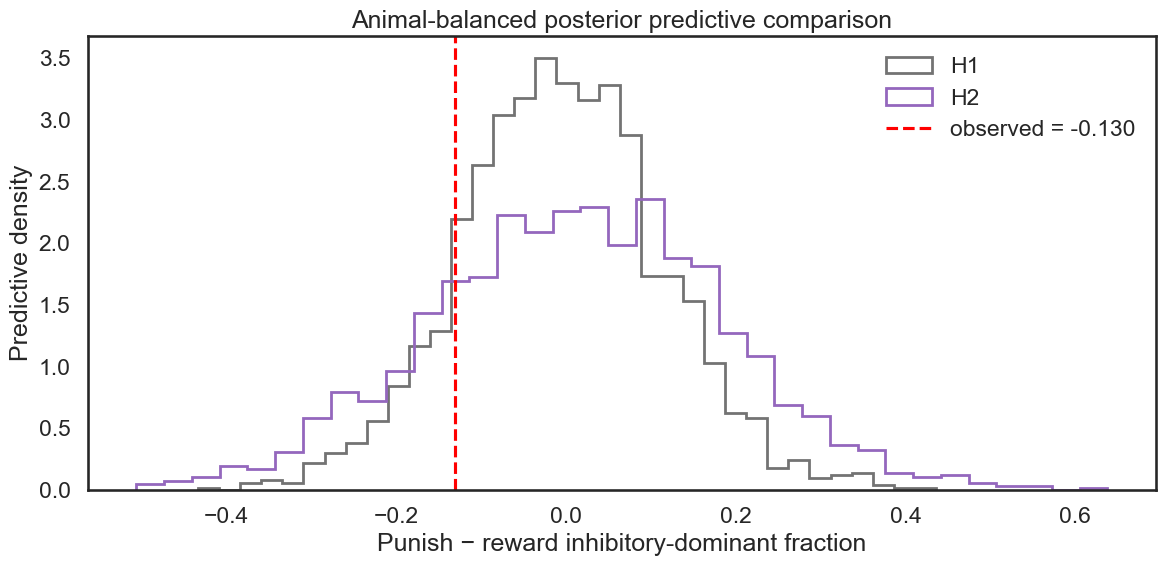

Leave-one-animal-out delta ELPD (H2 − H1): -4.24


In [801]:
fig, ax = plt.subplots(figsize=(12, 6))
for simulations, label, color in (
    (h1_ppc, "H1", "0.45"),
    (h2_ppc, "H2", "tab:purple"),
):
    delta = (
        simulations[(COMPARISON_GROUP, "p_inhibitory")]
        - simulations[(BASELINE_GROUP, "p_inhibitory")]
    )
    ax.hist(
        delta,
        bins=35,
        density=True,
        histtype="step",
        linewidth=2,
        color=color,
        label=label,
    )
ax.axvline(
    observed_delta_p,
    color="red",
    linestyle="--",
    label=f"observed = {observed_delta_p:+.3f}",
)
ax.set_xlabel(
    f"{COMPARISON_GROUP.capitalize()} − {BASELINE_GROUP} "
    "inhibitory-dominant fraction"
)
ax.set_ylabel("Predictive density")
ax.set_title(f"{WEIGHTING_LABEL} posterior predictive comparison")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

if loao_is_estimable:
    print(
        "Leave-one-animal-out delta ELPD (H2 − H1): "
        f"{h2_elpd - h1_elpd:+.2f}"
    )